# Classification and FairML with the COMPAS Dataset

**Team Number:** 11  

**Team Members:**  
- Raveena Kumari  
- Sneha Pillai

**Project Topic:** Fair machine learning for recidivism prediction using the COMPAS dataset

# 1. Introduction

Machine learning models are increasingly used in decision-making systems that affect people's lives. One important example is the criminal justice system, where algorithms have been used to estimate the risk that a defendant may reoffend in the future.

COMPAS stands for **Correctional Offender Management Profiling for Alternative Sanctions**. It is a risk assessment tool that was used in the United States to predict the likelihood of recidivism, meaning whether a person would commit another crime after being assessed.

The COMPAS algorithm became widely discussed because investigations showed that its predictions were not equally accurate for different racial groups. In particular, it was reported that African-American defendants were more likely to be incorrectly classified as high risk compared to Caucasian defendants, while Caucasian defendants were more likely to be incorrectly classified as low risk.

This project focuses on the COMPAS dataset and uses machine learning classification models to predict recidivism. Along with traditional performance metrics such as accuracy, precision, recall, and F1-score, this project also evaluates fairness metrics. The aim is not only to build an accurate model, but also to analyze and improve fairness across protected groups, especially race.

The project uses both standard machine learning methods and fairness-aware machine learning methods. The IBM AIF360 library will be used later in the project to calculate fairness metrics and apply bias mitigation techniques.

# 2. Problem Statement and Objective

## 2.1 Problem Statement

The COMPAS dataset contains information about defendants, including demographic details, criminal history, COMPAS risk scores, and whether the person actually reoffended. The main task is to develop a classification model that predicts recidivism.

However, this is not only a normal classification problem. Since the dataset involves sensitive social and legal decisions, fairness is also very important. A model with high accuracy may still be unfair if it produces different error rates for different racial groups.

For example, if a model wrongly predicts African-American defendants as high risk more often than Caucasian defendants, this would be an unfair outcome. Therefore, the project must evaluate both:

1. Predictive performance
2. Fairness across protected groups

The protected attribute mainly considered in this project is **race**.

## 2.2 Main Objective

The main objective of this project is to develop a machine learning classification model for the COMPAS dataset that provides a good balance between accuracy and fairness.

## 2.3 Specific Objectives

The specific objectives are:

1. Load and understand the COMPAS dataset.
2. Clean and preprocess the dataset for machine learning.
3. Perform exploratory data analysis to understand patterns in the data.
4. Analyze the original COMPAS score as a baseline model.
5. Train and compare multiple machine learning models.
6. Evaluate models using classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
7. Evaluate fairness using fairness metrics such as false positive rate difference, false negative rate difference, statistical parity difference, and equal opportunity difference.
8. Use AIF360 to perform fairness analysis and bias mitigation.
9. Apply reweighing as a fairness-aware preprocessing method.
10. Compare model performance before and after bias mitigation.
11. Select a final model that balances accuracy and fairness.

## 2.4 Classification Target

The target variable for this project is:

`is_recid`

This variable represents whether a defendant reoffended or not.

- `is_recid = 1` means the person reoffended.
- `is_recid = 0` means the person did not reoffend.

Rows with `is_recid = -1` will be removed later because they do not represent a valid binary class for this classification task.

## 2.5 Protected Attribute

The main protected attribute is:

`race`

The fairness analysis will mainly compare model behavior between racial groups, especially:

- African-American defendants
- Caucasian defendants

# 3. Dataset Description

The dataset used in this project is the COMPAS dataset published by ProPublica. It contains records related to defendants who were assessed using the COMPAS risk assessment tool.

The dataset includes demographic information, criminal history, COMPAS risk scores, charge information, and recidivism outcomes.

In this section, we load the dataset and inspect its basic structure. This includes:

1. Number of rows and columns
2. Column names
3. First few records
4. Data types
5. Missing values
6. Target variable distribution
7. Race distribution
8. Important columns for the project

In [1]:
# Import pandas for data loading and data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This command helps display plots directly inside the Jupyter Notebook
%matplotlib inline

# Set display options so we can see more columns in the notebook output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set a simple visual style for plots
sns.set(style="whitegrid")

The required Python libraries are imported here.

- `pandas` is used to load and analyze the dataset.
- `numpy` is used for numerical calculations.
- `matplotlib` and `seaborn` are used for data visualization.

In [2]:
# Load the COMPAS dataset
# Make sure the CSV file is in the same folder as this Jupyter Notebook.
# If your file name is different, update the file path below.

df = pd.read_csv("cox-violent-parsed.csv")

# Display the first five rows of the dataset
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0
1,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,334,961,0
2,2,michael ryan,michael,ryan,2014-12-31,Male,1985-02-06,31,25 - 45,Caucasian,0,5,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,5,Medium,2014-12-31,Risk of Violence,2,Low,2014-12-31,2014-12-30,2015-01-03,0,3,457,0
3,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,(F3),Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1
4,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,(F3),Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0


The dataset is loaded using `pandas.read_csv()`.

The command `df.head()` displays the first five rows of the dataset. This helps us quickly understand what the data looks like.

In [3]:
# Check the number of rows and columns in the dataset
df.shape

(18316, 52)

In [4]:
# Print the number of rows and columns in a clearer format
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 18316
Number of columns: 52


The shape of the dataset tells us how many observations and variables are available.

- Rows represent individual records.
- Columns represent variables or features.

In this dataset, each row represents a defendant record, and each column contains information such as age, race, criminal history, COMPAS score, and recidivism outcome.

In [5]:
# Display all column names in the dataset
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event'],
      dtype='object')

In [6]:
# Print column names one by one for better readability
for column in df.columns:
    print(column)

id
name
first
last
compas_screening_date
sex
dob
age
age_cat
race
juv_fel_count
decile_score
juv_misd_count
juv_other_count
priors_count
days_b_screening_arrest
c_jail_in
c_jail_out
c_case_number
c_offense_date
c_arrest_date
c_days_from_compas
c_charge_degree
c_charge_desc
is_recid
r_case_number
r_charge_degree
r_days_from_arrest
r_offense_date
r_charge_desc
r_jail_in
r_jail_out
violent_recid
is_violent_recid
vr_case_number
vr_charge_degree
vr_offense_date
vr_charge_desc
type_of_assessment
decile_score.1
score_text
screening_date
v_type_of_assessment
v_decile_score
v_score_text
v_screening_date
in_custody
out_custody
priors_count.1
start
end
event


The dataset contains many columns. Some columns are useful for prediction, while others are identifiers, dates, names, or text descriptions.

Later in the preprocessing step, we will remove columns that should not be used for modeling, such as personal names, IDs, case numbers, and date-based columns.

In [7]:
# Display general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18316 non-null  int64  
 1   name                     18316 non-null  object 
 2   first                    18316 non-null  object 
 3   last                     18316 non-null  object 
 4   compas_screening_date    18316 non-null  object 
 5   sex                      18316 non-null  object 
 6   dob                      18316 non-null  object 
 7   age                      18316 non-null  int64  
 8   age_cat                  18316 non-null  object 
 9   race                     18316 non-null  object 
 10  juv_fel_count            18316 non-null  int64  
 11  decile_score             18316 non-null  int64  
 12  juv_misd_count           18316 non-null  int64  
 13  juv_other_count          18316 non-null  int64  
 14  priors_count          

The `df.info()` command shows:

1. Column names
2. Number of non-null values
3. Data types of each column
4. Memory usage

This is useful because machine learning models usually require numerical input. Therefore, categorical variables such as race, sex, and charge degree will need to be encoded later.

In [8]:
# Display summary statistics for numerical columns
df.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event
count,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5492.908932,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,186.394901,625.210636,0.044715
std,3165.256572,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,283.373004,335.881439,0.206683
min,1.000000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,2772.000000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000,364.000000,0.000000
50%,5489.000000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,7.000000,634.000000,0.000000
75%,8205.250000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,309.000000,897.000000,0.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1197.000000,1187.000000,1.000000


The `df.describe()` command gives summary statistics for numerical columns.

It includes:

- Count
- Mean
- Standard deviation
- Minimum value
- 25th percentile
- Median
- 75th percentile
- Maximum value

This helps us understand the range and distribution of numerical variables such as age, priors count, decile score, and recidivism outcome.

In [9]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0].sort_values(ascending=False)

violent_recid              18316
vr_charge_desc             16977
vr_offense_date            16977
vr_charge_degree           16977
vr_case_number             16977
c_arrest_date              15231
r_jail_in                  11957
r_days_from_arrest         11957
r_jail_out                 11957
r_charge_desc              10039
r_offense_date              9899
r_case_number               9899
r_charge_degree             9899
c_offense_date              3952
days_b_screening_arrest     1297
c_jail_in                   1297
c_jail_out                  1297
c_charge_desc                881
c_charge_degree              867
c_days_from_compas           867
c_case_number                867
in_custody                   594
out_custody                  594
score_text                    23
v_score_text                   6
dtype: int64

Missing values can affect machine learning models. Therefore, it is important to check which columns contain missing data.

In later preprocessing steps, we will decide whether to:

1. Remove columns with too many missing values
2. Remove rows with missing values
3. Fill missing values using suitable methods

The correct method depends on the importance of each column and the amount of missing data.

## Target Variable: `is_recid`

The main target variable for this project is `is_recid`.

This variable tells us whether the person reoffended or not.

- `is_recid = 1`: The person reoffended.
- `is_recid = 0`: The person did not reoffend.
- `is_recid = -1`: Invalid or unclear value, which will be removed later.

Since this is a binary classification problem, we will keep only rows where `is_recid` is 0 or 1.

In [10]:
# Check the distribution of the target variable
df['is_recid'].value_counts()

is_recid
 0    9079
 1    8417
-1     820
Name: count, dtype: int64

In [11]:
# Check the percentage distribution of the target variable
df['is_recid'].value_counts(normalize=True) * 100

is_recid
 0    49.568683
 1    45.954357
-1     4.476960
Name: proportion, dtype: float64

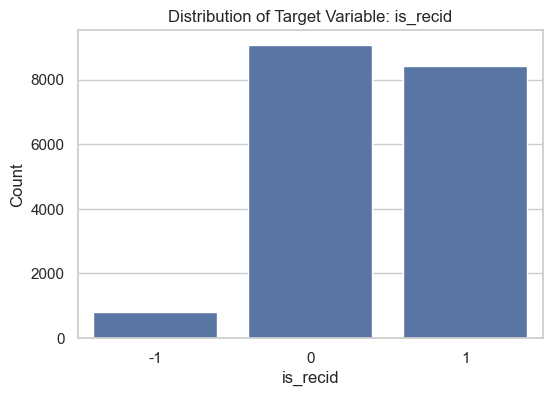

In [12]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_recid')
plt.title("Distribution of Target Variable: is_recid")
plt.xlabel("is_recid")
plt.ylabel("Count")
plt.show()

The target variable contains three values: 0, 1, and -1.

For binary classification, we only need valid classes:

- 0
- 1

The value -1 does not represent a valid recidivism outcome for our classification model. Therefore, these rows will be removed during data cleaning.

## Protected Attribute: `race`

In fairness-aware machine learning, a protected attribute is a variable related to sensitive characteristics such as race, gender, age, or religion.

In this project, the main protected attribute is `race`.

We will later evaluate whether model errors are different for different racial groups. The main comparison will be between:

- African-American defendants
- Caucasian defendants

In [13]:
# Check the distribution of race in the dataset
df['race'].value_counts()

race
African-American    9791
Caucasian           6086
Hispanic            1451
Other                860
Asian                 71
Native American       57
Name: count, dtype: int64

In [14]:
# Check percentage distribution of race
df['race'].value_counts(normalize=True) * 100

race
African-American    53.455995
Caucasian           33.227779
Hispanic             7.922035
Other                4.695348
Asian                0.387639
Native American      0.311203
Name: proportion, dtype: float64

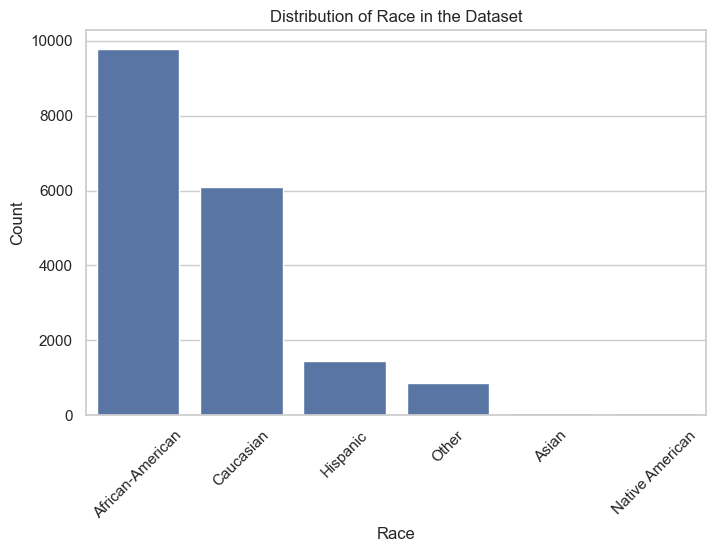

In [15]:
# Visualize race distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='race', order=df['race'].value_counts().index)
plt.title("Distribution of Race in the Dataset")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The race distribution shows how many records are available for each racial group.

This is important because fairness metrics compare model performance across groups. If some groups have very few records, fairness results for those groups may be less stable.

For this project, we will mainly compare African-American and Caucasian defendants because these are the two largest groups in the dataset.

In [16]:
# Check distribution of sex
df['sex'].value_counts()

sex
Male      14933
Female     3383
Name: count, dtype: int64

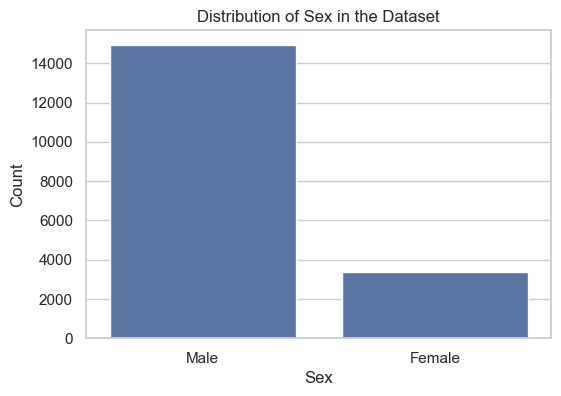

In [17]:
# Visualize gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex')
plt.title("Distribution of Sex in the Dataset")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

The variable `sex` is another demographic variable in the dataset.

Although our main fairness analysis focuses on race, gender can also be considered as a protected attribute. Later, if time allows, we can also check fairness differences between male and female defendants.

## COMPAS Score Variables

The dataset contains COMPAS risk score variables. These are important because they represent the original risk assessment system.

Important COMPAS-related columns include:

- `decile_score`
- `score_text`
- `v_decile_score`
- `v_score_text`

The variable `decile_score` gives a risk score from 1 to 10.

The variable `score_text` gives a category such as:

- Low
- Medium
- High

Later in the project, we will use `score_text` as a baseline COMPAS prediction and compare it with our machine learning models.

In [18]:
# Check distribution of COMPAS score text
df['score_text'].value_counts(dropna=False)

score_text
Low       8597
Medium    5082
High      4614
NaN         23
Name: count, dtype: int64

In [19]:
# Check distribution of COMPAS decile score
df['decile_score'].value_counts().sort_index()

decile_score
-1       23
 1     2923
 2     2031
 3     1813
 4     1830
 5     1649
 6     1713
 7     1720
 8     1614
 9     1670
 10    1330
Name: count, dtype: int64

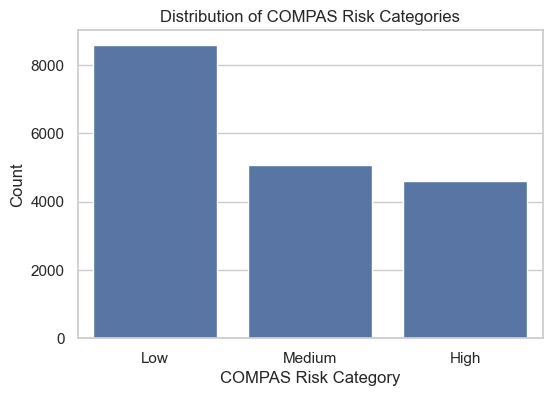

In [20]:
# Visualize COMPAS score text distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='score_text', order=['Low', 'Medium', 'High'])
plt.title("Distribution of COMPAS Risk Categories")
plt.xlabel("COMPAS Risk Category")
plt.ylabel("Count")
plt.show()

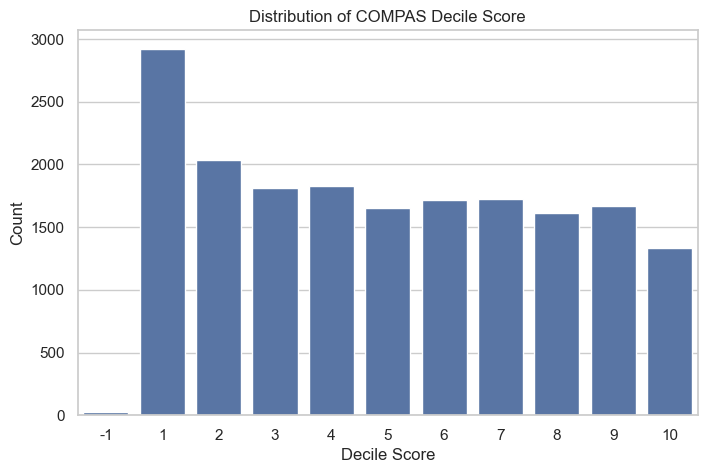

In [21]:
# Visualize COMPAS decile score distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='decile_score')
plt.title("Distribution of COMPAS Decile Score")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.show()

The COMPAS score variables are important because they allow us to compare our machine learning models with the original COMPAS risk classification.

A simple baseline can be created as follows:

- Low risk = predicted no recidivism
- Medium or High risk = predicted recidivism

This baseline will be evaluated later using both classification metrics and fairness metrics.

In [22]:
# Create a list of important columns that are likely to be useful in this project
important_columns = [
    'sex',
    'age',
    'age_cat',
    'race',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree',
    'decile_score',
    'score_text',
    'is_recid',
    'is_violent_recid'
]

# Display these columns
df[important_columns].head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,decile_score,score_text,is_recid,is_violent_recid
0,Male,69,Greater than 45,Other,0,0,0,0,(F3),1,Low,0,0
1,Male,69,Greater than 45,Other,0,0,0,0,(F3),1,Low,0,0
2,Male,31,25 - 45,Caucasian,0,0,0,0,NaN,5,Medium,-1,0
3,Male,34,25 - 45,African-American,0,0,0,0,(F3),3,Low,1,1
4,Male,24,Less than 25,African-American,0,0,1,4,(F3),4,Low,1,0


The selected important columns include demographic variables, criminal history variables, COMPAS score variables, and recidivism outcome variables.

Some important variables are:

| Column | Meaning |
|---|---|
| `sex` | Gender of the defendant |
| `age` | Age of the defendant |
| `age_cat` | Age category |
| `race` | Race of the defendant |
| `juv_fel_count` | Number of juvenile felony charges |
| `juv_misd_count` | Number of juvenile misdemeanor charges |
| `juv_other_count` | Number of other juvenile charges |
| `priors_count` | Number of prior offenses |
| `c_charge_degree` | Charge degree |
| `decile_score` | COMPAS risk score from 1 to 10 |
| `score_text` | COMPAS risk category |
| `is_recid` | Target variable for recidivism |
| `is_violent_recid` | Target variable for violent recidivism |

For this project, the main target variable will be `is_recid`.

In [23]:
# Create a table showing recidivism counts by race
race_recid_table = pd.crosstab(df['race'], df['is_recid'])

race_recid_table

is_recid,-1,0,1
race,,,
African-American,372,4338,5081
Asian,7,45,19
Caucasian,304,3308,2474
Hispanic,96,860,495
Native American,6,26,25
Other,35,502,323


In [24]:
# Create percentage table showing recidivism rate by race
race_recid_percentage = pd.crosstab(df['race'], df['is_recid'], normalize='index') * 100

race_recid_percentage

is_recid,-1,0,1
race,,,
African-American,3.799408,44.305995,51.894597
Asian,9.859155,63.380282,26.760563
Caucasian,4.995071,54.354256,40.650674
Hispanic,6.616127,59.269469,34.114404
Native American,10.526316,45.614035,43.859649
Other,4.069767,58.372093,37.558140


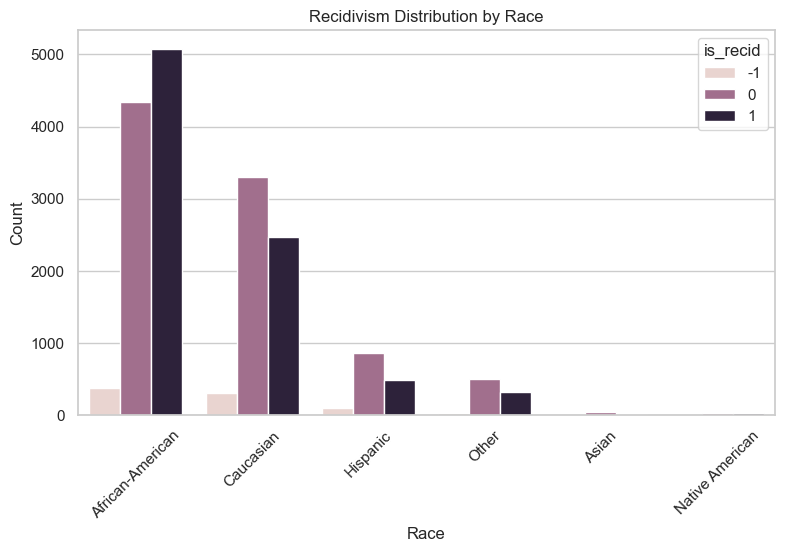

In [25]:
# Visualize recidivism distribution by race
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='race', hue='is_recid', order=df['race'].value_counts().index)
plt.title("Recidivism Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="is_recid")
plt.show()

This table and plot help us understand how recidivism outcomes are distributed across racial groups.

This is important because fairness analysis depends on the relationship between the target variable and the protected attribute.

However, we should be careful when interpreting this relationship. Differences in observed outcomes may be influenced by social, legal, historical, and data collection factors. Therefore, fairness analysis should consider both prediction performance and error differences across groups.

In [26]:
# Create a table showing COMPAS risk categories by race
race_score_table = pd.crosstab(df['race'], df['score_text'])

race_score_table

score_text,High,Low,Medium
race,,,
African-American,3400,3369,3010
Asian,9,50,12
Caucasian,943,3554,1579
Hispanic,191,945,315
Native American,15,26,16
Other,56,653,150


In [27]:
# Create percentage table of COMPAS score categories by race
race_score_percentage = pd.crosstab(df['race'], df['score_text'], normalize='index') * 100

race_score_percentage

score_text,High,Low,Medium
race,,,
African-American,34.768381,34.451375,30.780243
Asian,12.676056,70.422535,16.901408
Caucasian,15.520079,58.492429,25.987492
Hispanic,13.163336,65.127498,21.709166
Native American,26.315789,45.614035,28.070175
Other,6.519208,76.018626,17.462165


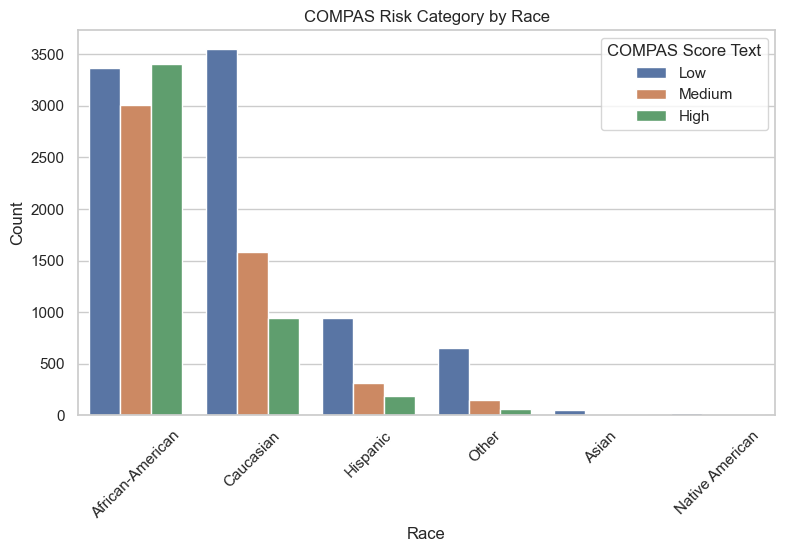

In [28]:
# Visualize COMPAS score category by race
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='race', hue='score_text', order=df['race'].value_counts().index)
plt.title("COMPAS Risk Category by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="COMPAS Score Text")
plt.show()

This analysis shows how COMPAS risk categories are distributed across racial groups.

This is useful because COMPAS itself will be used as a baseline model later. If some racial groups receive high-risk scores more often than others, we need to check whether this is supported by actual recidivism outcomes and whether error rates are balanced.

# 3.15 Initial Observations

From the initial dataset inspection, we observe the following:

1. The dataset contains 18,316 rows and 52 columns.
2. The main target variable for this project is `is_recid`.
3. The target variable contains values 0, 1, and -1.
4. Since this is a binary classification project, rows with `is_recid = -1` will be removed during preprocessing.
5. The main protected attribute is `race`.
6. The largest racial groups are African-American and Caucasian defendants.
7. The dataset contains COMPAS score variables such as `decile_score` and `score_text`.
8. The original COMPAS score can be used as a baseline model.
9. Some columns are personal identifiers or legal/date-related fields and should not be used directly in the machine learning model.
10. Fairness analysis is necessary because model errors may differ across racial groups.

In the next section, we will perform data loading, cleaning, and preprocessing to prepare the dataset for machine learning.

# 4. Data Cleaning and Preprocessing

Data cleaning and preprocessing are important steps before training machine learning models.

The raw COMPAS dataset contains columns that are not suitable for direct machine learning, such as names, IDs, dates, and text descriptions. It also contains invalid target values and multiple racial groups.

In this project, we focus mainly on binary classification and fairness analysis between African-American and Caucasian defendants.

The main goals of this section are:

1. Create a copy of the original dataset.
2. Remove invalid target values.
3. Select relevant columns for modeling.
4. Remove unnecessary or sensitive identifier columns.
5. Handle missing values.
6. Focus fairness analysis on African-American and Caucasian groups.
7. Encode categorical variables.
8. Prepare a clean dataset for machine learning.

In [29]:
# Create a copy of the original dataset
# This protects the original dataframe from accidental changes.

df_clean = df.copy()

# Check shape of copied dataset
print("Shape of copied dataset:", df_clean.shape)

Shape of copied dataset: (18316, 52)


A copy of the original dataset is created.

This is good practice because we can clean and modify `df_clean` without changing the original dataframe `df`.

In [30]:
# Check unique values in the target variable
df_clean['is_recid'].value_counts()

is_recid
 0    9079
 1    8417
-1     820
Name: count, dtype: int64

The target variable is `is_recid`.

It contains:

- `0`: Person did not reoffend
- `1`: Person reoffended
- `-1`: Invalid or unclear outcome

Since this is a binary classification problem, we will remove rows where `is_recid = -1`.

In [31]:
# Remove rows where is_recid is -1
# These rows are not valid for binary classification.

df_clean = df_clean[df_clean['is_recid'] != -1]

# Check target distribution after removing invalid rows
df_clean['is_recid'].value_counts()

is_recid
0    9079
1    8417
Name: count, dtype: int64

In [32]:
# Check new dataset shape
print("Shape after removing invalid target values:", df_clean.shape)

Shape after removing invalid target values: (17496, 52)


Rows with `is_recid = -1` are removed because they do not represent a valid class.

Now the target variable contains only two classes:

- `0`: No recidivism
- `1`: Recidivism

For fairness analysis, this project mainly compares African-American and Caucasian defendants.

These are the two largest racial groups in the dataset. Focusing on these two groups makes the fairness comparison clearer and more stable.

We will keep only:

- African-American
- Caucasian

In [33]:
# Check race distribution before filtering
df_clean['race'].value_counts()

race
African-American    9419
Caucasian           5782
Hispanic            1355
Other                825
Asian                 64
Native American       51
Name: count, dtype: int64

In [34]:
# Keep only African-American and Caucasian defendants
df_clean = df_clean[df_clean['race'].isin(['African-American', 'Caucasian'])]

# Check race distribution after filtering
df_clean['race'].value_counts()

race
African-American    9419
Caucasian           5782
Name: count, dtype: int64

In [35]:
# Check shape after race filtering
print("Shape after keeping African-American and Caucasian groups:", df_clean.shape)

Shape after keeping African-American and Caucasian groups: (15201, 52)


The dataset is now restricted to the two main racial groups.

This will make the fairness analysis more direct because we can compare model outcomes between:

- African-American defendants
- Caucasian defendants

The original dataset contains many columns, but not all of them are suitable for model training.

We remove columns such as:

- Names
- IDs
- Case numbers
- Dates
- Text descriptions
- Variables that directly come from COMPAS scores

For our machine learning models, we will mainly use demographic and criminal history variables.

Important note:

We should not use `score_text` or `decile_score` as input features for our own models because these are outputs from the original COMPAS algorithm. We will use them later only for baseline COMPAS analysis.

In [36]:
# Select columns useful for our machine learning model

selected_columns = [
    'sex',
    'age',
    'age_cat',
    'race',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree',
    'is_recid',
    'score_text',
    'decile_score'
]

# Create a smaller dataframe with selected columns
df_clean = df_clean[selected_columns]

# Display first rows
df_clean.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,is_recid,score_text,decile_score
3,Male,34,25 - 45,African-American,0,0,0,0,(F3),1,Low,3
4,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4
5,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4
6,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4
7,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4


The selected dataset contains:

| Column | Purpose |
|---|---|
| `sex` | Demographic variable |
| `age` | Age of defendant |
| `age_cat` | Age category |
| `race` | Protected attribute for fairness analysis |
| `juv_fel_count` | Juvenile felony count |
| `juv_misd_count` | Juvenile misdemeanor count |
| `juv_other_count` | Other juvenile offense count |
| `priors_count` | Number of prior offenses |
| `c_charge_degree` | Charge degree |
| `is_recid` | Target variable |
| `score_text` | COMPAS category, used later for baseline |
| `decile_score` | COMPAS score, used later for baseline |

For our own machine learning models, `score_text` and `decile_score` will not be used as input features. They are kept only for baseline comparison.

In [37]:
# Check missing values in selected columns
df_clean.isnull().sum()

sex                 0
age                 0
age_cat             0
race                0
juv_fel_count       0
juv_misd_count      0
juv_other_count     0
priors_count        0
c_charge_degree    36
is_recid            0
score_text         16
decile_score        0
dtype: int64

Missing values must be checked before training machine learning models.

If missing values are present, we need to either remove those rows or fill the missing values.

For this project, since the selected columns are important and the dataset is large enough, we will remove rows with missing values.

In [38]:
# Remove rows with missing values
df_clean = df_clean.dropna()

# Check missing values again
df_clean.isnull().sum()

sex                0
age                0
age_cat            0
race               0
juv_fel_count      0
juv_misd_count     0
juv_other_count    0
priors_count       0
c_charge_degree    0
is_recid           0
score_text         0
decile_score       0
dtype: int64

In [39]:
# Check shape after removing missing values
print("Shape after removing missing values:", df_clean.shape)

Shape after removing missing values: (15149, 12)


Rows with missing values are removed.

This gives us a clean dataset without missing values, which is easier to use for machine learning models.

In [40]:
# Check number of duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 7882


In [41]:
# Remove duplicate rows if any exist
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (7267, 12)


Duplicate rows can sometimes affect model training by giving repeated observations more weight.

If duplicate rows are found, they are removed.

For fairness analysis using AIF360, it is useful to create a binary protected attribute.

In this project:

- Caucasian is considered the privileged group.
- African-American is considered the unprivileged group.

We create a new column:

`race_binary`

where:

- `race_binary = 1` means Caucasian
- `race_binary = 0` means African-American

This binary protected attribute will be used later in AIF360 fairness metrics and bias mitigation.

In [42]:
# Create binary race column for fairness analysis
df_clean['race_binary'] = df_clean['race'].map({
    'Caucasian': 1,
    'African-American': 0
})

# Check result
df_clean[['race', 'race_binary']].head()

,race,race_binary
3,African-American,0
4,African-American,0
9,African-American,0
12,Caucasian,1
17,Caucasian,1


In [43]:
# Check distribution of binary protected attribute
df_clean['race_binary'].value_counts()

race_binary
0    4402
1    2865
Name: count, dtype: int64

The new column `race_binary` allows us to compare privileged and unprivileged groups.

This format is also useful for the AIF360 library later in the project.

In [44]:
# Check final target distribution
df_clean['is_recid'].value_counts()

is_recid
0    4452
1    2815
Name: count, dtype: int64

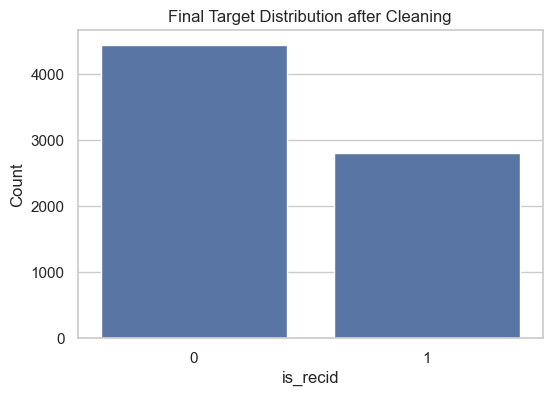

In [45]:
# Plot final target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='is_recid')
plt.title("Final Target Distribution after Cleaning")
plt.xlabel("is_recid")
plt.ylabel("Count")
plt.show()

After cleaning, the target variable still contains two classes:

- `0`: No recidivism
- `1`: Recidivism

This confirms that the dataset is ready for binary classification.

In [46]:
# Check final race distribution
df_clean['race'].value_counts()

race
African-American    4402
Caucasian           2865
Name: count, dtype: int64

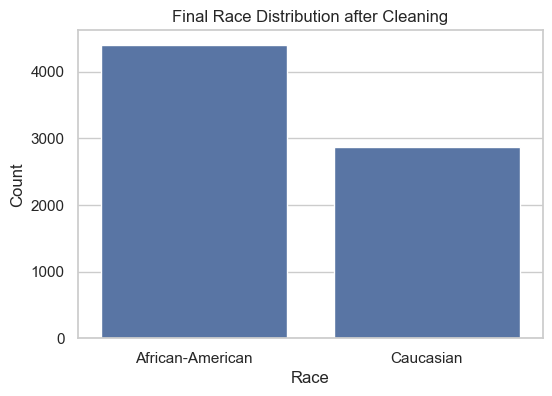

In [47]:
# Plot final race distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='race')
plt.title("Final Race Distribution after Cleaning")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()

The final dataset contains only African-American and Caucasian defendants.

This allows us to conduct a focused fairness analysis between the two main racial groups in the dataset.

Machine learning models require numerical input.

Therefore, categorical variables such as `sex`, `age_cat`, `race`, and `c_charge_degree` must be converted into numerical variables.

We will create a separate dataframe called `df_model`.

Important:

- `is_recid` is the target variable.
- `race_binary` is kept for fairness evaluation.
- `score_text` and `decile_score` are not used as model input features because they come from the original COMPAS algorithm.

In [48]:
# Create a copy for machine learning
df_model = df_clean.copy()

# Display current columns
df_model.columns

Index(['sex', 'age', 'age_cat', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'is_recid',
       'score_text', 'decile_score', 'race_binary'],
      dtype='object')

In [49]:
# We keep score_text and decile_score in df_clean for baseline COMPAS analysis.
# But for our machine learning model, we remove them from model input data.

df_model = df_model.drop(columns=['score_text', 'decile_score'])

# Display first rows
df_model.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,is_recid,race_binary
3,Male,34,25 - 45,African-American,0,0,0,0,(F3),1,0
4,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,0
9,Male,23,Less than 25,African-American,0,1,0,1,(F3),0,0
12,Male,41,25 - 45,Caucasian,0,0,0,14,(F3),1,1
17,Female,39,25 - 45,Caucasian,0,0,0,0,(M1),0,1


The columns `score_text` and `decile_score` are removed from `df_model`.

Reason:

These columns are outputs from the original COMPAS system. If we include them as features, our model may simply learn to copy COMPAS instead of learning from independent variables.

## 4.2 Ordinal Encoding for Age Category and Charge Degree

In this section, ordinal encoding is applied to variables that have an ordered structure.

The variable `age_cat` has a natural age order:

- Less than 25
- 25 - 45
- Greater than 45

Therefore, it is encoded as:

- Less than 25 = 0
- 25 - 45 = 1
- Greater than 45 = 2

The variable `c_charge_degree` contains charge codes such as `(F3)`, `(M1)`, `(F2)`, `(MO3)`, `(NI0)`, `(CO3)`, and `(X)`.

Instead of treating every detailed charge code as a separate category, the main alphabetic charge group is extracted first. For example:

- `(F1)`, `(F2)`, `(F3)` are grouped as `F`
- `(M1)`, `(M2)`, `(MO3)` are grouped as `M`
- `(NI0)` is grouped as `N`
- `(CO3)` and `(CT)` are grouped as `C`
- `(X)` is grouped as `X`

After extracting the main charge group, it is ordinally encoded.

Other variables such as `sex` and `race` are still one-hot encoded because they do not have a natural numerical order.

In [50]:
# Create a copy for machine learning encoding

df_model_encoded = df_model.copy()

# Display unique values before encoding

print("Unique age_cat values:")
print(df_model_encoded['age_cat'].value_counts())

print("\nUnique c_charge_degree values:")
print(df_model_encoded['c_charge_degree'].value_counts(dropna=False))

Unique age_cat values:
age_cat
25 - 45            4244
Greater than 45    1606
Less than 25       1417
Name: count, dtype: int64

Unique c_charge_degree values:
c_charge_degree
(F3)     3898
(M1)     1656
(F2)      716
(M2)      644
(F1)      158
(F7)       98
(MO3)      72
(F6)        9
(NI0)       8
(F5)        5
(X)         1
(CT)        1
(CO3)       1
Name: count, dtype: int64


In [51]:
# Ordinal encoding for age_cat
# age_cat has a natural order.

age_cat_mapping = {
    'Less than 25': 0,
    '25 - 45': 1,
    'Greater than 45': 2
}

df_model_encoded['age_cat_ordinal'] = df_model_encoded['age_cat'].map(age_cat_mapping)

# Check mapping result

df_model_encoded[['age_cat', 'age_cat_ordinal']].head()

,age_cat,age_cat_ordinal
3,25 - 45,1
4,Less than 25,0
9,Less than 25,0
12,25 - 45,1
17,25 - 45,1


In [52]:
# Function to extract main alphabetic charge group from c_charge_degree

def extract_charge_group(charge):
    """
    This function extracts the main alphabetic group from c_charge_degree.

    Examples:
    (F3)  -> F
    (F2)  -> F
    (M1)  -> M
    (MO3) -> M
    (NI0) -> N
    (CO3) -> C
    (CT)  -> C
    (X)   -> X
    (TCX) -> T
    """

    # Convert value to string and remove brackets
    charge = str(charge).replace("(", "").replace(")", "").strip()

    # If charge is missing or empty, return missing
    if charge == "" or charge.lower() == "nan":
        return np.nan

    # Return the first alphabetic character
    for char in charge:
        if char.isalpha():
            return char

    return np.nan


# Apply function to create main charge group

df_model_encoded['c_charge_group'] = df_model_encoded['c_charge_degree'].apply(extract_charge_group)

# Check result

df_model_encoded[['c_charge_degree', 'c_charge_group']].head(20)

,c_charge_degree,c_charge_group
3,(F3),F
4,(F3),F
9,(F3),F
12,(F3),F
17,(M1),M
18,(F3),F
21,(F3),F
24,(F2),F
25,(F3),F
26,(M1),M


In [53]:
# Check charge group distribution

df_model_encoded['c_charge_group'].value_counts(dropna=False)

c_charge_group
F    4884
M    2372
N       8
C       2
X       1
Name: count, dtype: int64

In [54]:
# Ordinal encoding for charge group
# This order is project-defined after grouping charges by main alphabetic code.

charge_group_mapping = {
    'C': 0,
    'M': 1,
    'F': 2,
    'N': 3,
    'T': 4,
    'X': 5
}

df_model_encoded['c_charge_degree_ordinal'] = df_model_encoded['c_charge_group'].map(charge_group_mapping)

# Check mapping

df_model_encoded[
    ['c_charge_degree', 'c_charge_group', 'c_charge_degree_ordinal']
].head(20)

,c_charge_degree,c_charge_group,c_charge_degree_ordinal
3,(F3),F,2
4,(F3),F,2
9,(F3),F,2
12,(F3),F,2
17,(M1),M,1
18,(F3),F,2
21,(F3),F,2
24,(F2),F,2
25,(F3),F,2
26,(M1),M,1


In [55]:
# Check missing values after ordinal encoding

print("Missing values in age_cat_ordinal:")
print(df_model_encoded['age_cat_ordinal'].isnull().sum())

print("\nMissing values in c_charge_degree_ordinal:")
print(df_model_encoded['c_charge_degree_ordinal'].isnull().sum())

Missing values in age_cat_ordinal:
0

Missing values in c_charge_degree_ordinal:
0


In [56]:
# Drop original columns after ordinal encoding

df_model_encoded = df_model_encoded.drop(
    columns=[
        'age_cat',
        'c_charge_degree',
        'c_charge_group'
    ]
)

# Display first rows

df_model_encoded.head()

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal
3,Male,34,African-American,0,0,0,0,1,0,1,2
4,Male,24,African-American,0,0,1,4,1,0,0,2
9,Male,23,African-American,0,1,0,1,0,0,0,2
12,Male,41,Caucasian,0,0,0,14,1,1,1,2
17,Female,39,Caucasian,0,0,0,0,0,1,1,1


In [57]:
# One-hot encode remaining categorical variables
# sex and race do not have a natural ordinal order.

categorical_columns = ['sex', 'race']

df_model_encoded = pd.get_dummies(
    df_model_encoded,
    columns=categorical_columns,
    drop_first=True
)

# Display encoded dataset

df_model_encoded.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
3,34,0,0,0,0,1,0,1,2,True,False
4,24,0,0,1,4,1,0,0,2,True,False
9,23,0,1,0,1,0,0,0,2,True,False
12,41,0,0,0,14,1,1,1,2,True,True
17,39,0,0,0,0,0,1,1,1,False,True


In [58]:
# Check final encoded dataset

print("Final encoded dataset shape:", df_model_encoded.shape)

df_model_encoded.head()

Final encoded dataset shape: (7267, 11)


,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
3,34,0,0,0,0,1,0,1,2,True,False
4,24,0,0,1,4,1,0,0,2,True,False
9,23,0,1,0,1,0,0,0,2,True,False
12,41,0,0,0,14,1,1,1,2,True,True
17,39,0,0,0,0,0,1,1,1,False,True


In [59]:
# Check data types

df_model_encoded.dtypes

age                        int64
juv_fel_count              int64
juv_misd_count             int64
juv_other_count            int64
priors_count               int64
is_recid                   int64
race_binary                int64
age_cat_ordinal            int64
c_charge_degree_ordinal    int64
sex_Male                    bool
race_Caucasian              bool
dtype: object

The categorical variables have now been converted into numerical dummy variables.

For example:

- `sex_Male`
- `age_cat_Greater than 45`
- `age_cat_Less than 25`
- `race_Caucasian`
- `c_charge_degree_M`

The argument `drop_first=True` is used to avoid duplicate information among dummy variables.

In [60]:
# Check shape of final encoded dataset
print("Final encoded dataset shape:", df_model_encoded.shape)

# Display columns
df_model_encoded.columns

Final encoded dataset shape: (7267, 11)


Index(['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'is_recid', 'race_binary', 'age_cat_ordinal',
       'c_charge_degree_ordinal', 'sex_Male', 'race_Caucasian'],
      dtype='object')

In [61]:
# Check data types
df_model_encoded.dtypes

age                        int64
juv_fel_count              int64
juv_misd_count             int64
juv_other_count            int64
priors_count               int64
is_recid                   int64
race_binary                int64
age_cat_ordinal            int64
c_charge_degree_ordinal    int64
sex_Male                    bool
race_Caucasian              bool
dtype: object

In [62]:
# Check missing values in final encoded dataset
df_model_encoded.isnull().sum()

age                        0
juv_fel_count              0
juv_misd_count             0
juv_other_count            0
priors_count               0
is_recid                   0
race_binary                0
age_cat_ordinal            0
c_charge_degree_ordinal    0
sex_Male                   0
race_Caucasian             0
dtype: int64

The final encoded dataset is now ready for machine learning.

All columns are numerical, and there are no missing values.

The dataset contains:

- Feature columns
- Target column: `is_recid`
- Fairness column: `race_binary`

Now we separate the dataset into:

- `X`: input features
- `y`: target variable

The target variable is:

`is_recid`

The protected attribute for fairness analysis is:

`race_binary`

Important:

We will keep `race_binary` separately because it is needed later for fairness evaluation using AIF360.

In [63]:
# Define target variable
y = df_model_encoded['is_recid']

# Define protected attribute
protected_attribute = df_model_encoded['race_binary']

# Define feature matrix
# We remove the target variable from features.
X = df_model_encoded.drop(columns=['is_recid'])

# Check shapes
print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)
print("Protected attribute shape:", protected_attribute.shape)

Feature matrix X shape: (7267, 10)
Target y shape: (7267,)
Protected attribute shape: (7267,)


At this point:

- `X` contains the input features.
- `y` contains the target variable.
- `protected_attribute` contains race information for fairness evaluation.

The actual train-test split will be done later in the section:

 Feature Engineering and Train-Test Split`

It is useful to save the cleaned dataset so that we can reuse it later without repeating all cleaning steps.

We save two files:

1. `compas_clean.csv`: cleaned dataset with original categorical values and COMPAS baseline columns.
2. `compas_model_encoded.csv`: encoded dataset ready for machine learning.

In [64]:
# Save cleaned dataset with readable categorical values
df_clean.to_csv("compas_clean.csv", index=False)

# Save encoded dataset for machine learning
df_model_encoded.to_csv("compas_model_encoded.csv", index=False)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


# 4.3 Summary of Data Cleaning and Preprocessing

In this section, the dataset was cleaned and prepared for machine learning.

The following steps were completed:

1. A copy of the original dataset was created.
2. Invalid target values where `is_recid = -1` were removed.
3. The dataset was filtered to include only African-American and Caucasian defendants.
4. Relevant columns were selected.
5. Missing values were checked and removed.
6. Duplicate rows were checked and removed.
7. A binary protected attribute called `race_binary` was created.
8. COMPAS score columns were removed from machine learning features.
9. Categorical variables were one-hot encoded.
10. Features, target, and protected attribute were separated.
11. Cleaned datasets were saved for later use.

The dataset is now ready for exploratory data analysis and baseline COMPAS score analysis.

During preprocessing, I removed invalid target values because binary classification requires only valid classes 0 and 1. I focused on African-American and Caucasian defendants because these are the two largest groups and are most relevant for the fairness comparison in the COMPAS bias study.

I did not use the COMPAS score variables as input features for my own machine learning models because they are outputs of the original COMPAS system. Including them could cause the model to copy COMPAS predictions. Instead, I kept them separately for baseline comparison.

I also created a binary protected attribute called race_binary, where Caucasian is coded as the privileged group and African-American as the unprivileged group. This will be used later for fairness evaluation and AIF360 bias mitigation.

# 5. Exploratory Data Analysis

Exploratory Data Analysis, or EDA, is used to understand the dataset before training machine learning models.

In this section, we analyze the cleaned COMPAS dataset using tables and visualizations.

The main goals of EDA are:

1. Understand the distribution of the target variable.
2. Understand the distribution of protected attributes such as race.
3. Compare recidivism rates between racial groups.
4. Analyze age, gender, prior offenses, and charge degree.
5. Study how COMPAS scores differ across groups.
6. Identify patterns that may be important for fairness analysis.

EDA helps us understand possible bias in the data before building machine learning models.

In [65]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set style for plots
sns.set(style="whitegrid")

# Show all columns
pd.set_option('display.max_columns', None)

In [66]:
# Load the cleaned dataset created in Section 5

df_clean = pd.read_csv("compas_clean.csv")

# Display first few rows
df_clean.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,is_recid,score_text,decile_score,race_binary
0,Male,34,25 - 45,African-American,0,0,0,0,(F3),1,Low,3,0
1,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4,0
2,Male,23,Less than 25,African-American,0,1,0,1,(F3),0,High,8,0
3,Male,41,25 - 45,Caucasian,0,0,0,14,(F3),1,Medium,6,1
4,Female,39,25 - 45,Caucasian,0,0,0,0,(M1),0,Low,1,1


In [67]:
# Check shape of cleaned dataset

print("Number of rows:", df_clean.shape[0])
print("Number of columns:", df_clean.shape[1])

Number of rows: 7267
Number of columns: 13


The cleaned dataset contains only valid target values and the two main racial groups selected for fairness analysis:

- African-American
- Caucasian

## 5.1 Target Variable Distribution

The target variable is `is_recid`.

- `0` means the defendant did not reoffend.
- `1` means the defendant reoffended.

Checking the target distribution helps us understand whether the classification problem is balanced or imbalanced.

In [68]:
# Count target values

target_counts = df_clean['is_recid'].value_counts()
target_counts

is_recid
0    4452
1    2815
Name: count, dtype: int64

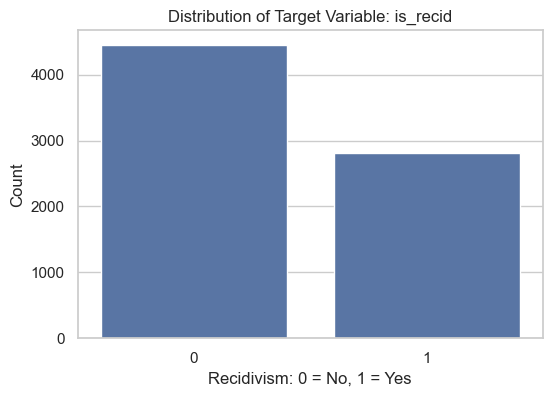

In [69]:
# Plot target variable distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='is_recid')
plt.title("Distribution of Target Variable: is_recid")
plt.xlabel("Recidivism: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

The target distribution shows how many defendants reoffended and how many did not.

If both classes are reasonably represented, classification models can learn both outcomes better. If one class is much smaller, we may need special handling such as class weighting.

In [70]:
# Count race values

race_counts = df_clean['race'].value_counts()
race_counts

race
African-American    4402
Caucasian           2865
Name: count, dtype: int64

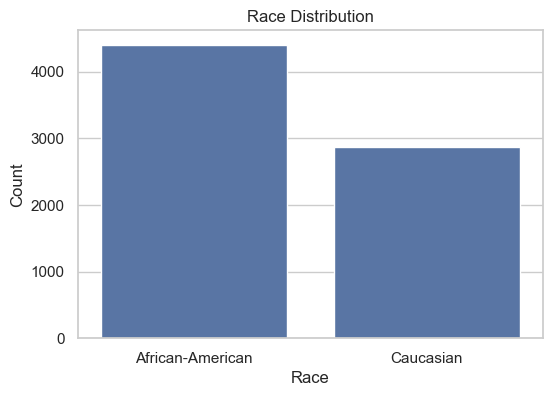

In [71]:
# Plot race distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='race', order=df_clean['race'].value_counts().index)
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.show()

This plot shows the number of defendants in each racial group.

A difference in group sizes is important because model performance and fairness metrics can be affected by unequal representation in the dataset.

## 5.2 Recidivism Rate by Race

This analysis compares the actual recidivism rate between African-American and Caucasian defendants.

This is not yet a model fairness result. It only describes the observed outcomes in the dataset.

In [72]:
# Calculate recidivism counts by race

race_recid_counts = pd.crosstab(df_clean['race'], df_clean['is_recid'])
race_recid_counts

is_recid,0,1
race,,
African-American,2548,1854
Caucasian,1904,961


In [73]:
# Calculate recidivism percentage by race

race_recid_percent = pd.crosstab(
    df_clean['race'],
    df_clean['is_recid'],
    normalize='index'
) * 100

race_recid_percent

is_recid,0,1
race,,
African-American,57.882781,42.117219
Caucasian,66.457243,33.542757


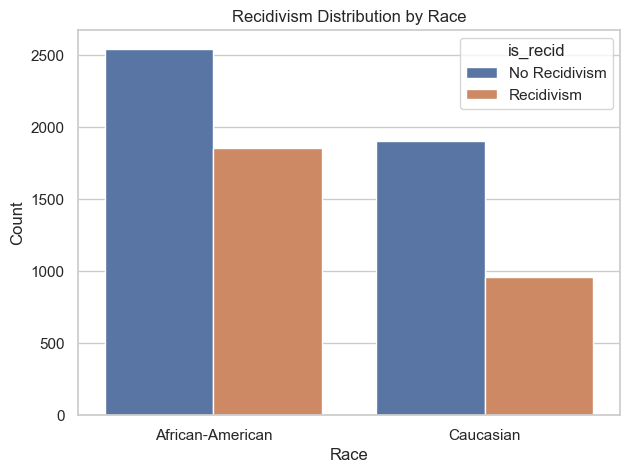

In [74]:
# Plot recidivism by race

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='race', hue='is_recid')
plt.title("Recidivism Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.legend(title="is_recid", labels=["No Recidivism", "Recidivism"])
plt.show()

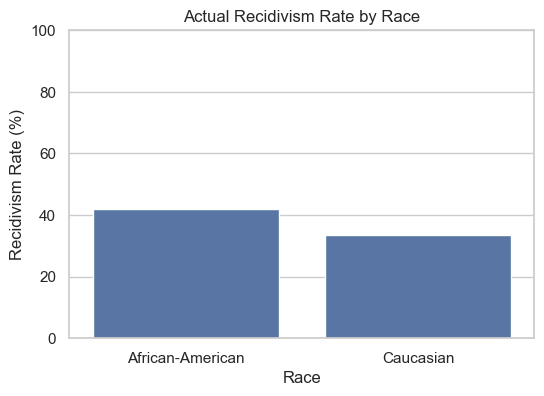

race
African-American    42.117219
Caucasian           33.542757
Name: is_recid, dtype: float64

In [75]:
# Plot recidivism rate by race

recid_rate_by_race = df_clean.groupby('race')['is_recid'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=recid_rate_by_race.index, y=recid_rate_by_race.values)
plt.title("Actual Recidivism Rate by Race")
plt.xlabel("Race")
plt.ylabel("Recidivism Rate (%)")
plt.ylim(0, 100)
plt.show()

recid_rate_by_race

The bar chart shows the actual recidivism rate for each racial group.

This is important because fairness analysis should not only compare prediction rates, but also compare error rates such as false positives and false negatives.

## 5.3 Gender Distribution

The variable `sex` shows the gender of defendants in the dataset.

Although race is the main protected attribute in this project, gender can also be examined as an additional demographic variable.

In [76]:
# Count gender values

df_clean['sex'].value_counts()

sex
Male      5676
Female    1591
Name: count, dtype: int64

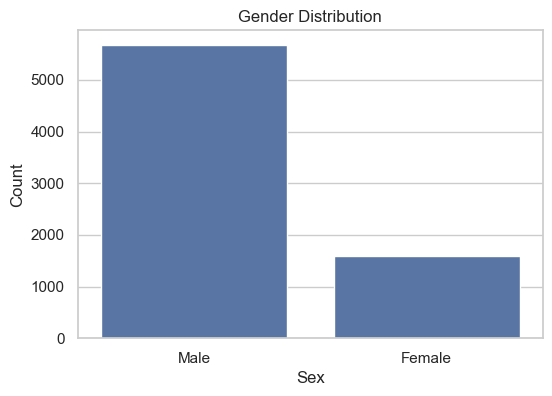

In [77]:
# Plot gender distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='sex')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

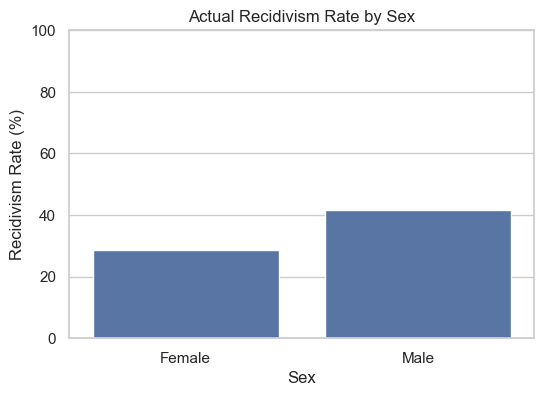

sex
Female    28.661219
Male      41.560958
Name: is_recid, dtype: float64

In [78]:
# Recidivism rate by gender

recid_rate_by_sex = df_clean.groupby('sex')['is_recid'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=recid_rate_by_sex.index, y=recid_rate_by_sex.values)
plt.title("Actual Recidivism Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Recidivism Rate (%)")
plt.ylim(0, 100)
plt.show()

recid_rate_by_sex

This helps us understand whether recidivism rates differ between male and female defendants.

However, the main fairness evaluation in this project will focus on race.

## 5.4 Age Distribution

Age is an important feature in recidivism prediction.

Younger defendants may have different risk patterns compared with older defendants. Therefore, we analyze both numerical age and age categories.

In [79]:
# Summary statistics for age

df_clean['age'].describe()

count    7267.000000
mean       35.154397
std        11.930692
min        18.000000
25%        26.000000
50%        32.000000
75%        43.000000
max        83.000000
Name: age, dtype: float64

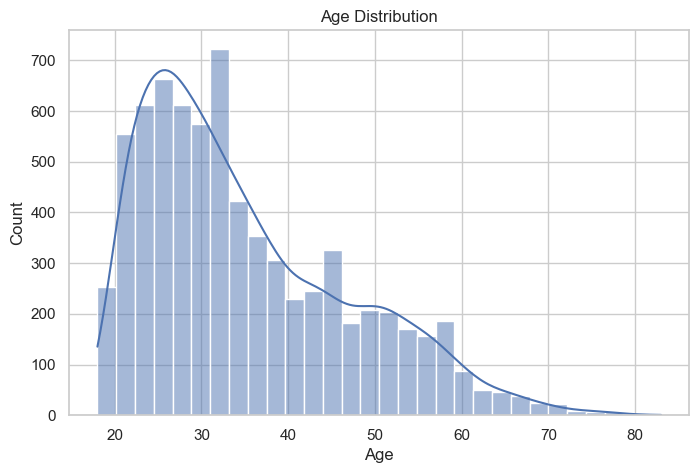

In [80]:
# Plot age distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='age', bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [81]:
# Create ordinal age category for EDA explanation

age_cat_mapping = {
    'Less than 25': 0,
    '25 - 45': 1,
    'Greater than 45': 2
}

df_clean['age_cat_ordinal'] = df_clean['age_cat'].map(age_cat_mapping)

# Check mapping

df_clean[['age_cat', 'age_cat_ordinal']].drop_duplicates().sort_values('age_cat_ordinal')

,age_cat,age_cat_ordinal
1,Less than 25,0
0,25 - 45,1
13,Greater than 45,2


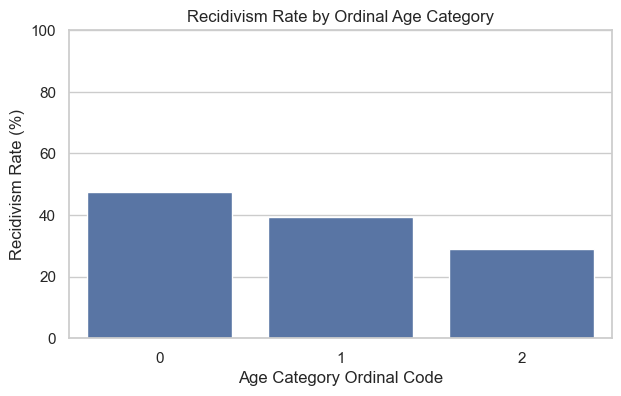

age_cat_ordinal
0    47.565279
1    39.467484
2    29.016189
Name: is_recid, dtype: float64

In [82]:
# Recidivism rate by ordinal age category

age_ordinal_recid = df_clean.groupby('age_cat_ordinal')['is_recid'].mean() * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=age_ordinal_recid.index, y=age_ordinal_recid.values)

plt.title("Recidivism Rate by Ordinal Age Category")
plt.xlabel("Age Category Ordinal Code")
plt.ylabel("Recidivism Rate (%)")
plt.ylim(0, 100)
plt.show()

age_ordinal_recid

In [83]:
# Age category distribution

df_clean['age_cat_ordinal'].value_counts()

age_cat_ordinal
1    4244
2    1606
0    1417
Name: count, dtype: int64

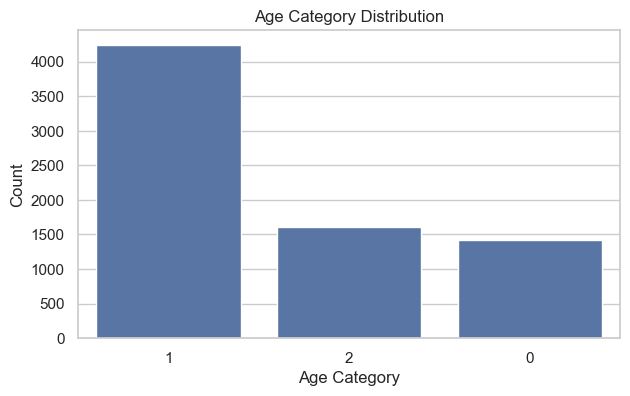

In [84]:
# Plot age category distribution

plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x='age_cat_ordinal', order=df_clean['age_cat_ordinal'].value_counts().index)
plt.title("Age Category Distribution")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.show()

## 5.5 Prior Offenses Distribution

The variable `priors_count` represents the number of prior offenses.

This is usually an important predictor because previous criminal history may be associated with future recidivism.

In [85]:
# Summary statistics for priors_count

df_clean['priors_count'].describe()

count    7267.000000
mean        4.095638
std         5.196583
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        43.000000
Name: priors_count, dtype: float64

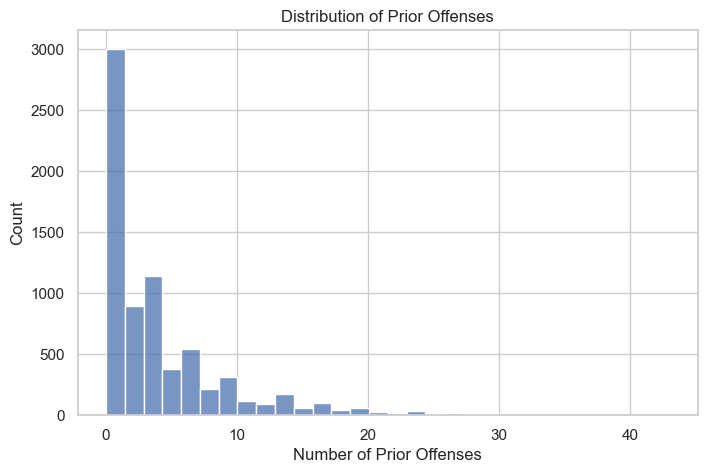

In [86]:
# Plot distribution of prior offenses

plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='priors_count', bins=30)
plt.title("Distribution of Prior Offenses")
plt.xlabel("Number of Prior Offenses")
plt.ylabel("Count")
plt.show()

In [87]:
# Recidivism rate by priors_count
# Since priors_count can have many values, we group it into categories.

df_clean['priors_category'] = pd.cut(
    df_clean['priors_count'],
    bins=[-1, 0, 3, 10, df_clean['priors_count'].max()],
    labels=['0 priors', '1-3 priors', '4-10 priors', 'More than 10 priors']
)

df_clean[['priors_count', 'priors_category']].head()

,priors_count,priors_category
0,0,0 priors
1,4,4-10 priors
2,1,1-3 priors
3,14,More than 10 priors
4,0,0 priors


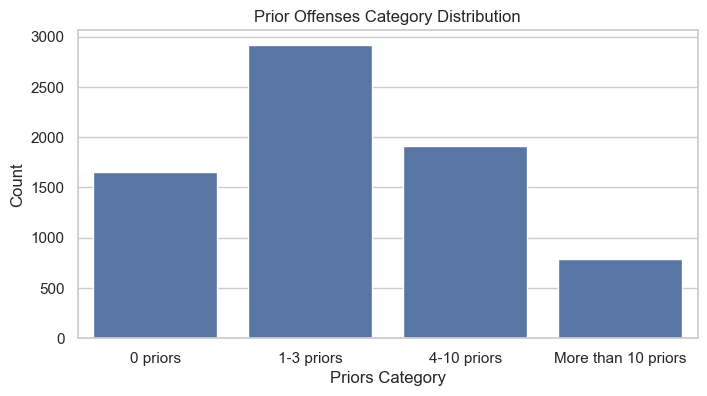

In [88]:
# Plot priors category distribution

plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='priors_category')
plt.title("Prior Offenses Category Distribution")
plt.xlabel("Priors Category")
plt.ylabel("Count")
plt.show()

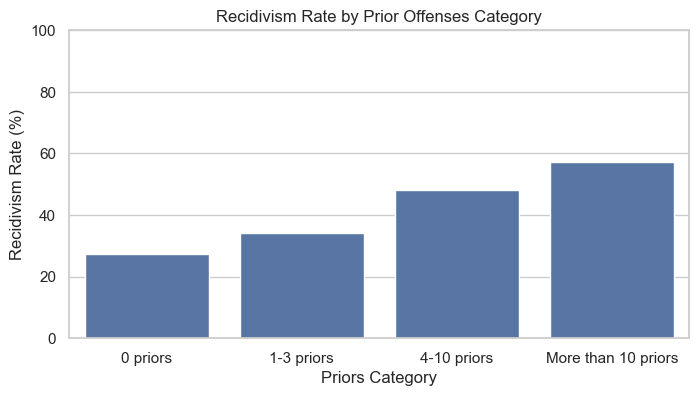

priors_category
0 priors               27.377347
1-3 priors             34.087016
4-10 priors            48.014629
More than 10 priors    57.343550
Name: is_recid, dtype: float64

In [89]:
# Recidivism rate by priors category

recid_rate_by_priors = df_clean.groupby('priors_category', observed=False)['is_recid'].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=recid_rate_by_priors.index, y=recid_rate_by_priors.values)
plt.title("Recidivism Rate by Prior Offenses Category")
plt.xlabel("Priors Category")
plt.ylabel("Recidivism Rate (%)")
plt.ylim(0, 100)
plt.show()

recid_rate_by_priors

This analysis shows whether defendants with more prior offenses have higher observed recidivism rates.

This variable is expected to be important in classification models.


- ## 5.6 Charge Degree Group Distribution

The variable `c_charge_degree` contains charge codes such as:

- F-type charges, for example F1, F2, F3
- M-type charges, for example M1, M2, MO3
- N-type charges, for example NI0
- C-type charges, for example CO3 or CT
- X-type charges, for example X

Instead of treating every detailed charge code as a separate category, we group charges by their main alphabetic code.

This follows the preprocessing strategy used later in the model.

For example:

- F1, F2, F3 are grouped as F
- M1, M2, MO3 are grouped as M
- NI0 is grouped as N
- CO3 and CT are grouped as C
- X remains X

After grouping, the charge group is encoded ordinally for model training.

In [90]:
# Check original charge degree values

df_clean['c_charge_degree'].value_counts(dropna=False)

c_charge_degree
(F3)     3898
(M1)     1656
(F2)      716
(M2)      644
(F1)      158
(F7)       98
(MO3)      72
(F6)        9
(NI0)       8
(F5)        5
(X)         1
(CT)        1
(CO3)       1
Name: count, dtype: int64

In [91]:
# Function to extract main alphabetic charge group

def extract_charge_group(charge):
    """
    Extract the main alphabetic charge group from c_charge_degree.

    Examples:
    (F3)  -> F
    (M1)  -> M
    (MO3) -> M
    (NI0) -> N
    (CO3) -> C
    (CT)  -> C
    (X)   -> X
    """

    charge = str(charge).replace("(", "").replace(")", "").strip()

    if charge == "" or charge.lower() == "nan":
        return np.nan

    for char in charge:
        if char.isalpha():
            return char

    return np.nan


# Apply function

df_clean['c_charge_group'] = df_clean['c_charge_degree'].apply(extract_charge_group)

# Check grouped values

df_clean[['c_charge_degree', 'c_charge_group']].head(20)

,c_charge_degree,c_charge_group
0,(F3),F
1,(F3),F
2,(F3),F
3,(F3),F
4,(M1),M
5,(F3),F
6,(F3),F
7,(F2),F
8,(F3),F
9,(M1),M


In [92]:
# Distribution of grouped charge types

df_clean['c_charge_group'].value_counts(dropna=False)

c_charge_group
F    4884
M    2372
N       8
C       2
X       1
Name: count, dtype: int64

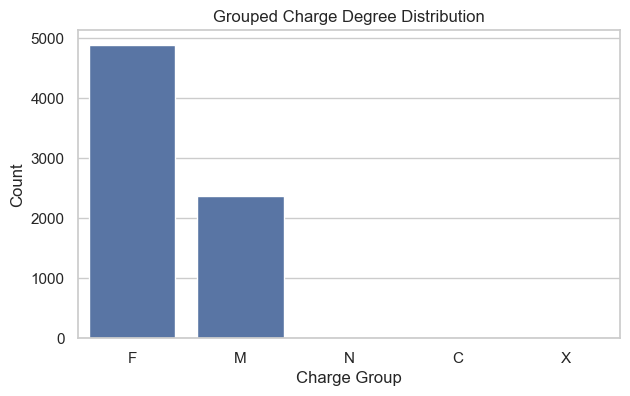

In [93]:
# Plot charge group distribution

plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_clean,
    x='c_charge_group',
    order=df_clean['c_charge_group'].value_counts().index
)

plt.title("Grouped Charge Degree Distribution")
plt.xlabel("Charge Group")
plt.ylabel("Count")
plt.show()

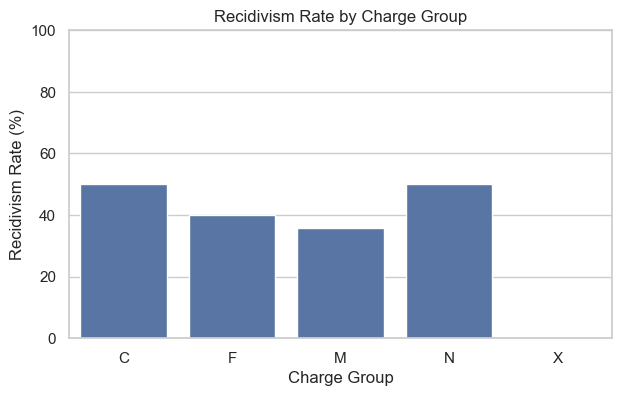

c_charge_group
C    50.000000
F    40.110565
M    35.876897
N    50.000000
X     0.000000
Name: is_recid, dtype: float64

In [94]:
# Recidivism rate by charge group

charge_group_recid = df_clean.groupby('c_charge_group')['is_recid'].mean() * 100

plt.figure(figsize=(7, 4))
sns.barplot(
    x=charge_group_recid.index,
    y=charge_group_recid.values
)

plt.title("Recidivism Rate by Charge Group")
plt.xlabel("Charge Group")
plt.ylabel("Recidivism Rate (%)")
plt.ylim(0, 100)
plt.show()

charge_group_recid

In [95]:
# Ordinal encoding for charge group for EDA explanation

charge_group_mapping = {
    'C': 0,
    'M': 1,
    'F': 2,
    'N': 3,
    'T': 4,
    'X': 5
}

df_clean['c_charge_degree_ordinal'] = df_clean['c_charge_group'].map(charge_group_mapping)

# Check mapping

df_clean[['c_charge_degree', 'c_charge_group', 'c_charge_degree_ordinal']].drop_duplicates().sort_values(
    'c_charge_degree_ordinal'
)

,c_charge_degree,c_charge_group,c_charge_degree_ordinal
489,(CT),C,0
6989,(CO3),C,0
4,(M1),M,1
23,(M2),M,1
97,(MO3),M,1
0,(F3),F,2
7,(F2),F,2
22,(F1),F,2
90,(F7),F,2
1244,(F6),F,2


The grouped charge variable is used in model preprocessing.

Instead of one-hot encoding every detailed charge code, the model uses the ordinal variable `c_charge_degree_ordinal`.

This reduces feature complexity and follows the instruction to group alphabetic charge types before ordinal encoding.

## 5.7 COMPAS Score Distribution

The COMPAS algorithm gives defendants a risk score.

Important variables are:

- `decile_score`: numerical risk score from 1 to 10
- `score_text`: risk category, such as Low, Medium, or High

These variables are not used as input features for our own models, but they are used to create a baseline COMPAS prediction.

In [96]:
# COMPAS score text distribution

df_clean['score_text'].value_counts()

score_text
Low       3438
Medium    2116
High      1713
Name: count, dtype: int64

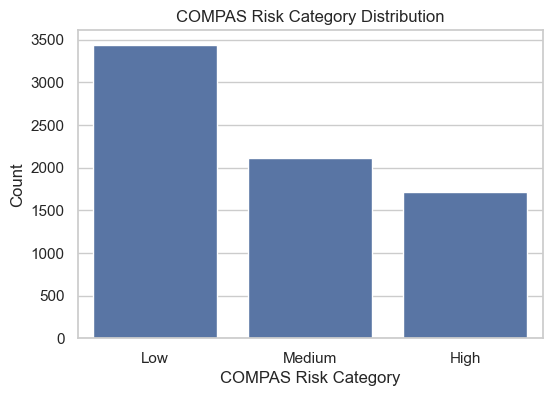

In [97]:
# Plot COMPAS score category distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='score_text', order=['Low', 'Medium', 'High'])
plt.title("COMPAS Risk Category Distribution")
plt.xlabel("COMPAS Risk Category")
plt.ylabel("Count")
plt.show()

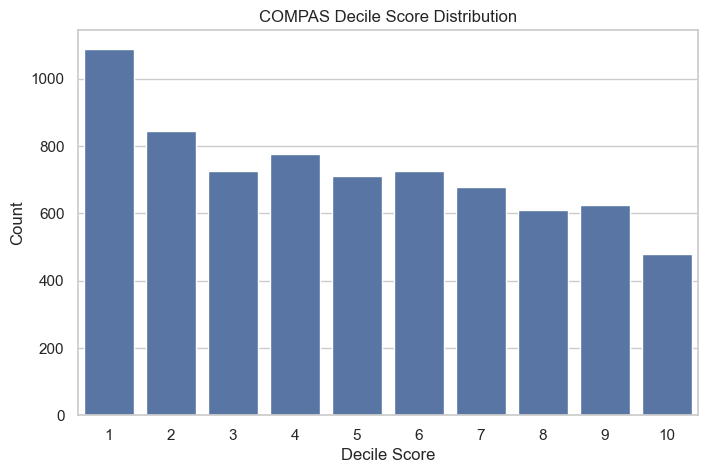

In [98]:
# COMPAS decile score distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='decile_score')
plt.title("COMPAS Decile Score Distribution")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.show()

The COMPAS score distribution shows how many defendants were classified as Low, Medium, or High risk by the original COMPAS system.

## 5.8 COMPAS Score by Race

This analysis checks whether COMPAS risk categories are distributed differently across racial groups.

In [99]:
# COMPAS risk category by race

compas_race_table = pd.crosstab(df_clean['race'], df_clean['score_text'])
compas_race_table

score_text,High,Low,Medium
race,,,
African-American,1331,1689,1382
Caucasian,382,1749,734


In [100]:
# Percentage table

compas_race_percent = pd.crosstab(
    df_clean['race'],
    df_clean['score_text'],
    normalize='index'
) * 100

compas_race_percent

score_text,High,Low,Medium
race,,,
African-American,30.236256,38.368923,31.394821
Caucasian,13.333333,61.047120,25.619546


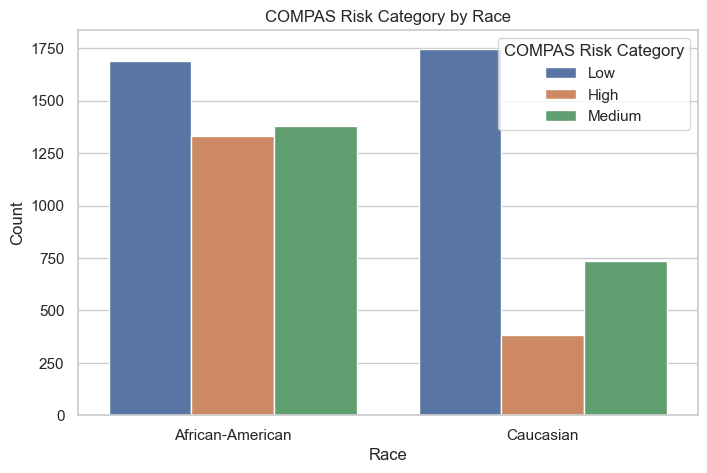

In [101]:
# Plot COMPAS score category by race

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='race', hue='score_text')
plt.title("COMPAS Risk Category by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.legend(title="COMPAS Risk Category")
plt.show()

This plot helps us visually compare whether one racial group receives Medium or High COMPAS scores more often than the other group.

This motivates the baseline fairness analysis in the next section.

# 5.9 EDA Summary

From the exploratory data analysis, we observed the following:

1. The dataset is now focused on African-American and Caucasian defendants.
2. The target variable `is_recid` is binary.
3. Race distribution is not perfectly balanced.
4. Actual recidivism rates differ between racial groups.
5. Age, prior offenses, and charge degree show relationships with recidivism.
6. COMPAS risk scores are distributed differently across racial groups.
7. These observations show why fairness evaluation is necessary.

In the next section, we evaluate the original COMPAS score as a baseline classifier.

# 6. Baseline COMPAS Score Analysis

Before training our own machine learning models, we evaluate the original COMPAS score as a baseline classifier.

The COMPAS score includes a categorical variable called `score_text`.

The values are:

- `Low`
- `Medium`
- `High`

To convert this into a binary prediction:

- `Low` is treated as predicted no recidivism.
- `Medium` and `High` are treated as predicted recidivism.

This gives us a baseline prediction that can be compared with our machine learning models later.

## 6.1 Create Binary COMPAS Prediction

We create a new column called `compas_pred`.

The rule is:

- If `score_text` is `Low`, then `compas_pred = 0`.
- If `score_text` is `Medium` or `High`, then `compas_pred = 1`.

In [102]:
# Create a copy for baseline analysis

df_baseline = df_clean.copy()

# Create binary COMPAS prediction
# Low risk means predicted no recidivism.
# Medium or High risk means predicted recidivism.

df_baseline['compas_pred'] = df_baseline['score_text'].map({
    'Low': 0,
    'Medium': 1,
    'High': 1
})

# Display selected columns
df_baseline[['score_text', 'compas_pred', 'is_recid']].head(10)

,score_text,compas_pred,is_recid
0,Low,0,1
1,Low,0,1
2,High,1,0
3,Medium,1,1
4,Low,0,0
5,High,1,0
6,Medium,1,0
7,Low,0,1
8,Low,0,0
9,Medium,1,1


In [103]:
# Check whether compas_pred has missing values

df_baseline['compas_pred'].isnull().sum()

np.int64(0)

In [104]:
# Check distribution of COMPAS predictions

df_baseline['compas_pred'].value_counts()

compas_pred
1    3829
0    3438
Name: count, dtype: int64

The original COMPAS risk categories have now been converted into a binary prediction.

This allows us to evaluate COMPAS using normal classification metrics.

In [105]:
# Import classification metrics from scikit-learn

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

We import standard classification metrics.

These metrics are used to evaluate the baseline COMPAS prediction.

The metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

In [106]:
# Define true labels and COMPAS predicted labels

y_true_compas = df_baseline['is_recid']
y_pred_compas = df_baseline['compas_pred']

Here:

- `y_true_compas` contains the actual recidivism outcomes.
- `y_pred_compas` contains the binary COMPAS predictions.

In [107]:
# Calculate classification metrics for COMPAS baseline

compas_accuracy = accuracy_score(y_true_compas, y_pred_compas)
compas_precision = precision_score(y_true_compas, y_pred_compas)
compas_recall = recall_score(y_true_compas, y_pred_compas)
compas_f1 = f1_score(y_true_compas, y_pred_compas)
compas_auc = roc_auc_score(y_true_compas, y_pred_compas)

# Print results

print("COMPAS Baseline Performance")
print("---------------------------")
print("Accuracy :", round(compas_accuracy, 4))
print("Precision:", round(compas_precision, 4))
print("Recall   :", round(compas_recall, 4))
print("F1-score :", round(compas_f1, 4))
print("ROC-AUC  :", round(compas_auc, 4))

COMPAS Baseline Performance
---------------------------
Accuracy : 0.5921
Precision: 0.4805
Recall   : 0.6536
F1-score : 0.5539
ROC-AUC  : 0.6034


These metrics show how well the original COMPAS score predicts actual recidivism.

However, performance metrics alone are not enough. We also need to check whether the errors are distributed fairly across racial groups.

In [108]:
# Display detailed classification report

print(classification_report(y_true_compas, y_pred_compas))

              precision    recall  f1-score   support

           0       0.72      0.55      0.62      4452
           1       0.48      0.65      0.55      2815

    accuracy                           0.59      7267
   macro avg       0.60      0.60      0.59      7267
weighted avg       0.63      0.59      0.60      7267



The classification report gives precision, recall, and F1-score for each class.

This helps us understand how well the baseline performs for:

- Class 0: No recidivism
- Class 1: Recidivism

## 6.2 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions.

For binary classification:

| Term | Meaning |
|---|---|
| True Negative | Actual no recidivism and predicted no recidivism |
| False Positive | Actual no recidivism but predicted recidivism |
| False Negative | Actual recidivism but predicted no recidivism |
| True Positive | Actual recidivism and predicted recidivism |

In [109]:
# Compute confusion matrix

cm_compas = confusion_matrix(y_true_compas, y_pred_compas)

cm_compas

array([[2463, 1989],
       [ 975, 1840]])

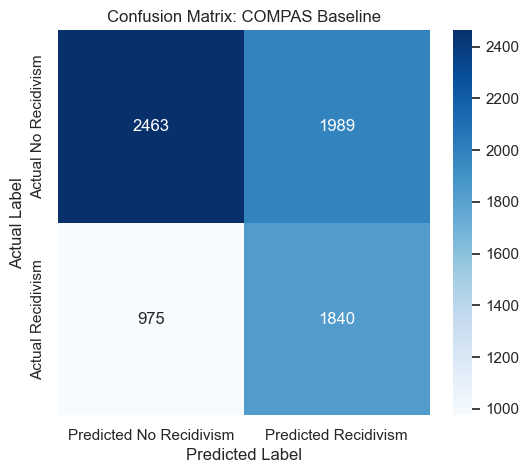

In [110]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_compas,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No Recidivism', 'Predicted Recidivism'],
    yticklabels=['Actual No Recidivism', 'Actual Recidivism']
)

plt.title("Confusion Matrix: COMPAS Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

The confusion matrix helps us identify the types of errors made by the COMPAS baseline.

In fairness analysis, two important error types are:

- False positives: People predicted as high risk but did not reoffend.
- False negatives: People predicted as low risk but did reoffend.

False positives are especially important in this context because they may lead to unfairly harsh decisions.

## 6.3 COMPAS Performance by Race

Now we calculate performance metrics separately for African-American and Caucasian defendants.

This helps us check whether COMPAS performs equally well for both groups.

In [111]:
# Function to calculate classification metrics for each group

def classification_metrics_by_group(data, group_column, y_true_column, y_pred_column):
    """
    This function calculates classification metrics separately for each group.
    
    Parameters:
    data: dataframe
    group_column: column used to define groups, for example race
    y_true_column: actual target column
    y_pred_column: predicted target column
    
    Returns:
    A dataframe with accuracy, precision, recall, and F1-score for each group.
    """
    
    results = []
    
    for group in data[group_column].unique():
        group_data = data[data[group_column] == group]
        
        y_true = group_data[y_true_column]
        y_pred = group_data[y_pred_column]
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'Group': group,
            'Number of Records': len(group_data),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1
        })
    
    return pd.DataFrame(results)

In [112]:
# Calculate COMPAS performance by race

compas_group_metrics = classification_metrics_by_group(
    data=df_baseline,
    group_column='race',
    y_true_column='is_recid',
    y_pred_column='compas_pred'
)

compas_group_metrics

,Group,Number of Records,Accuracy,Precision,Recall,F1-score
0,African-American,4402,0.569060,0.492075,0.720065,0.584629
1,Caucasian,2865,0.627574,0.452509,0.525494,0.486278


This table compares classification performance separately for each racial group.

If performance is very different across groups, it suggests that the baseline system may not be equally reliable for all groups.

## 6.4 Calculate Fairness Error Rates Manually

Fairness analysis often focuses on error rates.

Important fairness-related error rates are:

| Metric | Meaning |
|---|---|
| False Positive Rate | Among people who did not reoffend, how many were wrongly predicted as reoffenders |
| False Negative Rate | Among people who did reoffend, how many were wrongly predicted as non-reoffenders |
| True Positive Rate | Among people who did reoffend, how many were correctly predicted as reoffenders |
| Selection Rate | Percentage of people predicted as positive or high risk |

In this project, positive prediction means predicted recidivism or high risk.

In [113]:
# Function to calculate fairness-related rates by group

def fairness_rates_by_group(data, group_column, y_true_column, y_pred_column):
    """
    This function calculates fairness-related rates separately for each group.
    
    It calculates:
    - False Positive Rate
    - False Negative Rate
    - True Positive Rate
    - True Negative Rate
    - Selection Rate
    
    Positive class = 1
    Negative class = 0
    """
    
    results = []
    
    for group in data[group_column].unique():
        group_data = data[data[group_column] == group]
        
        y_true = group_data[y_true_column]
        y_pred = group_data[y_pred_column]
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
        # Add small safety checks to avoid division by zero
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) != 0 else 0
        selection_rate = y_pred.mean()
        
        results.append({
            'Group': group,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'False Positive Rate': fpr,
            'False Negative Rate': fnr,
            'True Positive Rate': tpr,
            'True Negative Rate': tnr,
            'Selection Rate': selection_rate
        })
    
    return pd.DataFrame(results)

In [114]:
# Calculate fairness error rates for COMPAS baseline

compas_fairness_rates = fairness_rates_by_group(
    data=df_baseline,
    group_column='race',
    y_true_column='is_recid',
    y_pred_column='compas_pred'
)

compas_fairness_rates

,Group,TN,FP,FN,TP,False Positive Rate,False Negative Rate,True Positive Rate,True Negative Rate,Selection Rate
0,African-American,1170,1378,519,1335,0.540816,0.279935,0.720065,0.459184,0.616311
1,Caucasian,1293,611,456,505,0.320903,0.474506,0.525494,0.679097,0.389529


This table shows fairness-related error rates for each racial group.

The most important values for the COMPAS bias discussion are:

- False Positive Rate
- False Negative Rate
- Selection Rate

A high false positive rate means that more people who did not reoffend were incorrectly labeled as high risk.

## 6.5 Calculate Fairness Differences

Next, we calculate the difference in fairness metrics between African-American and Caucasian defendants.

In this project:

- African-American is treated as the unprivileged group.
- Caucasian is treated as the privileged group.

We calculate:

- False Positive Rate Difference
- False Negative Rate Difference
- True Positive Rate Difference
- Selection Rate Difference

Difference formula:

`Unprivileged group rate - Privileged group rate`

A value close to 0 means the metric is similar across groups.

In [115]:
# Extract fairness rates for each group

aa_rates = compas_fairness_rates[
    compas_fairness_rates['Group'] == 'African-American'
].iloc[0]

caucasian_rates = compas_fairness_rates[
    compas_fairness_rates['Group'] == 'Caucasian'
].iloc[0]

# Calculate differences: African-American - Caucasian

fpr_difference = aa_rates['False Positive Rate'] - caucasian_rates['False Positive Rate']
fnr_difference = aa_rates['False Negative Rate'] - caucasian_rates['False Negative Rate']
tpr_difference = aa_rates['True Positive Rate'] - caucasian_rates['True Positive Rate']
selection_rate_difference = aa_rates['Selection Rate'] - caucasian_rates['Selection Rate']

# Display results

print("COMPAS Fairness Differences")
print("---------------------------")
print("False Positive Rate Difference:", round(fpr_difference, 4))
print("False Negative Rate Difference:", round(fnr_difference, 4))
print("True Positive Rate Difference :", round(tpr_difference, 4))
print("Selection Rate Difference     :", round(selection_rate_difference, 4))

COMPAS Fairness Differences
---------------------------
False Positive Rate Difference: 0.2199
False Negative Rate Difference: -0.1946
True Positive Rate Difference : 0.1946
Selection Rate Difference     : 0.2268


These fairness differences help us understand whether COMPAS produces different types of errors for different racial groups.

For example:

- A positive false positive rate difference means African-American defendants are more often wrongly predicted as high risk compared with Caucasian defendants.
- A negative false negative rate difference means African-American defendants are less often wrongly predicted as low risk compared with Caucasian defendants.

In [116]:
# Convert fairness rates to long format for easier plotting

fairness_plot_data = compas_fairness_rates.melt(
    id_vars='Group',
    value_vars=[
        'False Positive Rate',
        'False Negative Rate',
        'True Positive Rate',
        'Selection Rate'
    ],
    var_name='Metric',
    value_name='Rate'
)

fairness_plot_data

,Group,Metric,Rate
0,African-American,False Positive Rate,0.540816
1,Caucasian,False Positive Rate,0.320903
2,African-American,False Negative Rate,0.279935
3,Caucasian,False Negative Rate,0.474506
4,African-American,True Positive Rate,0.720065
5,Caucasian,True Positive Rate,0.525494
6,African-American,Selection Rate,0.616311
7,Caucasian,Selection Rate,0.389529


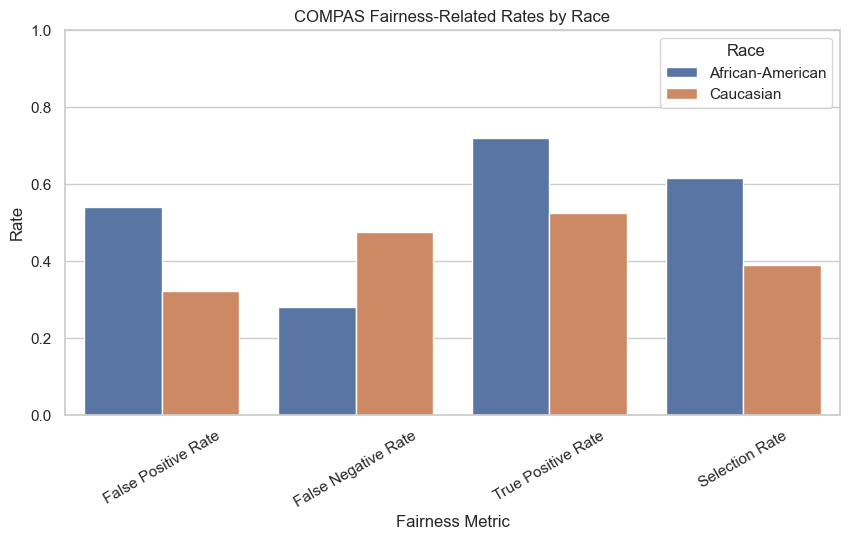

In [117]:
# Plot fairness-related rates by race

plt.figure(figsize=(10, 5))
sns.barplot(data=fairness_plot_data, x='Metric', y='Rate', hue='Group')
plt.title("COMPAS Fairness-Related Rates by Race")
plt.xlabel("Fairness Metric")
plt.ylabel("Rate")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title="Race")
plt.show()

This plot compares important fairness-related rates between African-American and Caucasian defendants.

Large differences between the bars suggest possible fairness concerns.

In [118]:
# Create a summary table for COMPAS baseline

compas_baseline_summary = pd.DataFrame({
    'Model': ['COMPAS Baseline'],
    'Accuracy': [compas_accuracy],
    'Precision': [compas_precision],
    'Recall': [compas_recall],
    'F1-score': [compas_f1],
    'ROC-AUC': [compas_auc],
    'FPR Difference': [fpr_difference],
    'FNR Difference': [fnr_difference],
    'TPR Difference': [tpr_difference],
    'Selection Rate Difference': [selection_rate_difference]
})

compas_baseline_summary

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,TPR Difference,Selection Rate Difference
0,COMPAS Baseline,0.592129,0.480543,0.653641,0.553883,0.603438,0.219913,-0.19457,0.19457,0.226782


In [119]:
# Save the COMPAS baseline results for later comparison

compas_baseline_summary.to_csv("compas_baseline_summary.csv", index=False)

print("COMPAS baseline summary saved successfully.")

COMPAS baseline summary saved successfully.


This table summarizes the baseline COMPAS performance and fairness results.

Later, we will compare this baseline with our own machine learning models.

# 6.6 Baseline COMPAS Analysis Summary

In this section, the original COMPAS risk score was evaluated as a baseline classifier.

The following steps were completed:

1. The COMPAS risk category `score_text` was converted into a binary prediction.
2. `Low` risk was treated as predicted no recidivism.
3. `Medium` and `High` risk were treated as predicted recidivism.
4. Classification metrics were calculated for the COMPAS baseline.
5. A confusion matrix was created.
6. Performance was calculated separately by race.
7. Fairness-related error rates were calculated manually.
8. Fairness differences between African-American and Caucasian defendants were calculated.
9. A baseline summary table was saved for later comparison.

This baseline is important because our later machine learning models should be compared not only by accuracy, but also by fairness.

In the exploratory data analysis section, I studied the cleaned COMPAS dataset before building models. I checked the target distribution, race distribution, age, gender, prior offenses, charge degree, and COMPAS score distribution. I also compared actual recidivism rates and COMPAS score categories across racial groups.

After EDA, I evaluated the original COMPAS score as a baseline model. I converted the COMPAS `score_text` variable into a binary prediction, where Low risk means predicted no recidivism and Medium or High risk means predicted recidivism.

Then I calculated standard classification metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix. I also calculated fairness-related rates such as false positive rate, false negative rate, true positive rate, and selection rate separately for African-American and Caucasian defendants.

This baseline will be used later to compare whether my own machine learning models are more accurate and fairer than the original COMPAS prediction.

# 7. Overview of Fairness Metrics

In normal machine learning classification, we usually evaluate models using performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

However, in fairness-aware machine learning, performance alone is not enough.

A model may have high accuracy overall, but it may still be unfair if it makes more harmful errors for one protected group than another.

In the COMPAS dataset, this is especially important because predictions may influence legal decisions. Therefore, we need to evaluate whether the model behaves differently for different racial groups.

The main protected attribute in this project is:

`race`

For fairness analysis, we mainly compare:

- African-American defendants
- Caucasian defendants

## 7.1 Protected and Privileged Groups

A protected attribute is a sensitive attribute that should be considered when evaluating fairness.

Examples of protected attributes include:

- Race
- Gender
- Age
- Religion
- Disability status

In this project, the protected attribute is:

`race`

For the AIF360 fairness analysis, we define:

| Group | Meaning | Code |
|---|---|---|
| African-American | Unprivileged group | `race_binary = 0` |
| Caucasian | Privileged group | `race_binary = 1` |

This does not mean that one group is better than another. These terms are standard fairness terminology used to compare groups.

The privileged group is usually the group that historically receives more favorable outcomes. The unprivileged group is the group that may be at risk of disadvantage.

## 7.2 Favorable and Unfavorable Outcomes

In the COMPAS dataset, the target variable is:

`is_recid`

It means whether a defendant reoffended.

| Value | Meaning |
|---|---|
| `0` | Did not reoffend |
| `1` | Reoffended |

For classification, we often treat `1` as the positive class.

However, for fairness analysis, we need to define which outcome is favorable.

In this project:

| Outcome | Meaning |
|---|---|
| Favorable outcome | `is_recid = 0`, because the person did not reoffend |
| Unfavorable outcome | `is_recid = 1`, because the person reoffended |

This is important because AIF360 requires us to define favorable and unfavorable labels.

## 7.3 Accuracy

Accuracy measures the percentage of total correct predictions.

It is calculated as:

Accuracy = Correct Predictions / Total Predictions

Accuracy is useful, but it can hide unfairness.

For example, a model may have high overall accuracy but still perform worse for African-American defendants than Caucasian defendants.

## 7.4 Precision

Precision answers the question:

Among all people predicted as reoffenders, how many actually reoffended?

In this project:

- High precision means that when the model predicts someone as likely to reoffend, that prediction is often correct.

Precision is useful when we want to reduce false alarms.

However, precision alone does not tell us whether errors are fairly distributed across racial groups.

## 7.5 Recall / True Positive Rate

Recall is also called True Positive Rate.

It answers the question:

Among all people who actually reoffended, how many did the model correctly identify?

In this project:

- High recall means the model correctly finds many defendants who actually reoffend.

Recall is important, but we also need to check whether recall is similar across racial groups.

## 7.6 False Positive Rate

False Positive Rate is one of the most important fairness metrics in the COMPAS case.

It answers the question:

Among people who did not reoffend, how many were wrongly predicted as reoffenders?

In this project, a false positive means:

- Actual outcome: did not reoffend
- Model prediction: reoffended / high risk

This type of error can be harmful because a person may be wrongly classified as high risk.

If African-American defendants have a much higher false positive rate than Caucasian defendants, this indicates a fairness problem.

## 7.7 False Negative Rate

False Negative Rate answers the question:

Among people who actually reoffended, how many were wrongly predicted as non-reoffenders?

In this project, a false negative means:

- Actual outcome: reoffended
- Model prediction: did not reoffend / low risk

This error means the model failed to identify a person who later reoffended.

Fairness analysis checks whether false negative rates are similar across racial groups.

## 7.8 Statistical Parity Difference

Statistical Parity Difference compares the rate of favorable outcomes between the unprivileged and privileged groups.

General formula:

Statistical Parity Difference = P(favorable outcome | unprivileged group) - P(favorable outcome | privileged group)

In this project:

- Favorable outcome = no recidivism
- Unprivileged group = African-American
- Privileged group = Caucasian

A value close to 0 means both groups receive favorable outcomes at similar rates.

A negative value means the unprivileged group receives favorable outcomes less often than the privileged group.

## 7.9 Disparate Impact

Disparate Impact compares the ratio of favorable outcome rates between the unprivileged and privileged groups.

General formula:

Disparate Impact = P(favorable outcome | unprivileged group) / P(favorable outcome | privileged group)

A value close to 1 means both groups receive favorable outcomes at similar rates.

A value below 1 means the unprivileged group receives favorable outcomes less often than the privileged group.

## 7.10 Equal Opportunity Difference

Equal Opportunity Difference compares the true positive rate between groups.

In many classification problems, this measures whether the model correctly identifies the positive class equally across groups.

In this project, because `1` means recidivism, we must be careful with interpretation.

When we use model predictions later, we will define positive prediction as predicted recidivism or high risk.

Equal Opportunity Difference helps us check whether one racial group is correctly identified as reoffending more often than another group.

## 7.11 Average Odds Difference

Average Odds Difference compares both:

1. False Positive Rate
2. True Positive Rate

between unprivileged and privileged groups.

A value close to 0 means the model has similar error behavior across groups.

This metric is useful because it considers both false positives and true positives.

## 7.12 Why Fairness Metrics Matter

Fairness metrics are important because accuracy alone can be misleading.

For example, suppose two models have the same accuracy:

- Model A has similar false positive rates for both racial groups.
- Model B has a much higher false positive rate for African-American defendants.

Even if both models have the same accuracy, Model A is fairer.

Therefore, this project evaluates both:

1. Model performance
2. Model fairness

The final model should not simply be the most accurate model. It should provide a reasonable balance between accuracy and fairness.

## 7.13 Summary of Fairness Metrics

The main fairness metrics used in this project are:

| Metric | Ideal Value | Meaning |
|---|---:|---|
| Statistical Parity Difference | 0 | Similar favorable outcome rates across groups |
| Disparate Impact | 1 | Similar ratio of favorable outcomes across groups |
| False Positive Rate Difference | 0 | Similar false positive rates across groups |
| False Negative Rate Difference | 0 | Similar false negative rates across groups |
| Equal Opportunity Difference | 0 | Similar true positive rates across groups |
| Average Odds Difference | 0 | Similar error behavior across groups |

In the next section, we use AIF360 to calculate dataset-level fairness metrics.

# 8. Dataset Fairness Analysis using AIF360

AIF360 stands for AI Fairness 360.

It is an open-source Python library developed for fairness-aware machine learning. It provides tools for:

1. Measuring bias in datasets
2. Measuring bias in model predictions
3. Applying bias mitigation algorithms

In this section, we use AIF360 to analyze fairness in the cleaned COMPAS dataset before training our own machine learning models.

This is called dataset-level fairness analysis.

The goal is to check whether favorable outcomes are distributed differently between African-American and Caucasian defendants in the dataset.

## 8.1 Install AIF360


In [120]:
# Install AIF360
# Run this cell only if AIF360 is not installed.

!pip install aif360

In [121]:
# Import basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import AIF360 classes
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

# Set plot style
sns.set(style="whitegrid")

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


We import two important AIF360 classes:

1. `BinaryLabelDataset`
2. `BinaryLabelDatasetMetric`

`BinaryLabelDataset` converts a pandas dataframe into a format that AIF360 can understand.

`BinaryLabelDatasetMetric` calculates fairness metrics for the dataset.

In [122]:
# Load the cleaned dataset from Section 5

df_clean = pd.read_csv("compas_clean.csv")

# Display first few rows
df_clean.head()

,sex,age,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,is_recid,score_text,decile_score,race_binary
0,Male,34,25 - 45,African-American,0,0,0,0,(F3),1,Low,3,0
1,Male,24,Less than 25,African-American,0,0,1,4,(F3),1,Low,4,0
2,Male,23,Less than 25,African-American,0,1,0,1,(F3),0,High,8,0
3,Male,41,25 - 45,Caucasian,0,0,0,14,(F3),1,Medium,6,1
4,Female,39,25 - 45,Caucasian,0,0,0,0,(M1),0,Low,1,1


In [123]:
# Check dataset shape

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 7267
Columns: 13


We load the cleaned dataset created earlier.

This dataset contains:

- Valid target variable values
- African-American and Caucasian groups only
- The binary protected attribute `race_binary`

In [124]:
# Check columns needed for AIF360 analysis

required_columns = ['race', 'race_binary', 'is_recid']

df_clean[required_columns].head()

,race,race_binary,is_recid
0,African-American,0,1
1,African-American,0,1
2,African-American,0,0
3,Caucasian,1,1
4,Caucasian,1,0


In [125]:
# Check values in race_binary

df_clean['race_binary'].value_counts()

race_binary
0    4402
1    2865
Name: count, dtype: int64

In [126]:
# Check values in target variable

df_clean['is_recid'].value_counts()

is_recid
0    4452
1    2815
Name: count, dtype: int64

For AIF360 dataset fairness analysis, we need:

| Column | Purpose |
|---|---|
| `is_recid` | Label / target variable |
| `race_binary` | Protected attribute |
| `race` | Human-readable race group |

The coding is:

| race | race_binary |
|---|---:|
| African-American | 0 |
| Caucasian | 1 |

The label coding is:

| is_recid | Meaning |
|---|---|
| 0 | Did not reoffend |
| 1 | Reoffended |

## 8.2 Prepare Dataframe for AIF360

AIF360 requires all columns in the dataset to be numerical.

Therefore, we create a dataframe for AIF360 using numerical columns only.

We will include:

- `age`
- `juv_fel_count`
- `juv_misd_count`
- `juv_other_count`
- `priors_count`
- `race_binary`
- `is_recid`

For this dataset-level fairness analysis, the most important columns are:

- `race_binary`
- `is_recid`

The other numerical columns are included because AIF360 expects a dataset format with features, labels, and protected attributes.

In [127]:
# Create a dataframe for AIF360 using numerical columns only

aif_columns = [
    'age',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'race_binary',
    'is_recid'
]

df_aif = df_clean[aif_columns].copy()

# Display first rows
df_aif.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,race_binary,is_recid
0,34,0,0,0,0,0,1
1,24,0,0,1,4,0,1
2,23,0,1,0,1,0,0
3,41,0,0,0,14,1,1
4,39,0,0,0,0,1,0


In [128]:
# Check data types

df_aif.dtypes

age                int64
juv_fel_count      int64
juv_misd_count     int64
juv_other_count    int64
priors_count       int64
race_binary        int64
is_recid           int64
dtype: object

In [129]:
# Check missing values

df_aif.isnull().sum()

age                0
juv_fel_count      0
juv_misd_count     0
juv_other_count    0
priors_count       0
race_binary        0
is_recid           0
dtype: int64

The dataframe `df_aif` contains only numerical variables, so it is suitable for conversion into an AIF360 `BinaryLabelDataset`.

## 8.3 Define Privileged and Unprivileged Groups

AIF360 requires us to define privileged and unprivileged groups.

In this project:

| Group | AIF360 Role | race_binary |
|---|---|---:|
| African-American | Unprivileged group | 0 |
| Caucasian | Privileged group | 1 |

We also define:

| Label | Meaning | Fairness Role |
|---|---|---|
| 0 | Did not reoffend | Favorable label |
| 1 | Reoffended | Unfavorable label |

The favorable label is 0 because not reoffending is the better outcome.

In [130]:
# Define privileged and unprivileged groups for AIF360

privileged_groups = [{'race_binary': 1}]
unprivileged_groups = [{'race_binary': 0}]

# Define favorable and unfavorable labels

favorable_label = 0
unfavorable_label = 1

In [131]:
# Convert pandas dataframe into AIF360 BinaryLabelDataset

compas_aif_dataset = BinaryLabelDataset(
    df=df_aif,
    label_names=['is_recid'],
    protected_attribute_names=['race_binary'],
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

print("AIF360 BinaryLabelDataset created successfully.")

AIF360 BinaryLabelDataset created successfully.


The cleaned COMPAS dataset is now converted into AIF360 format.

This allows us to calculate fairness metrics using AIF360 functions.

In [132]:
# Create AIF360 dataset metric object

dataset_metric = BinaryLabelDatasetMetric(
    compas_aif_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Dataset metric object created successfully.")

Dataset metric object created successfully.


The `BinaryLabelDatasetMetric` object is used to calculate dataset-level fairness metrics.

These metrics describe whether the original dataset outcomes are distributed differently between the unprivileged and privileged groups.

In [133]:
# Calculate dataset-level fairness metrics

mean_difference = dataset_metric.mean_difference()
statistical_parity_difference = dataset_metric.statistical_parity_difference()
disparate_impact = dataset_metric.disparate_impact()

print("Dataset Fairness Metrics using AIF360")
print("-------------------------------------")
print("Mean Difference:", round(mean_difference, 4))
print("Statistical Parity Difference:", round(statistical_parity_difference, 4))
print("Disparate Impact:", round(disparate_impact, 4))

Dataset Fairness Metrics using AIF360
-------------------------------------
Mean Difference: -0.0857
Statistical Parity Difference: -0.0857
Disparate Impact: 0.871


The main dataset-level fairness metrics are:

1. Mean Difference
2. Statistical Parity Difference
3. Disparate Impact

For this project:

- Favorable outcome = no recidivism
- Unprivileged group = African-American
- Privileged group = Caucasian

Interpretation:

- Statistical Parity Difference close to 0 means both groups have similar favorable outcome rates.
- Negative Statistical Parity Difference means the unprivileged group has a lower favorable outcome rate.
- Disparate Impact close to 1 means both groups have similar favorable outcome rates.
- Disparate Impact below 1 means the unprivileged group has a lower favorable outcome rate.

## 8.4 Calculate Base Rates by Group

The base rate is the proportion of favorable outcomes in each group.

In this project, favorable outcome means:

`is_recid = 0`

So, base rate means the percentage of defendants who did not reoffend.

In [134]:
# Calculate base rate for the entire dataset

overall_base_rate = dataset_metric.base_rate()

print("Overall favorable outcome base rate:", round(overall_base_rate, 4))

Overall favorable outcome base rate: 0.6126


In [135]:
# Calculate favorable outcome rate manually by race

favorable_rate_by_race = df_clean.groupby('race').apply(
    lambda x: (x['is_recid'] == 0).mean()
)

favorable_rate_by_race

C:\Users\HP\AppData\Local\Temp\ipykernel_17564\2286380527.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  favorable_rate_by_race = df_clean.groupby('race').apply(


race
African-American    0.578828
Caucasian           0.664572
dtype: float64

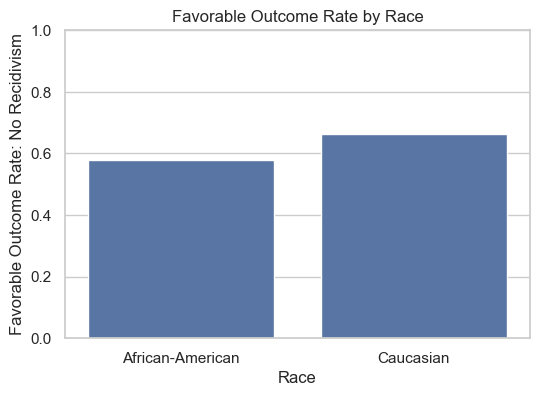

In [136]:
# Plot favorable outcome rate by race

plt.figure(figsize=(6, 4))
sns.barplot(
    x=favorable_rate_by_race.index,
    y=favorable_rate_by_race.values
)

plt.title("Favorable Outcome Rate by Race")
plt.xlabel("Race")
plt.ylabel("Favorable Outcome Rate: No Recidivism")
plt.ylim(0, 1)
plt.show()

This plot shows the rate of favorable outcomes for each racial group.

If one group has a much lower favorable outcome rate, this suggests dataset imbalance or historical/social bias in the observed outcomes.

## 8.5 Manual Verification of AIF360 Metrics

To better understand AIF360 results, we manually calculate Statistical Parity Difference and Disparate Impact.

This helps us verify what AIF360 is doing.

In [137]:
# Calculate favorable outcome rate for African-American defendants

aa_favorable_rate = df_clean[
    df_clean['race'] == 'African-American'
]['is_recid'].eq(0).mean()

# Calculate favorable outcome rate for Caucasian defendants

caucasian_favorable_rate = df_clean[
    df_clean['race'] == 'Caucasian'
]['is_recid'].eq(0).mean()

# Manual Statistical Parity Difference
# Formula:
# favorable rate of unprivileged group - favorable rate of privileged group

manual_spd = aa_favorable_rate - caucasian_favorable_rate

# Manual Disparate Impact
# Formula:
# favorable rate of unprivileged group / favorable rate of privileged group

manual_di = aa_favorable_rate / caucasian_favorable_rate

print("Manual Fairness Calculations")
print("-----------------------------")
print("African-American favorable rate:", round(aa_favorable_rate, 4))
print("Caucasian favorable rate       :", round(caucasian_favorable_rate, 4))
print("Manual Statistical Parity Difference:", round(manual_spd, 4))
print("Manual Disparate Impact:", round(manual_di, 4))

Manual Fairness Calculations
-----------------------------
African-American favorable rate: 0.5788
Caucasian favorable rate       : 0.6646
Manual Statistical Parity Difference: -0.0857
Manual Disparate Impact: 0.871


The manual results should match or be very close to the AIF360 results.

This confirms that AIF360 is comparing favorable outcome rates between the unprivileged and privileged groups.

In [138]:
# Create summary table for dataset fairness analysis

dataset_fairness_summary = pd.DataFrame({
    'Metric': [
        'Mean Difference',
        'Statistical Parity Difference',
        'Disparate Impact',
        'African-American Favorable Rate',
        'Caucasian Favorable Rate'
    ],
    'Value': [
        mean_difference,
        statistical_parity_difference,
        disparate_impact,
        aa_favorable_rate,
        caucasian_favorable_rate
    ]
})

dataset_fairness_summary

,Metric,Value
0,Mean Difference,-0.085745
1,Statistical Parity Difference,-0.085745
2,Disparate Impact,0.870978
3,African-American Favorable Rate,0.578828
4,Caucasian Favorable Rate,0.664572


In [139]:
# Save dataset fairness summary

dataset_fairness_summary.to_csv("dataset_fairness_summary_aif360.csv", index=False)

print("Dataset fairness summary saved successfully.")

Dataset fairness summary saved successfully.


This table summarizes the dataset-level fairness metrics.

It will be useful later when comparing:

1. Original dataset fairness
2. COMPAS baseline fairness
3. Machine learning model fairness
4. Fairness after bias mitigation

In [140]:
# Create dataframe for plotting only SPD and Disparate Impact

fairness_metrics_plot = pd.DataFrame({
    'Metric': ['Statistical Parity Difference', 'Disparate Impact'],
    'Value': [statistical_parity_difference, disparate_impact]
})

fairness_metrics_plot

,Metric,Value
0,Statistical Parity Difference,-0.085745
1,Disparate Impact,0.870978


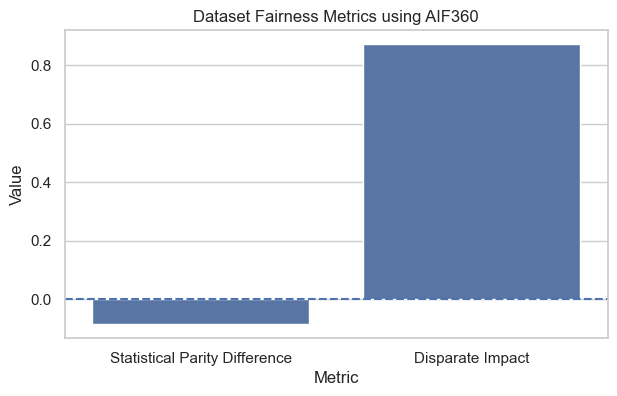

In [141]:
# Plot dataset fairness metrics

plt.figure(figsize=(7, 4))
sns.barplot(data=fairness_metrics_plot, x='Metric', y='Value')
plt.title("Dataset Fairness Metrics using AIF360")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.axhline(0, linestyle='--')
plt.show()

For Statistical Parity Difference, the ideal value is 0.

For Disparate Impact, the ideal value is 1.

Because these two metrics have different ideal values, they should be interpreted carefully.

## 8.6 Interpretation of Dataset Fairness Results

The dataset fairness analysis shows whether the actual outcomes are distributed differently between African-American and Caucasian defendants.

If Statistical Parity Difference is negative, it means African-American defendants have a lower favorable outcome rate than Caucasian defendants.

If Disparate Impact is below 1, it also means African-American defendants have a lower favorable outcome rate than Caucasian defendants.

However, this does not automatically prove that the machine learning model is biased. It shows that the dataset itself contains group differences in observed outcomes.

Later, we will check whether machine learning models increase, reduce, or reproduce these differences.

# 8.7 Dataset Fairness Analysis Summary

In this section, AIF360 was used to analyze dataset-level fairness.

The following steps were completed:

1. AIF360 was installed and imported.
2. The cleaned COMPAS dataset was loaded.
3. The protected attribute `race_binary` was defined.
4. African-American defendants were defined as the unprivileged group.
5. Caucasian defendants were defined as the privileged group.
6. The favorable label was defined as `is_recid = 0`.
7. The unfavorable label was defined as `is_recid = 1`.
8. The dataset was converted into an AIF360 `BinaryLabelDataset`.
9. Dataset-level fairness metrics were calculated.
10. Statistical Parity Difference and Disparate Impact were manually verified.
11. A dataset fairness summary table was saved.

This section shows whether the original dataset contains group-level differences before training machine learning models.

In this part of the project, we first explained the main fairness metrics used in fair machine learning. These include Statistical Parity Difference, Disparate Impact, False Positive Rate Difference, False Negative Rate Difference, Equal Opportunity Difference, and Average Odds Difference.

Then we used AIF360 to perform dataset-level fairness analysis. we converted the cleaned COMPAS dataset into an AIF360 BinaryLabelDataset. The protected attribute was race, represented by race_binary. African-American defendants were treated as the unprivileged group and Caucasian defendants as the privileged group.

For this project, the favorable outcome was defined as no recidivism, so `is_recid = 0` was the favorable label. The unfavorable outcome was recidivism, so `is_recid = 1` was the unfavorable label.

we then calculated Statistical Parity Difference and Disparate Impact using AIF360 and verified these results manually using pandas. This helped me understand whether the dataset itself already contains group-level differences before training machine learning models.

# 9. Feature Engineering and Train-Test Split

In this section, we prepare the cleaned and encoded dataset for machine learning.

Feature engineering means preparing the input variables in a suitable format for model training.

The main goals of this section are:

1. Load the encoded dataset created during preprocessing.
2. Separate features and target variable.
3. Keep the protected attribute separately for fairness evaluation.
4. Remove sensitive or unnecessary columns from model input if required.
5. Split the dataset into training and testing sets.
6. Scale numerical features where needed.

The target variable is:

`is_recid`

The protected attribute for fairness analysis is:

`race_binary`

In [142]:
# Import basic libraries

import pandas as pd
import numpy as np

# Import train-test split function
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

We import the required libraries for feature engineering and train-test splitting.

- `train_test_split` is used to divide the data into training and testing datasets.
- `StandardScaler` is used to scale numerical features so that they have similar ranges.

In [143]:
# Load the encoded dataset created in Section 4

df_model_encoded = pd.read_csv("compas_model_encoded.csv")

# Display first few rows
df_model_encoded.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
0,34,0,0,0,0,1,0,1,2,True,False
1,24,0,0,1,4,1,0,0,2,True,False
2,23,0,1,0,1,0,0,0,2,True,False
3,41,0,0,0,14,1,1,1,2,True,True
4,39,0,0,0,0,0,1,1,1,False,True


In [144]:
# Check important engineered columns after updated preprocessing

important_engineered_columns = [
    'age_cat_ordinal',
    'c_charge_degree_ordinal',
    'race_binary'
]

for col in important_engineered_columns:
    print(col, "exists:", col in df_model_encoded.columns)

age_cat_ordinal exists: True
c_charge_degree_ordinal exists: True
race_binary exists: True


In [145]:
# Display final columns used for modeling

df_model_encoded.columns

Index(['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'is_recid', 'race_binary', 'age_cat_ordinal',
       'c_charge_degree_ordinal', 'sex_Male', 'race_Caucasian'],
      dtype='object')

In [146]:
# Check dataset shape

print("Rows:", df_model_encoded.shape[0])
print("Columns:", df_model_encoded.shape[1])

Rows: 7267
Columns: 11


The encoded dataset contains numerical columns only.

This dataset is ready for machine learning because categorical variables were already converted using one-hot encoding in the preprocessing section.

## 9.1 Define Features, Target, and Protected Attribute

For machine learning, we need to separate the dataset into:

- `X`: input features
- `y`: target variable
- `protected_attribute`: race information used for fairness evaluation

The target variable is:

`is_recid`

The protected attribute is:

`race_binary`

Important:

`race_binary` is needed later for fairness evaluation. For the first model version, we will keep it in the feature set. Later, we can test whether removing race improves fairness.

In [147]:
# Define target variable

y = df_model_encoded['is_recid']

# Define protected attribute for fairness evaluation

protected_attribute = df_model_encoded['race_binary']

# Define feature matrix
# Here we remove only the target variable.
# race_binary is kept as a feature in this first experiment.

X = df_model_encoded.drop(columns=['is_recid'])

# Check shapes

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Protected attribute shape:", protected_attribute.shape)

X shape: (7267, 10)
y shape: (7267,)
Protected attribute shape: (7267,)


At this stage:

- `X` contains all input features.
- `y` contains the target variable.
- `protected_attribute` contains the race group used for fairness evaluation.

Keeping `race_binary` in the model allows us to observe how the model behaves when the protected attribute is included.

Later, we can compare this with a model where `race_binary` is removed.

## 9.2 Train-Test Split

The dataset is divided into:

- Training set: used to train the model
- Testing set: used to evaluate the model on unseen data

We use an 80/20 split:

- 80% training data
- 20% testing data

We also use stratification based on the target variable so that the class distribution remains similar in both training and testing sets.

In [148]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X,
    y,
    protected_attribute,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print shapes

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("protected_train shape:", protected_train.shape)
print("protected_test shape :", protected_test.shape)

X_train shape: (5813, 10)
X_test shape : (1454, 10)
y_train shape: (5813,)
y_test shape : (1454,)
protected_train shape: (5813,)
protected_test shape : (1454,)


The data has now been split into training and testing sets.

The training data will be used to train the machine learning models.

The testing data will be used only for final evaluation.

In [149]:
# Check target distribution in full dataset

print("Full dataset target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting set target distribution:")
print(y_test.value_counts(normalize=True))

Full dataset target distribution:
is_recid
0    0.612632
1    0.387368
Name: proportion, dtype: float64

Training set target distribution:
is_recid
0    0.612592
1    0.387408
Name: proportion, dtype: float64

Testing set target distribution:
is_recid
0    0.612792
1    0.387208
Name: proportion, dtype: float64


The target distribution is checked in the full dataset, training set, and testing set.

Because we used `stratify=y`, the proportion of recidivism and no recidivism should be similar in both training and testing datasets.

In [150]:
# Check protected attribute distribution

print("Full dataset race_binary distribution:")
print(protected_attribute.value_counts(normalize=True))

print("\nTraining set race_binary distribution:")
print(protected_train.value_counts(normalize=True))

print("\nTesting set race_binary distribution:")
print(protected_test.value_counts(normalize=True))

Full dataset race_binary distribution:
race_binary
0    0.605752
1    0.394248
Name: proportion, dtype: float64

Training set race_binary distribution:
race_binary
0    0.604335
1    0.395665
Name: proportion, dtype: float64

Testing set race_binary distribution:
race_binary
0    0.611417
1    0.388583
Name: proportion, dtype: float64


The protected attribute distribution is also checked in the training and testing sets.

This helps confirm that both racial groups are represented in the model evaluation data.

## 9.3 Feature Scaling

Some machine learning models are sensitive to feature scale.

For example:

- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbors

Tree-based models such as Decision Tree and Random Forest usually do not require scaling.

However, to keep the workflow consistent, we create scaled versions of the training and testing feature sets.

Important:

The scaler is fitted only on the training data.  
Then the same scaler is applied to the test data.

This avoids data leakage.

In [151]:
# Create StandardScaler object

scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to dataframes for easier interpretation

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Display first rows of scaled training data

X_train_scaled.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
5414,-1.178191,-0.170011,-0.20434,-0.246973,-0.789329,1.235877,-1.574110,0.682556,0.528193,1.235877
4319,-0.337638,-0.170011,-0.20434,-0.246973,-0.206753,-0.809142,-0.028712,0.682556,0.528193,-0.809142
823,-0.757915,-0.170011,-0.20434,-0.246973,1.152592,-0.809142,-0.028712,-1.431295,0.528193,-0.809142
3659,-1.010081,-0.170011,-0.20434,-0.246973,-0.595137,1.235877,-1.574110,-1.431295,-1.893247,1.235877
1712,-0.169528,-0.170011,-0.20434,-0.246973,0.181631,-0.809142,-0.028712,-1.431295,-1.893247,-0.809142


The scaled feature datasets have been created:

- `X_train_scaled`
- `X_test_scaled`

These will be used for models that benefit from scaling, especially Logistic Regression and SVM.

For Decision Tree and Random Forest, we can use the original unscaled features.

## 9.4 Create Helper Function for Model Evaluation

To avoid repeating the same code for every model, we create a helper function.

This function calculates:

1. Accuracy
2. Precision
3. Recall
4. F1-score
5. ROC-AUC
6. Confusion matrix

This function will be reused for all models in the project.

In [152]:
# Import classification evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [153]:
# Define a reusable model evaluation function

def evaluate_classification_model(model_name, y_true, y_pred, y_prob=None):
    """
    This function evaluates a binary classification model.
    
    Parameters:
    model_name: name of the model as a string
    y_true: actual target values
    y_pred: predicted class labels
    y_prob: predicted probabilities for class 1, optional
    
    Returns:
    A dictionary containing performance metrics.
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC can be calculated using probabilities if available.
    # If probabilities are not available, we use predicted labels.
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }
    
    return results

In [154]:
# Define function to plot confusion matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    This function plots a confusion matrix for a classification model.
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted No Recidivism', 'Predicted Recidivism'],
        yticklabels=['Actual No Recidivism', 'Actual Recidivism']
    )
    
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

The helper functions are now ready.

They will help us evaluate all models in the same way and make model comparison easier.

# 10. Model 1: Logistic Regression

Logistic Regression is a simple and interpretable classification model.

Although it has the word "regression" in its name, Logistic Regression is used for classification problems.

In this project, Logistic Regression predicts whether a defendant will reoffend or not.

Advantages:

1. Simple and fast
2. Easy to interpret
3. Good baseline model
4. Works well with scaled numerical features

Limitations:

1. Assumes a linear relationship between features and log-odds
2. May not capture complex patterns as well as tree-based models

In [155]:
# Import Logistic Regression model

from sklearn.linear_model import LogisticRegression

## 10.1 Train Logistic Regression Model

Logistic Regression performs better when features are scaled.

Therefore, we train it using:

`X_train_scaled`

The target variable is:

`y_train`

In [156]:
# Create Logistic Regression model

log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using scaled training data

log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [157]:
# Predict class labels on test data

y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Predict probabilities for class 1
# Probability is useful for ROC-AUC and threshold adjustment later.

y_prob_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Display first 10 predictions

print("First 10 predicted classes:")
print(y_pred_log_reg[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_log_reg[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.10894242 0.55165113 0.24256903 0.46191703 0.35695158 0.30811086
 0.34267248 0.32915416 0.2495322  0.40561771]


The model outputs:

1. Predicted classes: 0 or 1
2. Predicted probabilities: probability that the person belongs to class 1, meaning recidivism

By default, the model predicts class 1 when the probability is greater than or equal to 0.5.

In [158]:
# Evaluate Logistic Regression model

log_reg_results = evaluate_classification_model(
    model_name='Logistic Regression',
    y_true=y_test,
    y_pred=y_pred_log_reg,
    y_prob=y_prob_log_reg
)

log_reg_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.655433287482806,
 'Precision': 0.6107142857142858,
 'Recall': 0.3037300177619893,
 'F1-score': 0.40569395017793597,
 'ROC-AUC': 0.6802134229606106}

In [159]:
# Display classification report

print("Classification Report: Logistic Regression")
print("------------------------------------------")
print(classification_report(y_test, y_pred_log_reg))

Classification Report: Logistic Regression
------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       891
           1       0.61      0.30      0.41       563

    accuracy                           0.66      1454
   macro avg       0.64      0.59      0.58      1454
weighted avg       0.64      0.66      0.62      1454



The classification report shows performance for both classes:

- Class 0: No recidivism
- Class 1: Recidivism

The main metrics are:

- Precision
- Recall
- F1-score
- Accuracy

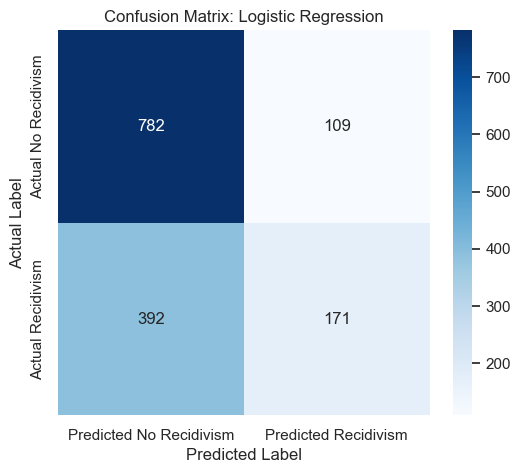

In [160]:
# Plot confusion matrix for Logistic Regression

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_log_reg,
    model_name='Logistic Regression'
)

The confusion matrix shows how many predictions were correct and incorrect.

Important error types:

- False Positive: predicted recidivism but actual no recidivism.
- False Negative: predicted no recidivism but actual recidivism.

These errors will later be compared across racial groups for fairness analysis.

## 10.2 Interpret Logistic Regression Coefficients

One advantage of Logistic Regression is that we can inspect its coefficients.

A positive coefficient means the feature increases the probability of predicting recidivism.

A negative coefficient means the feature decreases the probability of predicting recidivism.

This helps us understand which features are important for the model.

In [161]:
# Create dataframe of Logistic Regression coefficients

log_reg_coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Add absolute coefficient value for sorting

log_reg_coefficients['Absolute Coefficient'] = log_reg_coefficients['Coefficient'].abs()

# Sort by absolute importance

log_reg_coefficients = log_reg_coefficients.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

log_reg_coefficients

,Feature,Coefficient,Absolute Coefficient
4,priors_count,0.461613,0.461613
0,age,-0.457835,0.457835
8,sex_Male,0.146772,0.146772
3,juv_other_count,0.107606,0.107606
6,age_cat_ordinal,0.047225,0.047225
1,juv_fel_count,0.031242,0.031242
5,race_binary,-0.021174,0.021174
9,race_Caucasian,-0.021174,0.021174
2,juv_misd_count,-0.018826,0.018826
7,c_charge_degree_ordinal,0.010319,0.010319


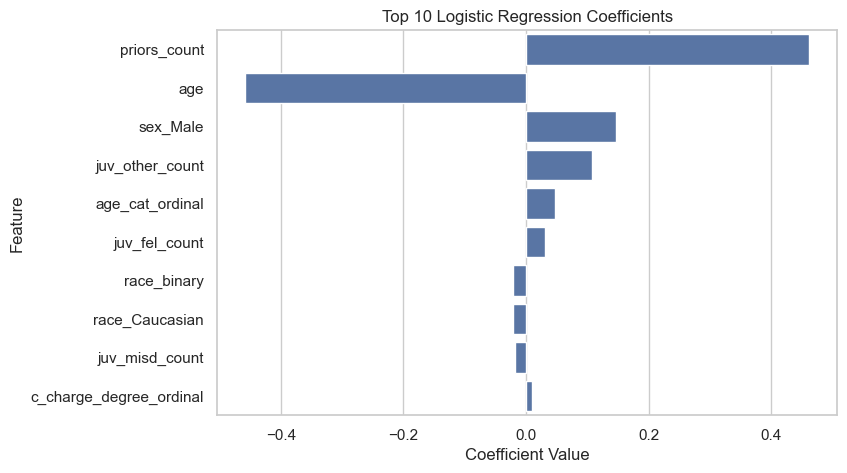

In [162]:
# Plot top 10 most important coefficients

top_10_coefficients = log_reg_coefficients.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_10_coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

The coefficient plot shows which features have the strongest influence in the Logistic Regression model.

Features with large positive coefficients increase the predicted probability of recidivism.

Features with large negative coefficients decrease the predicted probability of recidivism.

# 11. Model 2: Decision Tree

A Decision Tree is a supervised machine learning model that makes predictions by splitting the data into branches based on feature values.

It works like a flowchart.

Advantages:

1. Easy to understand
2. Can capture non-linear relationships
3. Does not require feature scaling
4. Can handle different types of features after encoding

Limitations:

1. Can overfit the training data
2. Small changes in data can change the tree structure
3. May not generalize as well as ensemble models like Random Forest

For this model, we use the unscaled training data because Decision Trees do not require scaling.

In [163]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

## 11.1 Train Decision Tree Model

Decision Trees do not require scaled features.

Therefore, we train the model using:

`X_train`

instead of:

`X_train_scaled`

In [164]:
# Create Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


The parameter `max_depth=5` limits how deep the tree can grow.

This helps reduce overfitting.

If we allow the tree to grow too deep, it may memorize the training data instead of learning general patterns.

In [165]:
# Predict class labels on test data

y_pred_tree = decision_tree_model.predict(X_test)

# Predict probabilities for class 1

y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Display first 10 predictions

print("First 10 predicted classes:")
print(y_pred_tree[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_tree[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.20491803 0.70103093 0.20933735 0.45762712 0.31400966 0.2826087
 0.22093023 0.45748988 0.20933735 0.44731183]


The Decision Tree model produces predicted classes and predicted probabilities.

The probabilities are useful for ROC-AUC and threshold adjustment later.

In [166]:
# Evaluate Decision Tree model

decision_tree_results = evaluate_classification_model(
    model_name='Decision Tree',
    y_true=y_test,
    y_pred=y_pred_tree,
    y_prob=y_prob_tree
)

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.6519944979367263,
 'Precision': 0.5959595959595959,
 'Recall': 0.31438721136767317,
 'F1-score': 0.4116279069767442,
 'ROC-AUC': 0.6696927833695153}

In [167]:
# Display classification report

print("Classification Report: Decision Tree")
print("------------------------------------")
print(classification_report(y_test, y_pred_tree))

Classification Report: Decision Tree
------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.87      0.75       891
           1       0.60      0.31      0.41       563

    accuracy                           0.65      1454
   macro avg       0.63      0.59      0.58      1454
weighted avg       0.64      0.65      0.62      1454



The performance metrics show how well the Decision Tree predicts recidivism on the test dataset.

Later, these results will be compared with other models.

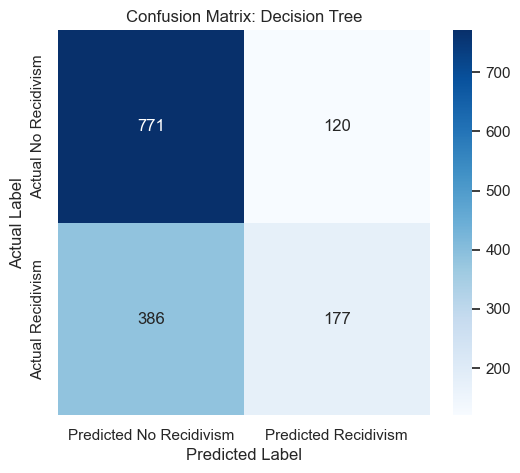

In [168]:
# Plot confusion matrix for Decision Tree

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_tree,
    model_name='Decision Tree'
)

The confusion matrix helps us understand the number of true positives, false positives, true negatives, and false negatives.

This will also be important later when we calculate fairness metrics.

## 11.2 Feature Importance for Decision Tree

Decision Trees provide feature importance values.

A higher feature importance means that the feature was more useful for splitting the data and making predictions.

In [169]:
# Create dataframe of feature importances

tree_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': decision_tree_model.feature_importances_
})

# Sort by importance

tree_feature_importance = tree_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

tree_feature_importance

,Feature,Importance
4,priors_count,0.514623
0,age,0.368009
2,juv_misd_count,0.045366
8,sex_Male,0.034814
3,juv_other_count,0.025455
6,age_cat_ordinal,0.006978
5,race_binary,0.004754
1,juv_fel_count,0.000000
7,c_charge_degree_ordinal,0.000000
9,race_Caucasian,0.000000


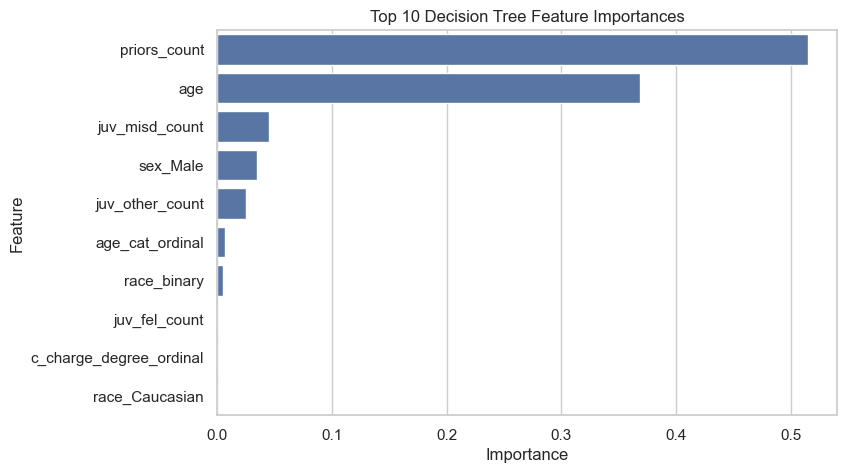

In [170]:
# Plot top 10 feature importances

top_10_tree_features = tree_feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_10_tree_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows which features were most important for the Decision Tree model.

This helps us understand what information the model used most strongly to predict recidivism.

## 11.3 Visualize the Decision Tree

A Decision Tree can be visualized to understand the decision rules used by the model.

Because large trees are difficult to read, we visualize only the first few levels.

In [171]:
# Import plot_tree function

from sklearn.tree import plot_tree

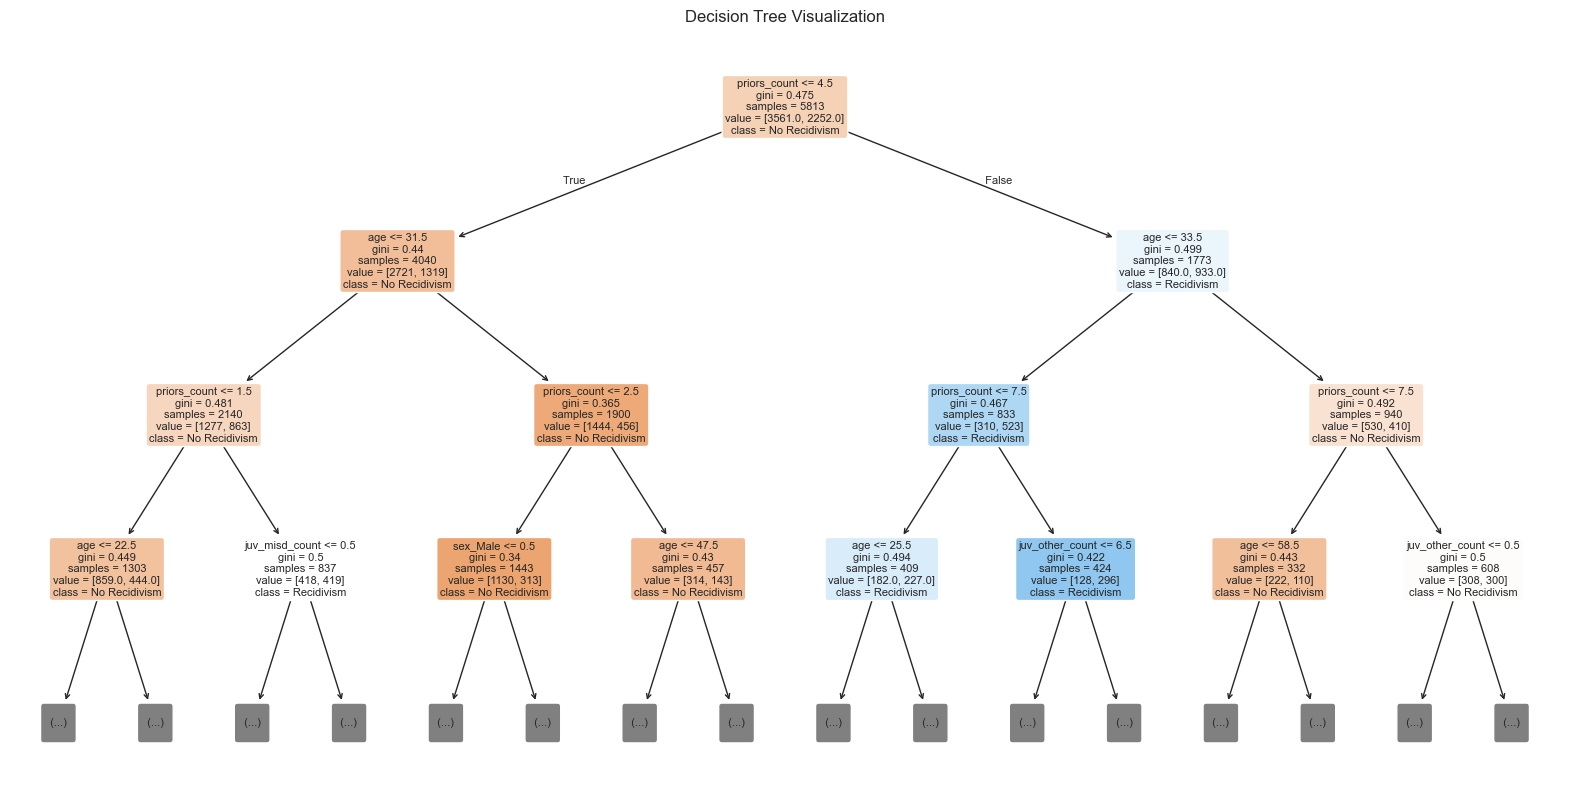

In [172]:
# Plot the decision tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X_train.columns,
    class_names=['No Recidivism', 'Recidivism'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

The decision tree visualization shows the rules learned by the model.

Each node represents a decision based on a feature.

The tree splits the data step by step until it reaches final prediction nodes.

## 11.4 Save Model Results So Far

We save the results of Logistic Regression and Decision Tree in a dataframe.

Later, we will add Random Forest, Gradient Boosting, and Support Vector Machine results to the same comparison table.

In [173]:
# Create model results dataframe

model_results = pd.DataFrame([
    log_reg_results,
    decision_tree_results
])

# Display model results

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693


In [174]:
# Save current model results

model_results.to_csv("model_results_initial.csv", index=False)

print("Initial model results saved successfully.")

Initial model results saved successfully.


In Section 9, I prepared the data for machine learning. I loaded the encoded dataset, separated the target variable `is_recid`, the input features `X`, and the protected attribute `race_binary`. Then I split the data into training and testing sets using an 80/20 split with stratification to preserve the class distribution. I also scaled the features using StandardScaler, which is important for models like Logistic Regression and SVM.

In Section 10, I trained the first model, Logistic Regression. This model was used as a simple and interpretable baseline. I trained it using scaled features, made predictions on the test set, and evaluated it using accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix. I also inspected the model coefficients to understand which features had the strongest influence.

In Section 11, I trained a Decision Tree classifier. Since Decision Trees do not require feature scaling, I used the original unscaled features. I limited the tree depth to reduce overfitting. After training, I evaluated the model using the same metrics and plotted the confusion matrix. I also checked feature importance and visualized part of the decision tree to understand its prediction rules.

# 12. Model 3: Random Forest

Random Forest is an ensemble machine learning model.

An ensemble model combines multiple models to make a stronger final model. Random Forest builds many Decision Trees and combines their predictions.

Instead of relying on one tree, Random Forest uses many trees and takes the majority vote for classification.

Advantages of Random Forest:

1. Usually performs better than a single Decision Tree.
2. Reduces overfitting compared with a single tree.
3. Can capture non-linear relationships.
4. Provides feature importance values.
5. Does not require feature scaling.

Limitations of Random Forest:

1. Less interpretable than a single Decision Tree.
2. Can be slower than simple models.
3. Fairness still needs to be checked separately.

In [175]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

## 12.1 Train Random Forest Model

Random Forest does not require scaled features.

Therefore, we train this model using:

`X_train`

instead of:

`X_train_scaled`

We use:

- `n_estimators=100`: the forest will contain 100 decision trees.
- `max_depth=8`: limits tree depth to reduce overfitting.
- `random_state=42`: makes results reproducible.

In [176]:
# Create Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train the model

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [177]:
# Predict class labels on test data

y_pred_rf = random_forest_model.predict(X_test)

# Predict probabilities for class 1

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Display first 10 predictions

print("First 10 predicted classes:")
print(y_pred_rf[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_rf[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.22431236 0.61626873 0.21429206 0.43954745 0.30871196 0.29041736
 0.25395806 0.38245366 0.23399692 0.39550969]


The Random Forest model produces both predicted classes and predicted probabilities.

The predicted probabilities will be useful later for ROC-AUC and threshold adjustment.

In [178]:
# Evaluate Random Forest model

random_forest_results = evaluate_classification_model(
    model_name='Random Forest',
    y_true=y_test,
    y_pred=y_pred_rf,
    y_prob=y_prob_rf
)

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.6430536451169189,
 'Precision': 0.5662650602409639,
 'Recall': 0.3339253996447602,
 'F1-score': 0.4201117318435754,
 'ROC-AUC': 0.6689322672152749}

In [179]:
# Display classification report

print("Classification Report: Random Forest")
print("------------------------------------")
print(classification_report(y_test, y_pred_rf))

Classification Report: Random Forest
------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.84      0.74       891
           1       0.57      0.33      0.42       563

    accuracy                           0.64      1454
   macro avg       0.62      0.59      0.58      1454
weighted avg       0.63      0.64      0.62      1454



The classification report shows the model performance for both classes:

- Class 0: No recidivism
- Class 1: Recidivism

Later, Random Forest will be compared with all other models using the same metrics.

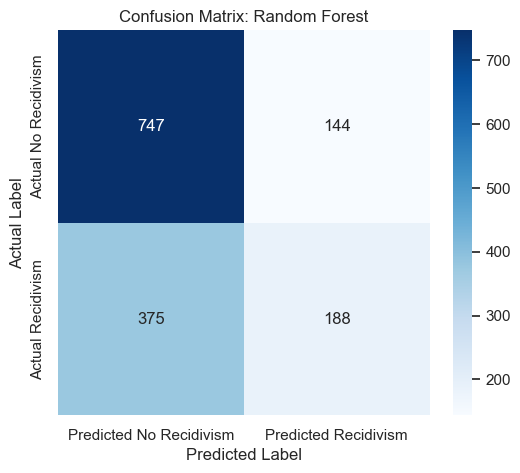

In [180]:
# Plot confusion matrix for Random Forest

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_rf,
    model_name='Random Forest'
)

The confusion matrix shows correct and incorrect predictions.

This will also be useful later when fairness-related error rates are calculated by race.

## 12.2 Feature Importance for Random Forest

Random Forest provides feature importance values.

These values show which features contributed most to the model predictions.

In [181]:
# Create dataframe of Random Forest feature importances

rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest_model.feature_importances_
})

# Sort features by importance

rf_feature_importance = rf_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_feature_importance

,Feature,Importance
4,priors_count,0.376563
0,age,0.272260
3,juv_other_count,0.078910
2,juv_misd_count,0.058919
8,sex_Male,0.046992
6,age_cat_ordinal,0.046949
1,juv_fel_count,0.037053
7,c_charge_degree_ordinal,0.035600
9,race_Caucasian,0.025075
5,race_binary,0.021680


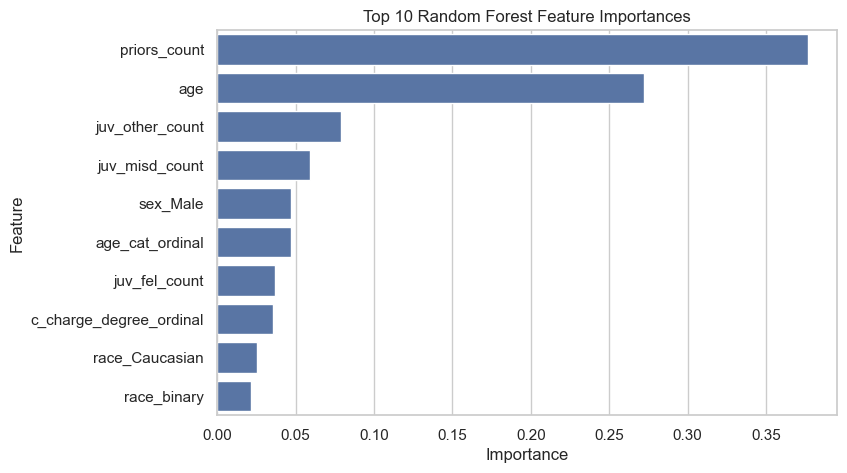

In [182]:
# Plot top 10 Random Forest feature importances

top_10_rf_features = rf_feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_10_rf_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

 The feature importance plot helps us understand which variables were most important for the Random Forest model.

However, feature importance does not automatically explain fairness. A model can use variables that are correlated with race even if race itself is not the most important feature.

# 13 Model 4: Gradient Boosting

Gradient Boosting is another ensemble machine learning model.

Unlike Random Forest, which builds many trees independently, Gradient Boosting builds trees sequentially. Each new tree tries to correct the errors made by the previous trees.

Advantages of Gradient Boosting:

1. Often gives strong predictive performance.
2. Can capture complex non-linear relationships.
3. Works well with tabular data.
4. Does not require feature scaling.

Limitations of Gradient Boosting:

1. Can overfit if not tuned carefully.
2. Training can be slower than simpler models.
3. Less interpretable than Logistic Regression or a small Decision Tree.
4. Fairness must still be evaluated separately.

In [183]:
# Import Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

## 13.1 Train Gradient Boosting Model

Gradient Boosting does not require scaled features.

Therefore, we train this model using:

`X_train`

We use moderate parameter values to reduce overfitting:

- `n_estimators=100`
- `learning_rate=0.05`
- `max_depth=3`

In [184]:
# Create Gradient Boosting model

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [185]:
# Predict class labels on test data

y_pred_gb = gradient_boosting_model.predict(X_test)

# Predict probabilities for class 1

y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Display first 10 predictions

print("First 10 predicted classes:")
print(y_pred_gb[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_gb[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.15547015 0.5878319  0.23970048 0.48460943 0.33169879 0.26681615
 0.26732279 0.4025065  0.23970048 0.42751635]


The Gradient Boosting model gives predicted classes and predicted probabilities.

The probabilities will be used later for ROC-AUC and threshold adjustment.

In [186]:
# Evaluate Gradient Boosting model

gradient_boosting_results = evaluate_classification_model(
    model_name='Gradient Boosting',
    y_true=y_test,
    y_pred=y_pred_gb,
    y_prob=y_prob_gb
)

gradient_boosting_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.6499312242090785,
 'Precision': 0.5771428571428572,
 'Recall': 0.35879218472468916,
 'F1-score': 0.4424972617743702,
 'ROC-AUC': 0.6759383852338263}

In [187]:
# Display classification report

print("Classification Report: Gradient Boosting")
print("----------------------------------------")
print(classification_report(y_test, y_pred_gb))

Classification Report: Gradient Boosting
----------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.83      0.74       891
           1       0.58      0.36      0.44       563

    accuracy                           0.65      1454
   macro avg       0.63      0.60      0.59      1454
weighted avg       0.64      0.65      0.63      1454



The performance metrics show how well Gradient Boosting predicts recidivism.

This model may perform better than a single Decision Tree because it combines multiple weak learners sequentially.

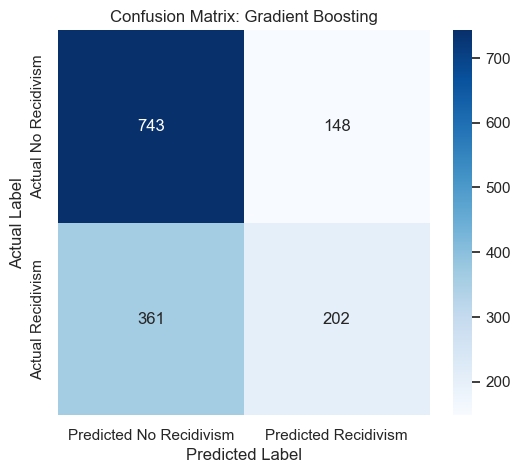

In [188]:
# Plot confusion matrix for Gradient Boosting

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_gb,
    model_name='Gradient Boosting'
)

The confusion matrix shows the number of true negatives, false positives, false negatives, and true positives.

These values are important for both performance and fairness analysis.

## 13.2 Feature Importance for Gradient Boosting

Gradient Boosting also provides feature importance values.

These values indicate which features were most useful for the model.

In [189]:
# Create dataframe of Gradient Boosting feature importances

gb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gradient_boosting_model.feature_importances_
})

# Sort features by importance

gb_feature_importance = gb_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

gb_feature_importance

,Feature,Importance
4,priors_count,0.478770
0,age,0.340759
3,juv_other_count,0.063538
2,juv_misd_count,0.036057
8,sex_Male,0.031373
1,juv_fel_count,0.015529
9,race_Caucasian,0.015469
5,race_binary,0.009654
7,c_charge_degree_ordinal,0.006900
6,age_cat_ordinal,0.001951


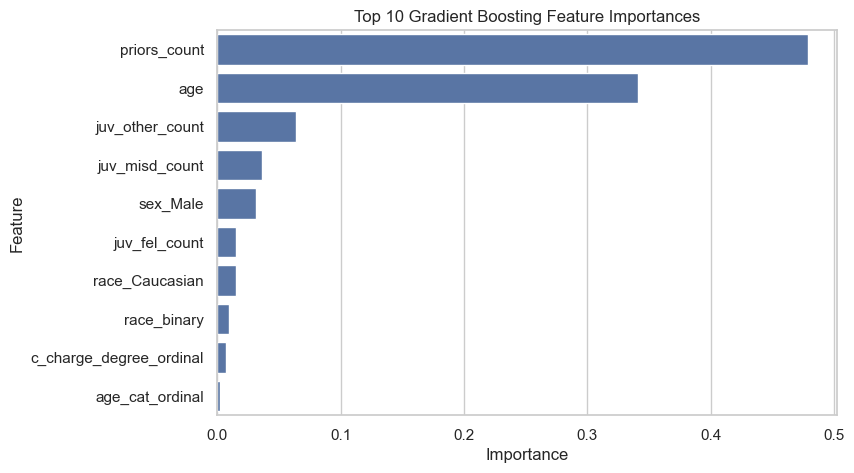

In [190]:
# Plot top 10 Gradient Boosting feature importances

top_10_gb_features = gb_feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_10_gb_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows which variables influenced the Gradient Boosting model most strongly.

As with Random Forest, this does not automatically prove fairness. Fairness must be evaluated using group-based metrics.

# 14. Model 5: Support Vector Machine

Support Vector Machine, or SVM, is a supervised machine learning model used for classification.

SVM tries to find the best decision boundary that separates classes.

For this project, the classes are:

- No recidivism
- Recidivism

Advantages of SVM:

1. Can work well for classification problems.
2. Can handle complex decision boundaries using kernels.
3. Often performs well with scaled data.

Limitations of SVM:

1. Can be slower on larger datasets.
2. Less interpretable than Logistic Regression.
3. Requires feature scaling.
4. Probability estimates may increase training time.

In [191]:
# Import Support Vector Classifier

from sklearn.svm import SVC

## 14.1 Train SVM Model

SVM is sensitive to feature scales.

Therefore, we train SVM using:

`X_train_scaled`

instead of:

`X_train`

We use the RBF kernel because it can capture non-linear relationships.

We set `probability=True` so that we can calculate ROC-AUC using predicted probabilities.

In [192]:
# Create SVM model

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# Train the model using scaled training data

svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.


In [193]:
# Predict class labels on test data

y_pred_svm = svm_model.predict(X_test_scaled)

# Predict probabilities for class 1

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Display first 10 predictions

print("First 10 predicted classes:")
print(y_pred_svm[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_svm[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.31309998 0.55718036 0.3140826  0.40435227 0.32174616 0.31063286
 0.31662816 0.30828005 0.31094314 0.33058779]


The SVM model produces class predictions and probability estimates.

The probability estimates are useful for ROC-AUC, but they make SVM training slower.

In [194]:
# Evaluate SVM model

svm_results = evaluate_classification_model(
    model_name='Support Vector Machine',
    y_true=y_test,
    y_pred=y_pred_svm,
    y_prob=y_prob_svm
)

svm_results

{'Model': 'Support Vector Machine',
 'Accuracy': 0.6341127922971114,
 'Precision': 0.5551601423487544,
 'Recall': 0.27708703374777977,
 'F1-score': 0.3696682464454976,
 'ROC-AUC': 0.6423829771964763}

In [195]:
# Display classification report

print("Classification Report: Support Vector Machine")
print("---------------------------------------------")
print(classification_report(y_test, y_pred_svm))

Classification Report: Support Vector Machine
---------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.86      0.74       891
           1       0.56      0.28      0.37       563

    accuracy                           0.63      1454
   macro avg       0.60      0.57      0.56      1454
weighted avg       0.62      0.63      0.60      1454



The classification report shows the precision, recall, and F1-score for both classes.

SVM results will later be compared with Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

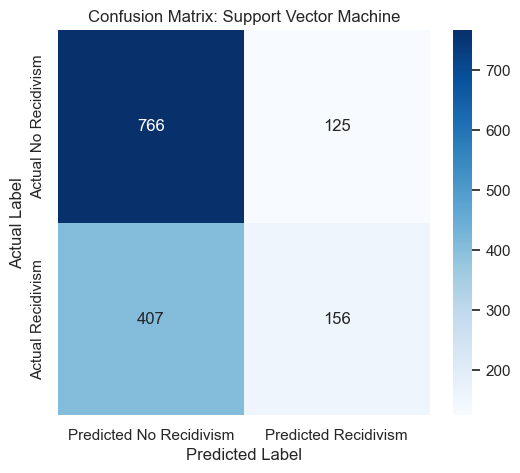

In [196]:
# Plot confusion matrix for SVM

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_svm,
    model_name='Support Vector Machine'
)

## 14.2 SVM Feature Importance Note

Unlike Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting, the RBF-kernel SVM does not provide simple feature importance values.

This is because the model uses a non-linear kernel transformation.

Therefore, we do not plot feature importance for SVM in this project.

If interpretability is important, Logistic Regression or tree-based feature importance is easier to explain.

## 14.3 Add All Model Results to One Table

Now we combine the results from all five models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

This table will be used in the next section for model performance comparison.

In [197]:
# Combine all model results into one dataframe

model_results = pd.DataFrame([
    log_reg_results,
    decision_tree_results,
    random_forest_results,
    gradient_boosting_results,
    svm_results
])

# Display results

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383


In [198]:
# Sort models by accuracy

model_results_sorted_accuracy = model_results.sort_values(
    by='Accuracy',
    ascending=False
)

model_results_sorted_accuracy

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383


In [199]:
# Sort models by F1-score

model_results_sorted_f1 = model_results.sort_values(
    by='F1-score',
    ascending=False
)

model_results_sorted_f1

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383


In [200]:
# Save all model results for later use

model_results.to_csv("model_results_all_5_models.csv", index=False)

print("All five model results saved successfully.")

All five model results saved successfully.


## 14.4 Save Model Predictions for Fairness Evaluation

Later, we will calculate fairness metrics for each model.

For fairness evaluation, we need:

- Actual labels
- Predicted labels
- Protected attribute
- Model prediction probabilities

Therefore, we save all predictions in one dataframe.

In [201]:
# Create dataframe with actual labels, protected attribute, and predictions

model_predictions = pd.DataFrame({
    'y_true': y_test,
    'race_binary': protected_test,
    'logistic_regression_pred': y_pred_log_reg,
    'decision_tree_pred': y_pred_tree,
    'random_forest_pred': y_pred_rf,
    'gradient_boosting_pred': y_pred_gb,
    'svm_pred': y_pred_svm,
    'logistic_regression_prob': y_prob_log_reg,
    'decision_tree_prob': y_prob_tree,
    'random_forest_prob': y_prob_rf,
    'gradient_boosting_prob': y_prob_gb,
    'svm_prob': y_prob_svm
})

# Display first rows

model_predictions.head()

,y_true,race_binary,logistic_regression_pred,decision_tree_pred,random_forest_pred,gradient_boosting_pred,svm_pred,logistic_regression_prob,decision_tree_prob,random_forest_prob,gradient_boosting_prob,svm_prob
1320,0,1,0,0,0,0,0,0.108942,0.204918,0.224312,0.155470,0.313100
2655,0,0,1,1,1,1,1,0.551651,0.701031,0.616269,0.587832,0.557180
1498,0,0,0,0,0,0,0,0.242569,0.209337,0.214292,0.239700,0.314083
4896,0,1,0,0,0,0,0,0.461917,0.457627,0.439547,0.484609,0.404352
156,0,1,0,0,0,0,0,0.356952,0.314010,0.308712,0.331699,0.321746


In [202]:
# Save predictions to CSV

model_predictions.to_csv("model_predictions_all_5_models.csv", index=False)

print("Model predictions saved successfully.")

Model predictions saved successfully.


# 14.5 Summary of Models 3, 4, and 5

In this section, three additional machine learning models were trained and evaluated.

## Random Forest

Random Forest was trained as an ensemble of Decision Trees. It usually improves performance compared with a single Decision Tree because it combines predictions from many trees.

## Gradient Boosting

Gradient Boosting was trained as a sequential ensemble model. Each tree tries to correct the mistakes of previous trees. This model often performs well on tabular datasets.

## Support Vector Machine

Support Vector Machine was trained using scaled features and an RBF kernel. SVM can capture non-linear decision boundaries, but it is less interpretable and can be slower than other models.

After training all five models, the results were combined into a single comparison table.

The models trained so far are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

In the next section, these models will be compared using performance metrics.

## Important Note About SVM Runtime

SVM can take longer to train than the other models, especially when `probability=True`.

If SVM is too slow on your laptop, you can use this faster version:

```python
svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    random_state=42
)


---
In Sections 12, 13, and 14, I trained three additional classification models: Random Forest, Gradient Boosting, and Support Vector Machine.

Random Forest was used because it improves on a single Decision Tree by combining many trees and reducing overfitting. Gradient Boosting was used because it builds trees sequentially and often gives strong predictive performance on tabular datasets. SVM was used as another classification method that can create non-linear decision boundaries, but it requires scaled features and can be computationally more expensive.

For Random Forest and Gradient Boosting, I used unscaled features because tree-based models do not require feature scaling. For SVM, I used scaled features because SVM is sensitive to feature magnitude.

Each model was trained on the training data and evaluated on the test data using the same metrics: accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix. I also saved all model results and predictions so that they can be used later for model comparison and fairness evaluation.

# 15. Model Performance Comparison

In the previous sections, five machine learning models were trained:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

Each model was evaluated using the same classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In this section, we compare all models together to understand which model performs best in terms of predictive performance.

However, this section only focuses on classification performance. Fairness will be evaluated separately in Section 16.

In [203]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Load model results saved in Section 15

model_results = pd.read_csv("model_results_all_5_models.csv")

# Display results
model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383


The file `model_results_all_5_models.csv` contains the classification performance results for all five models.

In [204]:
# Create a rounded version of model results for easier reading

model_results_rounded = model_results.copy()

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

model_results_rounded[numeric_columns] = model_results_rounded[numeric_columns].round(4)

model_results_rounded

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
1,Decision Tree,0.6520,0.5960,0.3144,0.4116,0.6697
2,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689
3,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759
4,Support Vector Machine,0.6341,0.5552,0.2771,0.3697,0.6424


The metric values are rounded to four decimal places to make the comparison table easier to read.

In [205]:
# Sort models by accuracy from highest to lowest

model_results_sorted_accuracy = model_results_rounded.sort_values(
    by='Accuracy',
    ascending=False
)

model_results_sorted_accuracy

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
1,Decision Tree,0.6520,0.5960,0.3144,0.4116,0.6697
3,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759
2,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689
4,Support Vector Machine,0.6341,0.5552,0.2771,0.3697,0.6424


Sorting by accuracy helps us identify which model gives the highest overall percentage of correct predictions.

However, accuracy alone is not enough, especially in fairness-sensitive problems.

In [206]:
# Sort models by F1-score from highest to lowest

model_results_sorted_f1 = model_results_rounded.sort_values(
    by='F1-score',
    ascending=False
)

model_results_sorted_f1

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759
2,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689
1,Decision Tree,0.6520,0.5960,0.3144,0.4116,0.6697
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
4,Support Vector Machine,0.6341,0.5552,0.2771,0.3697,0.6424


F1-score is useful because it balances precision and recall.

A model with a high F1-score performs well in identifying the positive class while also controlling false alarms.

In [207]:
# Sort models by ROC-AUC from highest to lowest

model_results_sorted_auc = model_results_rounded.sort_values(
    by='ROC-AUC',
    ascending=False
)

model_results_sorted_auc

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
3,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759
1,Decision Tree,0.6520,0.5960,0.3144,0.4116,0.6697
2,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689
4,Support Vector Machine,0.6341,0.5552,0.2771,0.3697,0.6424


ROC-AUC measures how well the model separates the two classes across different thresholds.

A higher ROC-AUC generally means the model is better at ranking defendants by predicted risk.

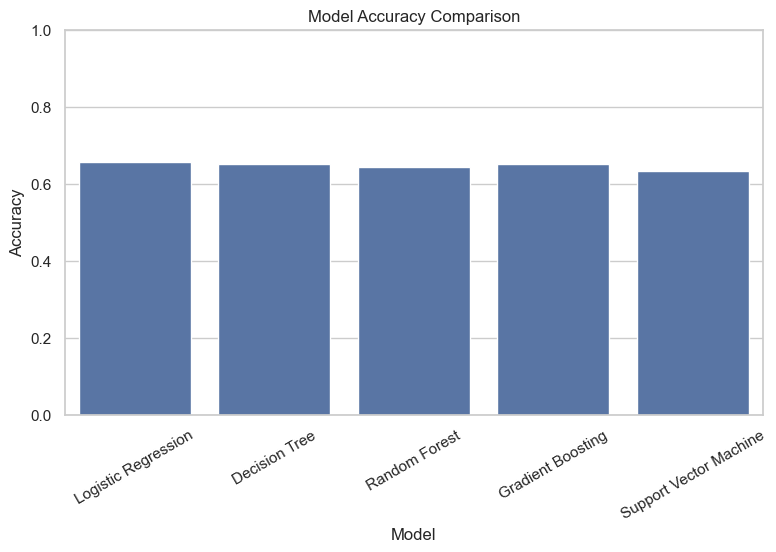

In [208]:
# Plot accuracy comparison

plt.figure(figsize=(9, 5))
sns.barplot(
    data=model_results_rounded,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

This plot compares model accuracy.

The model with the highest bar has the highest overall accuracy on the test dataset.

In [209]:
# Convert model results into long format for plotting

performance_long = model_results_rounded.melt(
    id_vars='Model',
    value_vars=['Precision', 'Recall', 'F1-score'],
    var_name='Metric',
    value_name='Score'
)

performance_long

,Model,Metric,Score
0,Logistic Regression,Precision,0.6107
1,Decision Tree,Precision,0.5960
2,Random Forest,Precision,0.5663
3,Gradient Boosting,Precision,0.5771
4,Support Vector Machine,Precision,0.5552
5,Logistic Regression,Recall,0.3037
6,Decision Tree,Recall,0.3144
7,Random Forest,Recall,0.3339
8,Gradient Boosting,Recall,0.3588
9,Support Vector Machine,Recall,0.2771


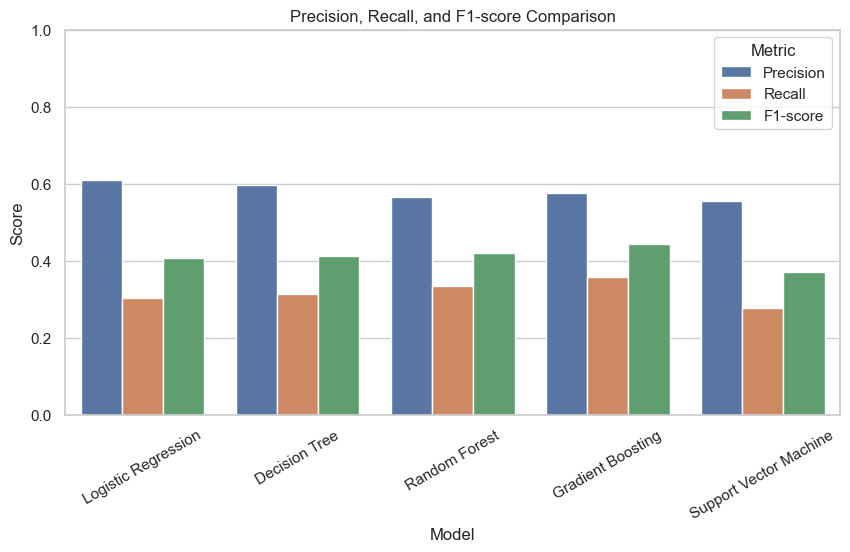

In [210]:
# Plot Precision, Recall, and F1-score comparison

plt.figure(figsize=(10, 5))
sns.barplot(
    data=performance_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Precision, Recall, and F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

This plot compares precision, recall, and F1-score for all models.

This is useful because a model may have high accuracy but low recall or precision.

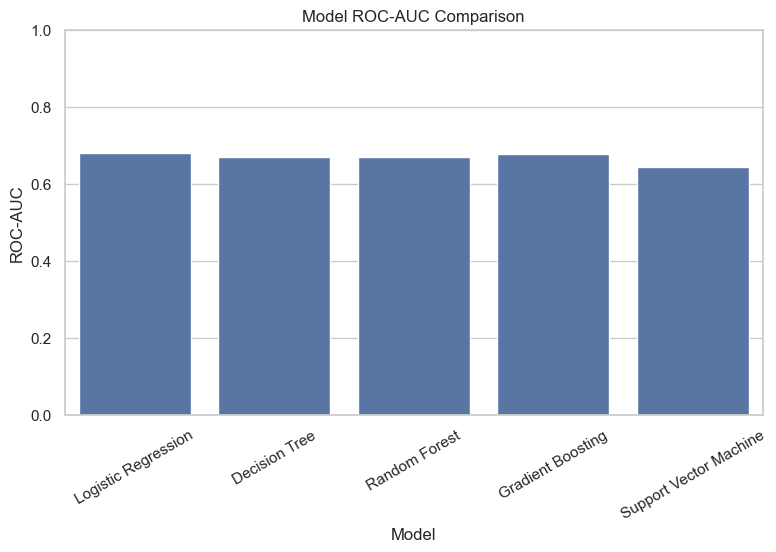

In [211]:
# Plot ROC-AUC comparison

plt.figure(figsize=(9, 5))
sns.barplot(
    data=model_results_rounded,
    x='Model',
    y='ROC-AUC'
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

ROC-AUC shows the model's ability to distinguish between people who reoffended and those who did not.

A higher ROC-AUC means better ranking performance.

## 15.2 Create Overall Performance Rank

To compare models more systematically, we create a simple ranking.

Each model is ranked based on:

1. Accuracy
2. F1-score
3. ROC-AUC

Lower rank value means better performance.

Then we calculate the average rank.

In [212]:
# Create ranking dataframe

ranking_df = model_results.copy()

# Rank models for each metric
# ascending=False because higher metric values are better

ranking_df['Accuracy Rank'] = ranking_df['Accuracy'].rank(ascending=False)
ranking_df['F1 Rank'] = ranking_df['F1-score'].rank(ascending=False)
ranking_df['ROC-AUC Rank'] = ranking_df['ROC-AUC'].rank(ascending=False)

# Calculate average rank

ranking_df['Average Performance Rank'] = ranking_df[
    ['Accuracy Rank', 'F1 Rank', 'ROC-AUC Rank']
].mean(axis=1)

# Sort by average rank

ranking_df = ranking_df.sort_values(by='Average Performance Rank')

ranking_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Accuracy Rank,F1 Rank,ROC-AUC Rank,Average Performance Rank
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213,1.0,4.0,1.0,2.000000
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938,3.0,1.0,2.0,2.000000
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693,2.0,3.0,3.0,2.666667
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932,4.0,2.0,4.0,3.333333
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383,5.0,5.0,5.0,5.000000


The average performance rank gives a simple overall comparison based on three important performance metrics.

This ranking is not the final model selection because fairness still needs to be evaluated.

In [213]:
# Save rounded model comparison results

model_results_rounded.to_csv("model_performance_comparison.csv", index=False)

# Save ranking results

ranking_df.to_csv("model_performance_ranking.csv", index=False)

print("Model performance comparison files saved successfully.")

Model performance comparison files saved successfully.


# 15.3 Performance Comparison Summary

In this section, the five trained machine learning models were compared using standard classification metrics.

The models compared were:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

The metrics used were:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The model with the highest accuracy is not automatically selected as the final model because this project also requires fairness evaluation.

In the next section, the fairness of each model will be evaluated using AIF360 and group-based error metrics.

# 16. Model Fairness Evaluation using AIF360

In this section, we evaluate the fairness of all five machine learning models.

The models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

Fairness is evaluated using the protected attribute:

`race_binary`

where:

- `race_binary = 0`: African-American defendants, unprivileged group
- `race_binary = 1`: Caucasian defendants, privileged group

The target variable is:

`is_recid`

Important:

In model prediction:

- `1` means predicted recidivism / high risk
- `0` means predicted no recidivism / low risk

In fairness interpretation:

- False Positive Rate is very important because it shows whether people who did not reoffend were wrongly classified as high risk.

In [214]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import metrics from sklearn

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Import AIF360 classes

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# Set plot style

sns.set(style="whitegrid")

We import `ClassificationMetric` from AIF360.

This class is used to compare true labels and predicted labels and calculate fairness metrics.

In [215]:
# Load model predictions saved in Section 15

model_predictions = pd.read_csv("model_predictions_all_5_models.csv")

# Display first rows

model_predictions.head()

,y_true,race_binary,logistic_regression_pred,decision_tree_pred,random_forest_pred,gradient_boosting_pred,svm_pred,logistic_regression_prob,decision_tree_prob,random_forest_prob,gradient_boosting_prob,svm_prob
0,0,1,0,0,0,0,0,0.108942,0.204918,0.224312,0.155470,0.313100
1,0,0,1,1,1,1,1,0.551651,0.701031,0.616269,0.587832,0.557180
2,0,0,0,0,0,0,0,0.242569,0.209337,0.214292,0.239700,0.314083
3,0,1,0,0,0,0,0,0.461917,0.457627,0.439547,0.484609,0.404352
4,0,1,0,0,0,0,0,0.356952,0.314010,0.308712,0.331699,0.321746


In [216]:
# Check columns

model_predictions.columns

Index(['y_true', 'race_binary', 'logistic_regression_pred',
       'decision_tree_pred', 'random_forest_pred', 'gradient_boosting_pred',
       'svm_pred', 'logistic_regression_prob', 'decision_tree_prob',
       'random_forest_prob', 'gradient_boosting_prob', 'svm_prob'],
      dtype='object')

The model predictions file contains:

- Actual labels
- Protected attribute
- Predicted labels from each model
- Predicted probabilities from each model

This allows us to calculate fairness metrics for every model.

In [217]:
# Check distribution of target variable in test set

model_predictions['y_true'].value_counts()

y_true
0    891
1    563
Name: count, dtype: int64

In [218]:
# Check distribution of protected attribute in test set

model_predictions['race_binary'].value_counts()

race_binary
0    889
1    565
Name: count, dtype: int64

The fairness evaluation is done on the test set.

This is important because fairness should be measured on unseen data, not only on the training data.

In [219]:
# Define privileged and unprivileged groups for AIF360

privileged_groups = [{'race_binary': 1}]
unprivileged_groups = [{'race_binary': 0}]

For fairness evaluation:

- African-American defendants are the unprivileged group.
- Caucasian defendants are the privileged group.

## 16.2 Important Label Convention for AIF360

In Section 9, we defined the favorable label as:

`is_recid = 0`

because not reoffending is the favorable outcome.

However, for model prediction error analysis, we also care about prediction of recidivism:

- `1`: predicted recidivism / high risk
- `0`: predicted no recidivism / low risk

For AIF360 classification metrics in this section, we will keep:

- Favorable label = 0
- Unfavorable label = 1

This means AIF360 metrics such as Statistical Parity Difference refer to favorable predictions, meaning predicted no recidivism.

For false positive rate and false negative rate, we will also calculate manual group-based values because these are easier to interpret in the COMPAS context.

In [220]:
# Function to create AIF360 BinaryLabelDataset

def create_aif360_dataset_from_prediction(data, label_column):
    """
    This function creates an AIF360 BinaryLabelDataset from a dataframe.
    
    Parameters:
    data: dataframe containing race_binary and label column
    label_column: column to use as label
    
    Returns:
    AIF360 BinaryLabelDataset
    """

    temp_df = data[['race_binary', label_column]].copy()

    dataset = BinaryLabelDataset(
        df=temp_df,
        label_names=[label_column],
        protected_attribute_names=['race_binary'],
        favorable_label=0,
        unfavorable_label=1
    )
    
    return dataset

This helper function converts actual labels or predicted labels into AIF360 dataset format.

We need one dataset for true labels and another dataset for predicted labels.

In [221]:
# Function to calculate AIF360 classification fairness metrics

def calculate_aif360_fairness_metrics(data, prediction_column, model_name):
    """
    This function calculates AIF360 fairness metrics for a model.
    
    Parameters:
    data: dataframe containing y_true, race_binary, and predictions
    prediction_column: column containing model predictions
    model_name: name of model
    
    Returns:
    Dictionary of fairness metrics
    """
    
    # Create dataset with true labels
    true_dataset = create_aif360_dataset_from_prediction(
        data=data.rename(columns={'y_true': 'label'}),
        label_column='label'
    )
    
    # Create dataset with predicted labels
    pred_dataset = create_aif360_dataset_from_prediction(
        data=data.rename(columns={prediction_column: 'label'}),
        label_column='label'
    )
    
    # Create ClassificationMetric object
    metric = ClassificationMetric(
        true_dataset,
        pred_dataset,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups
    )
    
    # Calculate fairness metrics
    results = {
        'Model': model_name,
        'Statistical Parity Difference': metric.statistical_parity_difference(),
        'Disparate Impact': metric.disparate_impact(),
        'Equal Opportunity Difference': metric.equal_opportunity_difference(),
        'Average Odds Difference': metric.average_odds_difference(),
        'Theil Index': metric.theil_index()
    }
    
    return results

This function calculates several AIF360 fairness metrics:

| Metric | Ideal Value | Meaning |
|---|---:|---|
| Statistical Parity Difference | 0 | Similar favorable prediction rates |
| Disparate Impact | 1 | Similar ratio of favorable prediction rates |
| Equal Opportunity Difference | 0 | Similar true positive rates |
| Average Odds Difference | 0 | Similar error behavior |
| Theil Index | 0 | Lower inequality in prediction errors |

## 16.3 Function to Calculate Manual Group Error Rates 
    
AIF360 gives important fairness metrics, but for the COMPAS dataset, false positive rate and false negative rate are especially important.

Therefore, we also calculate manual error rates by race.

Positive class = 1 means predicted recidivism / high risk.

In [222]:
# Function to calculate manual fairness error rates

def calculate_manual_fairness_rates(data, prediction_column, model_name):
    """
    This function calculates manual fairness error rates by group.
    
    Positive class = 1, meaning recidivism / high risk.
    
    Metrics:
    - False Positive Rate
    - False Negative Rate
    - True Positive Rate
    - True Negative Rate
    - Selection Rate
    
    Groups:
    - race_binary = 0: African-American
    - race_binary = 1: Caucasian
    """
    
    results = []
    
    for group_value, group_name in [(0, 'African-American'), (1, 'Caucasian')]:
        
        group_data = data[data['race_binary'] == group_value]
        
        y_true_group = group_data['y_true']
        y_pred_group = group_data[prediction_column]
        
        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        ).ravel()
        
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) != 0 else 0
        selection_rate = y_pred_group.mean()
        
        results.append({
            'Model': model_name,
            'Group': group_name,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'False Positive Rate': fpr,
            'False Negative Rate': fnr,
            'True Positive Rate': tpr,
            'True Negative Rate': tnr,
            'Selection Rate': selection_rate
        })
    
    return pd.DataFrame(results)

In [223]:
# Function to calculate fairness differences between groups

def calculate_fairness_differences(group_rates_df):
    """
    This function calculates differences between African-American and Caucasian groups.
    
    Difference formula:
    African-American rate - Caucasian rate
    
    A value close to 0 means similar rates across groups.
    """
    
    aa = group_rates_df[group_rates_df['Group'] == 'African-American'].iloc[0]
    caucasian = group_rates_df[group_rates_df['Group'] == 'Caucasian'].iloc[0]
    
    differences = {
        'Model': aa['Model'],
        'FPR Difference': aa['False Positive Rate'] - caucasian['False Positive Rate'],
        'FNR Difference': aa['False Negative Rate'] - caucasian['False Negative Rate'],
        'TPR Difference': aa['True Positive Rate'] - caucasian['True Positive Rate'],
        'TNR Difference': aa['True Negative Rate'] - caucasian['True Negative Rate'],
        'Selection Rate Difference': aa['Selection Rate'] - caucasian['Selection Rate']
    }
    
    return differences

The fairness difference values compare African-American and Caucasian defendants.

Difference formula:

African-American rate - Caucasian rate

For example:

- Positive FPR Difference means African-American defendants have a higher false positive rate.
- Negative FNR Difference means African-American defendants have a lower false negative rate.

In [224]:
# Define model prediction columns

model_prediction_columns = {
    'Logistic Regression': 'logistic_regression_pred',
    'Decision Tree': 'decision_tree_pred',
    'Random Forest': 'random_forest_pred',
    'Gradient Boosting': 'gradient_boosting_pred',
    'Support Vector Machine': 'svm_pred'
}

In [225]:
# Calculate fairness metrics for all models

aif360_fairness_results = []
manual_group_rates_all = []
manual_difference_results = []

for model_name, prediction_column in model_prediction_columns.items():
    
    # AIF360 metrics
    aif_metrics = calculate_aif360_fairness_metrics(
        data=model_predictions,
        prediction_column=prediction_column,
        model_name=model_name
    )
    
    aif360_fairness_results.append(aif_metrics)
    
    # Manual group error rates
    group_rates = calculate_manual_fairness_rates(
        data=model_predictions,
        prediction_column=prediction_column,
        model_name=model_name
    )
    
    manual_group_rates_all.append(group_rates)
    
    # Manual fairness differences
    differences = calculate_fairness_differences(group_rates)
    manual_difference_results.append(differences)

# Convert results to dataframes

aif360_fairness_results_df = pd.DataFrame(aif360_fairness_results)
manual_group_rates_all_df = pd.concat(manual_group_rates_all, ignore_index=True)
manual_difference_results_df = pd.DataFrame(manual_difference_results)

In [226]:
# Display AIF360 fairness results

aif360_fairness_results_df.round(4)

,Model,Statistical Parity Difference,Disparate Impact,Equal Opportunity Difference,Average Odds Difference,Theil Index
0,Logistic Regression,-0.1731,0.8104,-0.1112,-0.1799,0.1350
1,Decision Tree,-0.1343,0.8470,-0.0813,-0.1380,0.1431
2,Random Forest,-0.2056,0.7709,-0.1457,-0.2126,0.1611
3,Gradient Boosting,-0.2084,0.7649,-0.1487,-0.2137,0.1635
4,Support Vector Machine,-0.1742,0.8092,-0.1279,-0.1795,0.1477


This table shows the AIF360 fairness metrics for all five models.

Ideal values:

- Statistical Parity Difference: close to 0
- Disparate Impact: close to 1
- Equal Opportunity Difference: close to 0
- Average Odds Difference: close to 0
- Theil Index: lower is better

In [227]:
# Display manual group-based error rates

manual_group_rates_all_df.round(4)

,Model,Group,TN,FP,FN,TP,False Positive Rate,False Negative Rate,True Positive Rate,True Negative Rate,Selection Rate
0,Logistic Regression,African-American,435,88,223,143,0.1683,0.6093,0.3907,0.8317,0.2598
1,Logistic Regression,Caucasian,347,21,169,28,0.0571,0.8579,0.1421,0.9429,0.0867
2,Decision Tree,African-American,435,88,226,140,0.1683,0.6175,0.3825,0.8317,0.2565
3,Decision Tree,Caucasian,336,32,160,37,0.0870,0.8122,0.1878,0.9130,0.1221
4,Random Forest,African-American,407,116,208,158,0.2218,0.5683,0.4317,0.7782,0.3082
5,Random Forest,Caucasian,340,28,167,30,0.0761,0.8477,0.1523,0.9239,0.1027
6,Gradient Boosting,African-American,404,119,199,167,0.2275,0.5437,0.4563,0.7725,0.3217
7,Gradient Boosting,Caucasian,339,29,162,35,0.0788,0.8223,0.1777,0.9212,0.1133
8,Support Vector Machine,African-American,422,101,235,131,0.1931,0.6421,0.3579,0.8069,0.2610
9,Support Vector Machine,Caucasian,344,24,172,25,0.0652,0.8731,0.1269,0.9348,0.0867


This table shows error rates separately for African-American and Caucasian defendants.

Important columns:

- False Positive Rate
- False Negative Rate
- True Positive Rate
- Selection Rate

In [228]:
# Display fairness differences between groups

manual_difference_results_df.round(4)

,Model,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference
0,Logistic Regression,0.1112,-0.2486,0.2486,-0.1112,0.1731
1,Decision Tree,0.0813,-0.1947,0.1947,-0.0813,0.1343
2,Random Forest,0.1457,-0.2794,0.2794,-0.1457,0.2056
3,Gradient Boosting,0.1487,-0.2786,0.2786,-0.1487,0.2084
4,Support Vector Machine,0.1279,-0.2310,0.2310,-0.1279,0.1742


This table shows the difference between African-American and Caucasian groups.

Difference formula:

African-American rate - Caucasian rate

Values closer to 0 indicate more similar behavior across groups.

## 16.4 Merge Performance and Fairness Results

Now we combine model performance and fairness results into one table.

This helps us compare accuracy and fairness together.

In [229]:
# Load performance results

model_performance = pd.read_csv("model_results_all_5_models.csv")

# Merge performance with fairness differences

performance_fairness_comparison = model_performance.merge(
    manual_difference_results_df,
    on='Model',
    how='left'
)

# Merge with selected AIF360 metrics

performance_fairness_comparison = performance_fairness_comparison.merge(
    aif360_fairness_results_df,
    on='Model',
    how='left'
)

# Round for display

performance_fairness_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference,Statistical Parity Difference,Disparate Impact,Equal Opportunity Difference,Average Odds Difference,Theil Index
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802,0.1112,-0.2486,0.2486,-0.1112,0.1731,-0.1731,0.8104,-0.1112,-0.1799,0.1350
1,Decision Tree,0.6520,0.5960,0.3144,0.4116,0.6697,0.0813,-0.1947,0.1947,-0.0813,0.1343,-0.1343,0.8470,-0.0813,-0.1380,0.1431
2,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689,0.1457,-0.2794,0.2794,-0.1457,0.2056,-0.2056,0.7709,-0.1457,-0.2126,0.1611
3,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759,0.1487,-0.2786,0.2786,-0.1487,0.2084,-0.2084,0.7649,-0.1487,-0.2137,0.1635
4,Support Vector Machine,0.6341,0.5552,0.2771,0.3697,0.6424,0.1279,-0.2310,0.2310,-0.1279,0.1742,-0.1742,0.8092,-0.1279,-0.1795,0.1477


This table is one of the most important tables in the project.

It shows both:

1. Classification performance
2. Fairness behavior

This table will help us select the final fair model later.

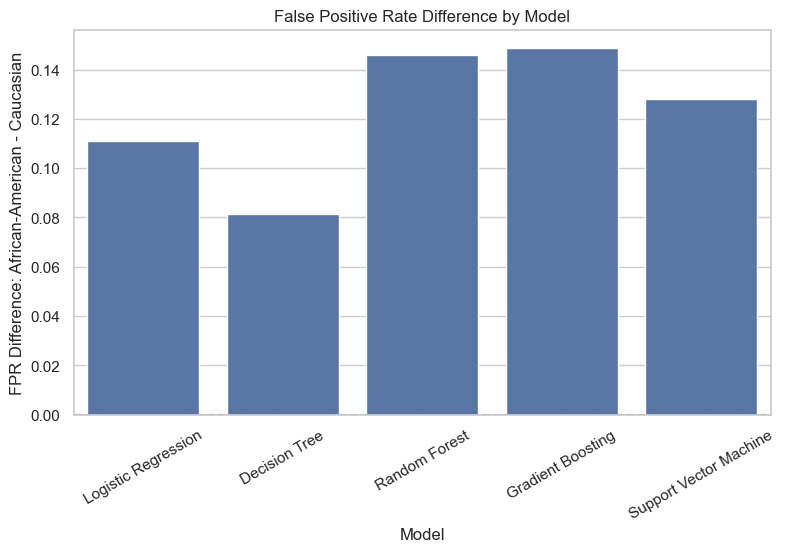

In [230]:
# Plot False Positive Rate Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=manual_difference_results_df,
    x='Model',
    y='FPR Difference'
)

plt.axhline(0, linestyle='--')
plt.title("False Positive Rate Difference by Model")
plt.xlabel("Model")
plt.ylabel("FPR Difference: African-American - Caucasian")
plt.xticks(rotation=30)
plt.show()

False Positive Rate Difference is one of the most important fairness metrics for COMPAS.

A positive value means African-American defendants are more often wrongly classified as high risk compared with Caucasian defendants.

A value closer to 0 is fairer.

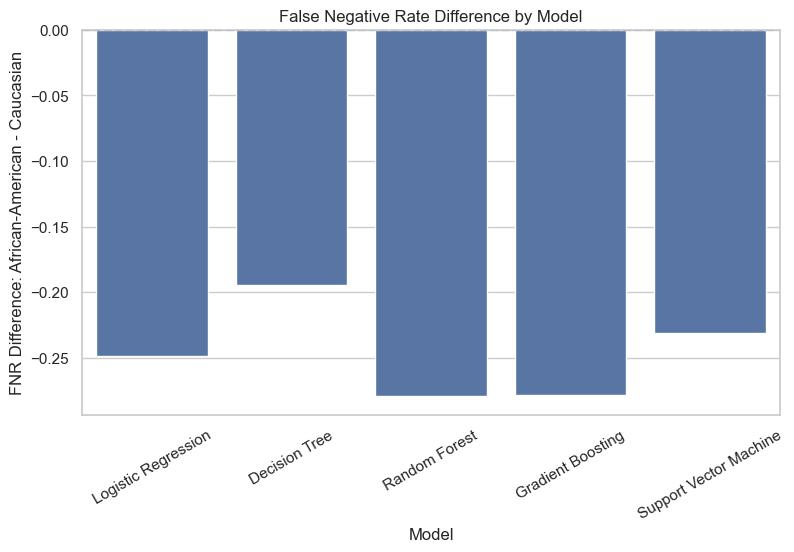

In [231]:
# Plot False Negative Rate Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=manual_difference_results_df,
    x='Model',
    y='FNR Difference'
)

plt.axhline(0, linestyle='--')
plt.title("False Negative Rate Difference by Model")
plt.xlabel("Model")
plt.ylabel("FNR Difference: African-American - Caucasian")
plt.xticks(rotation=30)
plt.show()

False Negative Rate Difference shows whether one group is more often wrongly predicted as low risk.

A value close to 0 means false negative rates are similar across racial groups.

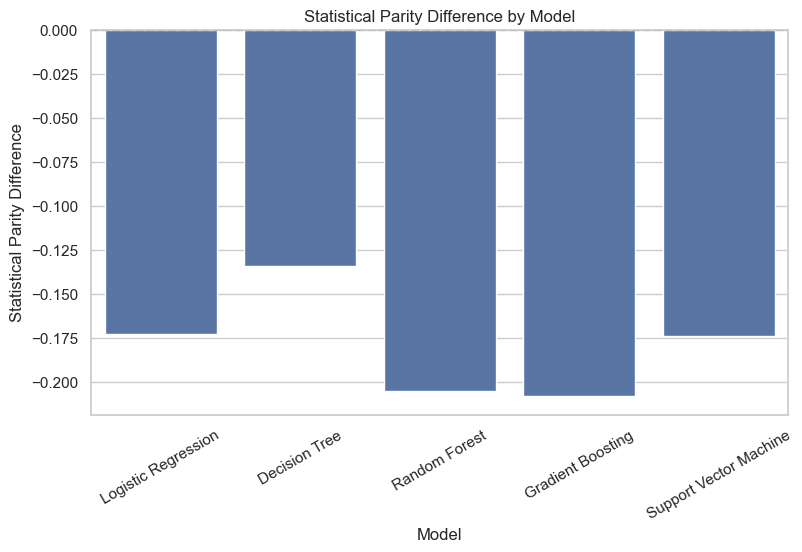

In [232]:
# Plot Statistical Parity Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=aif360_fairness_results_df,
    x='Model',
    y='Statistical Parity Difference'
)

plt.axhline(0, linestyle='--')
plt.title("Statistical Parity Difference by Model")
plt.xlabel("Model")
plt.ylabel("Statistical Parity Difference")
plt.xticks(rotation=30)
plt.show()

Statistical Parity Difference compares favorable prediction rates between groups.

Because favorable prediction is defined as predicted no recidivism, a negative value means African-American defendants receive favorable predictions less often than Caucasian defendants.

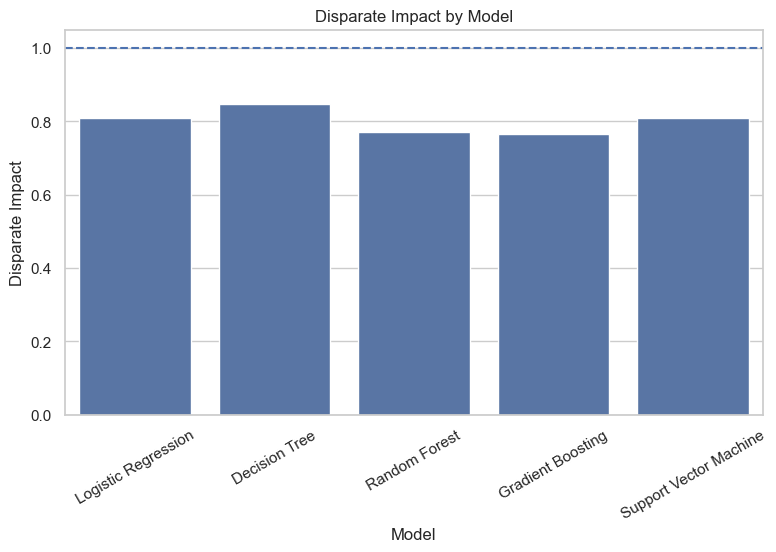

In [233]:
# Plot Disparate Impact

plt.figure(figsize=(9, 5))
sns.barplot(
    data=aif360_fairness_results_df,
    x='Model',
    y='Disparate Impact'
)

plt.axhline(1, linestyle='--')
plt.title("Disparate Impact by Model")
plt.xlabel("Model")
plt.ylabel("Disparate Impact")
plt.xticks(rotation=30)
plt.show()

Disparate Impact compares the ratio of favorable prediction rates.

The ideal value is 1.

A value below 1 means African-American defendants receive favorable predictions less often than Caucasian defendants.

In [234]:
# Save fairness results

aif360_fairness_results_df.to_csv("aif360_model_fairness_results.csv", index=False)
manual_group_rates_all_df.to_csv("manual_group_error_rates_all_models.csv", index=False)
manual_difference_results_df.to_csv("manual_fairness_differences_all_models.csv", index=False)
performance_fairness_comparison.to_csv("performance_fairness_comparison.csv", index=False)

print("Fairness evaluation results saved successfully.")

Fairness evaluation results saved successfully.


## 16.5 Identify Most Accurate and Fairest Models

Now we identify:

1. The model with the highest accuracy.
2. The model with the smallest absolute FPR Difference.
3. The model with the smallest absolute FNR Difference.
4. The model with the smallest absolute Statistical Parity Difference.

This does not automatically decide the final model, but it helps us understand the trade-off.

In [235]:
# Add absolute fairness difference columns

comparison_for_selection = performance_fairness_comparison.copy()

comparison_for_selection['Abs FPR Difference'] = comparison_for_selection['FPR Difference'].abs()
comparison_for_selection['Abs FNR Difference'] = comparison_for_selection['FNR Difference'].abs()
comparison_for_selection['Abs Statistical Parity Difference'] = comparison_for_selection['Statistical Parity Difference'].abs()

# Identify best models according to different criteria

best_accuracy_model = comparison_for_selection.loc[
    comparison_for_selection['Accuracy'].idxmax()
]

best_fpr_model = comparison_for_selection.loc[
    comparison_for_selection['Abs FPR Difference'].idxmin()
]

best_fnr_model = comparison_for_selection.loc[
    comparison_for_selection['Abs FNR Difference'].idxmin()
]

best_spd_model = comparison_for_selection.loc[
    comparison_for_selection['Abs Statistical Parity Difference'].idxmin()
]

print("Best model by Accuracy:")
print(best_accuracy_model[['Model', 'Accuracy']])

print("\nBest model by smallest absolute FPR Difference:")
print(best_fpr_model[['Model', 'FPR Difference']])

print("\nBest model by smallest absolute FNR Difference:")
print(best_fnr_model[['Model', 'FNR Difference']])

print("\nBest model by smallest absolute Statistical Parity Difference:")
print(best_spd_model[['Model', 'Statistical Parity Difference']])

Best model by Accuracy:
Model       Logistic Regression
Accuracy               0.655433
Name: 0, dtype: object

Best model by smallest absolute FPR Difference:
Model             Decision Tree
FPR Difference         0.081304
Name: 1, dtype: object

Best model by smallest absolute FNR Difference:
Model             Decision Tree
FNR Difference        -0.194696
Name: 1, dtype: object

Best model by smallest absolute Statistical Parity Difference:
Model                            Decision Tree
Statistical Parity Difference        -0.134344
Name: 1, dtype: object


This comparison shows that the most accurate model may not be the fairest model.

This is the central idea of the accuracy-fairness trade-off.

# 16.6 Fairness Evaluation Summary

In this section, model fairness was evaluated for all five machine learning models.

The following steps were completed:

1. Model predictions were loaded.
2. The protected attribute `race_binary` was used for group comparison.
3. African-American defendants were defined as the unprivileged group.
4. Caucasian defendants were defined as the privileged group.
5. AIF360 `ClassificationMetric` was used to calculate fairness metrics.
6. Manual group-based error rates were also calculated.
7. False Positive Rate, False Negative Rate, True Positive Rate, and Selection Rate were calculated by race.
8. Fairness differences were calculated as African-American rate minus Caucasian rate.
9. Performance and fairness results were merged into one comparison table.
10. Fairness results were visualized.
11. The most accurate model and fairest models were identified using different criteria.

The results show that model selection should not be based only on accuracy. A good fair machine learning model should balance predictive performance with fairness across racial groups.


In Section 15, I compared all five machine learning models using performance metrics: accuracy, precision, recall, F1-score, and ROC-AUC. I also created visual comparisons and ranked the models based on accuracy, F1-score, and ROC-AUC. This helped identify which models performed best from a traditional machine learning perspective.

In Section 16, I evaluated fairness for each model using both AIF360 and manual group-based error rates. I used race_binary as the protected attribute, where African-American defendants were the unprivileged group and Caucasian defendants were the privileged group.

AIF360 was used to calculate metrics such as Statistical Parity Difference, Disparate Impact, Equal Opportunity Difference, Average Odds Difference, and Theil Index. I also manually calculated False Positive Rate and False Negative Rate by race because these are especially important in the COMPAS case.

The fairness differences were calculated as African-American rate minus Caucasian rate. A value close to zero means the model behaves similarly for both groups. This section showed that the most accurate model is not necessarily the fairest model, which motivates the next steps: hyperparameter tuning and bias mitigation.

----------

# 17. Hyperparameter Tuning

Hyperparameter tuning is the process of finding better model settings before training the final model.

Machine learning models have two types of parameters:

1. **Model parameters**  
   These are learned automatically during training.  
   Example: coefficients in Logistic Regression.

2. **Hyperparameters**  
   These are set before training.  
   Example: maximum tree depth in Decision Tree or number of trees in Random Forest.

In this section, we tune selected models to improve classification performance.

The goal is to find models with good accuracy, F1-score, and ROC-AUC before applying fairness mitigation.

Important:

Hyperparameter tuning improves predictive performance, but it does not automatically guarantee fairness. Therefore, after tuning, we still need to evaluate fairness.

In [236]:
# Import basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import train-test split and GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Import scaler

from sklearn.preprocessing import StandardScaler

# Import models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Import evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set plot style

sns.set(style="whitegrid")

We use `GridSearchCV` for hyperparameter tuning.

`GridSearchCV` tests different combinations of hyperparameters and selects the best combination based on a scoring metric.

In this project, we use `f1` as the main scoring metric because it balances precision and recall.

In [237]:
# Load encoded machine learning dataset

df_model_encoded = pd.read_csv("compas_model_encoded.csv")

# Display first rows

df_model_encoded.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
0,34,0,0,0,0,1,0,1,2,True,False
1,24,0,0,1,4,1,0,0,2,True,False
2,23,0,1,0,1,0,0,0,2,True,False
3,41,0,0,0,14,1,1,1,2,True,True
4,39,0,0,0,0,0,1,1,1,False,True


In [238]:
# Check shape

print("Rows:", df_model_encoded.shape[0])
print("Columns:", df_model_encoded.shape[1])

Rows: 7267
Columns: 11


In [239]:
# Define target variable

y = df_model_encoded['is_recid']

# Define protected attribute

protected_attribute = df_model_encoded['race_binary']

# Define features

X = df_model_encoded.drop(columns=['is_recid'])

# Check shapes

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Protected attribute shape:", protected_attribute.shape)

X shape: (7267, 10)
y shape: (7267,)
Protected attribute shape: (7267,)


In [240]:
# Split dataset into train and test sets

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X,
    y,
    protected_attribute,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5813, 10)
X_test : (1454, 10)
y_train: (5813,)
y_test : (1454,)


In [241]:
# Scale features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [242]:
# Helper function to evaluate tuned models

def evaluate_tuned_model(model_name, y_true, y_pred, y_prob=None):
    """
    This function evaluates a tuned classification model.
    
    Parameters:
    model_name: name of the model
    y_true: actual labels
    y_pred: predicted labels
    y_prob: predicted probability for class 1
    
    Returns:
    Dictionary of performance metrics
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }
    
    return results

## 17.2 Tune Logistic Regression

For Logistic Regression, we tune:

- `C`: controls regularization strength
- `penalty`: type of regularization
- `solver`: optimization algorithm

A smaller value of `C` means stronger regularization.

In [243]:
# Define Logistic Regression model

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Define hyperparameter grid

log_reg_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Create GridSearchCV object

log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit grid search on scaled training data

log_reg_grid.fit(X_train_scaled, y_train)

# Print best parameters and best score

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(log_reg_grid.best_score_, 4))

Best Logistic Regression Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross-Validation F1-score:
0.3931


In [244]:
# Get best Logistic Regression model

best_log_reg = log_reg_grid.best_estimator_

# Make predictions on test data

y_pred_best_log_reg = best_log_reg.predict(X_test_scaled)
y_prob_best_log_reg = best_log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate tuned Logistic Regression

best_log_reg_results = evaluate_tuned_model(
    model_name='Tuned Logistic Regression',
    y_true=y_test,
    y_pred=y_pred_best_log_reg,
    y_prob=y_prob_best_log_reg
)

best_log_reg_results

{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.655433287482806,
 'Precision': 0.6107142857142858,
 'Recall': 0.3037300177619893,
 'F1-score': 0.40569395017793597,
 'ROC-AUC': 0.6802134229606106}

In [245]:
# Classification report for tuned Logistic Regression

print("Classification Report: Tuned Logistic Regression")
print("------------------------------------------------")
print(classification_report(y_test, y_pred_best_log_reg))

Classification Report: Tuned Logistic Regression
------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       891
           1       0.61      0.30      0.41       563

    accuracy                           0.66      1454
   macro avg       0.64      0.59      0.58      1454
weighted avg       0.64      0.66      0.62      1454



## 17.3 Tune Decision Tree

For Decision Tree, we tune:

- `max_depth`: maximum depth of the tree
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required in a leaf node
- `criterion`: splitting criterion

This helps reduce overfitting and improve generalization.

In [246]:
# Define Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Define hyperparameter grid

decision_tree_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create GridSearchCV object

decision_tree_grid = GridSearchCV(
    estimator=decision_tree,
    param_grid=decision_tree_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit grid search on unscaled data

decision_tree_grid.fit(X_train, y_train)

# Print best parameters and best score

print("Best Decision Tree Parameters:")
print(decision_tree_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(decision_tree_grid.best_score_, 4))

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}

Best Cross-Validation F1-score:
0.4453


In [247]:
# Get best Decision Tree model

best_decision_tree = decision_tree_grid.best_estimator_

# Make predictions on test data

y_pred_best_tree = best_decision_tree.predict(X_test)
y_prob_best_tree = best_decision_tree.predict_proba(X_test)[:, 1]

# Evaluate tuned Decision Tree

best_decision_tree_results = evaluate_tuned_model(
    model_name='Tuned Decision Tree',
    y_true=y_test,
    y_pred=y_pred_best_tree,
    y_prob=y_prob_best_tree
)

best_decision_tree_results

{'Model': 'Tuned Decision Tree',
 'Accuracy': 0.6237964236588721,
 'Precision': 0.524390243902439,
 'Recall': 0.30550621669627,
 'F1-score': 0.38608305274971944,
 'ROC-AUC': 0.647640805130444}

In [248]:
# Classification report for tuned Decision Tree

print("Classification Report: Tuned Decision Tree")
print("------------------------------------------")
print(classification_report(y_test, y_pred_best_tree))

Classification Report: Tuned Decision Tree
------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.82      0.73       891
           1       0.52      0.31      0.39       563

    accuracy                           0.62      1454
   macro avg       0.59      0.57      0.56      1454
weighted avg       0.60      0.62      0.60      1454



## 17.4 Tune Random Forest

For Random Forest, we tune:

- `n_estimators`: number of trees
- `max_depth`: maximum depth of trees
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required in a leaf node

Random Forest can be computationally expensive, so we use a moderate grid.

In [249]:
# Define Random Forest model

random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define hyperparameter grid

random_forest_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

# Create GridSearchCV object

random_forest_grid = GridSearchCV(
    estimator=random_forest,
    param_grid=random_forest_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit grid search on unscaled data

random_forest_grid.fit(X_train, y_train)

# Print best parameters and best score

print("Best Random Forest Parameters:")
print(random_forest_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(random_forest_grid.best_score_, 4))

Best Random Forest Parameters:
{'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

Best Cross-Validation F1-score:
0.4522


In [250]:
# Get best Random Forest model

best_random_forest = random_forest_grid.best_estimator_

# Make predictions on test data

y_pred_best_rf = best_random_forest.predict(X_test)
y_prob_best_rf = best_random_forest.predict_proba(X_test)[:, 1]

# Evaluate tuned Random Forest

best_random_forest_results = evaluate_tuned_model(
    model_name='Tuned Random Forest',
    y_true=y_test,
    y_pred=y_pred_best_rf,
    y_prob=y_prob_best_rf
)

best_random_forest_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.640302613480055,
 'Precision': 0.554945054945055,
 'Recall': 0.35879218472468916,
 'F1-score': 0.43581445523193096,
 'ROC-AUC': 0.6429590955937907}

In [251]:
# Classification report for tuned Random Forest

print("Classification Report: Tuned Random Forest")
print("------------------------------------------")
print(classification_report(y_test, y_pred_best_rf))

Classification Report: Tuned Random Forest
------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.82      0.74       891
           1       0.55      0.36      0.44       563

    accuracy                           0.64      1454
   macro avg       0.61      0.59      0.59      1454
weighted avg       0.62      0.64      0.62      1454



## 17.5 Tune Gradient Boosting

For Gradient Boosting, we tune:

- `n_estimators`: number of boosting stages
- `learning_rate`: step size for each boosting update
- `max_depth`: depth of each tree
- `subsample`: fraction of samples used for fitting each tree

Gradient Boosting can perform very well, but it needs careful tuning to avoid overfitting.

In [252]:
# Define Gradient Boosting model

gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

# Define hyperparameter grid

gradient_boosting_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

# Create GridSearchCV object

gradient_boosting_grid = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=gradient_boosting_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit grid search on unscaled data

gradient_boosting_grid.fit(X_train, y_train)

# Print best parameters and best score

print("Best Gradient Boosting Parameters:")
print(gradient_boosting_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(gradient_boosting_grid.best_score_, 4))

Best Gradient Boosting Parameters:
{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best Cross-Validation F1-score:
0.4638


In [253]:
# Get best Gradient Boosting model

best_gradient_boosting = gradient_boosting_grid.best_estimator_

# Make predictions on test data

y_pred_best_gb = best_gradient_boosting.predict(X_test)
y_prob_best_gb = best_gradient_boosting.predict_proba(X_test)[:, 1]

# Evaluate tuned Gradient Boosting

best_gradient_boosting_results = evaluate_tuned_model(
    model_name='Tuned Gradient Boosting',
    y_true=y_test,
    y_pred=y_pred_best_gb,
    y_prob=y_prob_best_gb
)

best_gradient_boosting_results

{'Model': 'Tuned Gradient Boosting',
 'Accuracy': 0.6513067400275103,
 'Precision': 0.5773480662983426,
 'Recall': 0.37122557726465366,
 'F1-score': 0.4518918918918919,
 'ROC-AUC': 0.6767886084049494}

In [254]:
# Classification report for tuned Gradient Boosting

print("Classification Report: Tuned Gradient Boosting")
print("------------------------------------------------")
print(classification_report(y_test, y_pred_best_gb))

Classification Report: Tuned Gradient Boosting
------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.83      0.74       891
           1       0.58      0.37      0.45       563

    accuracy                           0.65      1454
   macro avg       0.63      0.60      0.60      1454
weighted avg       0.64      0.65      0.63      1454



In [255]:
# Combine tuned model results

tuned_model_results = pd.DataFrame([
    best_log_reg_results,
    best_decision_tree_results,
    best_random_forest_results,
    best_gradient_boosting_results
])

# Display rounded results

tuned_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
1,Tuned Decision Tree,0.6238,0.5244,0.3055,0.3861,0.6476
2,Tuned Random Forest,0.6403,0.5549,0.3588,0.4358,0.6430
3,Tuned Gradient Boosting,0.6513,0.5773,0.3712,0.4519,0.6768


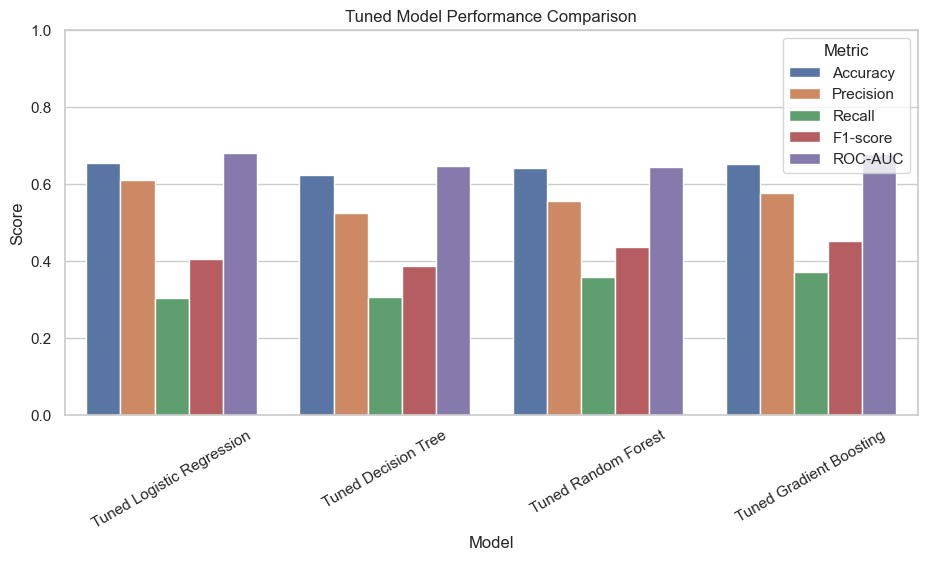

In [256]:
# Convert tuned model results to long format

tuned_results_long = tuned_model_results.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

# Plot tuned model comparison

plt.figure(figsize=(11, 5))
sns.barplot(
    data=tuned_results_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Tuned Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

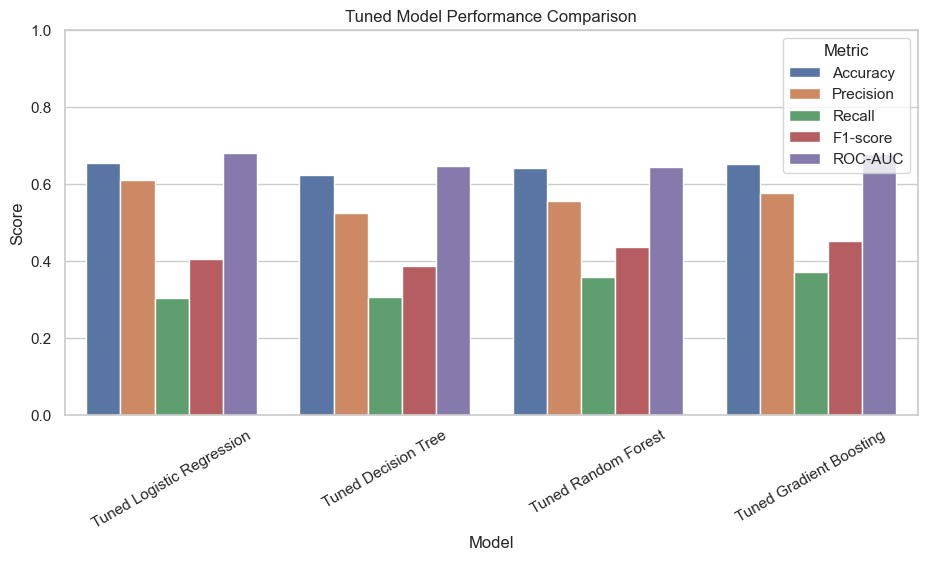

In [257]:
# Convert tuned model results to long format

tuned_results_long = tuned_model_results.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

# Plot tuned model comparison

plt.figure(figsize=(11, 5))
sns.barplot(
    data=tuned_results_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Tuned Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

In [258]:
# Save tuned model performance results

tuned_model_results.to_csv("tuned_model_results.csv", index=False)

print("Tuned model results saved successfully.")

Tuned model results saved successfully.


In [259]:
# Save tuned model predictions for later fairness evaluation

tuned_model_predictions = pd.DataFrame({
    'y_true': y_test,
    'race_binary': protected_test,
    'tuned_logistic_regression_pred': y_pred_best_log_reg,
    'tuned_decision_tree_pred': y_pred_best_tree,
    'tuned_random_forest_pred': y_pred_best_rf,
    'tuned_gradient_boosting_pred': y_pred_best_gb,
    'tuned_logistic_regression_prob': y_prob_best_log_reg,
    'tuned_decision_tree_prob': y_prob_best_tree,
    'tuned_random_forest_prob': y_prob_best_rf,
    'tuned_gradient_boosting_prob': y_prob_best_gb
})

tuned_model_predictions.to_csv("tuned_model_predictions.csv", index=False)

print("Tuned model predictions saved successfully.")

Tuned model predictions saved successfully.


# 17.6 Hyperparameter Tuning Summary

In this section, hyperparameter tuning was performed for four models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

GridSearchCV was used to test different hyperparameter combinations.

The scoring metric used for tuning was F1-score because it balances precision and recall.

After tuning, the best version of each model was evaluated on the test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The tuned model results and predictions were saved for later comparison.

Important conclusion:

Hyperparameter tuning can improve model performance, but it does not automatically improve fairness. Therefore, fairness-aware methods are still needed.

# 18. Bias Mitigation using AIF360 Reweighing

Bias mitigation means applying methods to reduce unfairness in machine learning.

AIF360 provides three main types of bias mitigation methods:

1. **Pre-processing methods**  
   These modify the training data before model training.

2. **In-processing methods**  
   These modify the learning algorithm during training.

3. **Post-processing methods**  
   These modify the model predictions after training.

In this section, we use a pre-processing method called:

**Reweighing**

Reweighing assigns different weights to training samples so that the model pays more attention to underrepresented or disadvantaged group-outcome combinations.

The goal is to reduce unfairness while keeping reasonable model performance.

## 18.1 Why Use Reweighing?

Reweighing is suitable for this project because:

1. It is available in AIF360.
2. It is easier to understand than many advanced fairness algorithms.
3. It works before model training.
4. It can be used with many scikit-learn models through `sample_weight`.
5. It helps reduce bias in the training data without changing the test data.

In this project:

- Protected attribute: `race_binary`
- Unprivileged group: African-American, coded as 0
- Privileged group: Caucasian, coded as 1
- Favorable label: `is_recid = 0`
- Unfavorable label: `is_recid = 1`

In [260]:
# Import basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import train-test split and scaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Import metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Import AIF360 classes

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

# Set plot style

sns.set(style="whitegrid")

We import `Reweighing` from AIF360.

This algorithm calculates sample weights for the training dataset.

These weights are then used during model training.

In [261]:
# Load encoded dataset

df_model_encoded = pd.read_csv("compas_model_encoded.csv")

# Display first rows

df_model_encoded.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
0,34,0,0,0,0,1,0,1,2,True,False
1,24,0,0,1,4,1,0,0,2,True,False
2,23,0,1,0,1,0,0,0,2,True,False
3,41,0,0,0,14,1,1,1,2,True,True
4,39,0,0,0,0,0,1,1,1,False,True


## 18.2 Prepare Data for Reweighing

For reweighing, we use the same encoded dataset.

We need:

- Features
- Target variable
- Protected attribute

The protected attribute is:

`race_binary`

The target variable is:

`is_recid`

In [262]:
# Define target and protected attribute

y = df_model_encoded['is_recid']
protected_attribute = df_model_encoded['race_binary']

# Define features

X = df_model_encoded.drop(columns=['is_recid'])

# Train-test split

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X,
    y,
    protected_attribute,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (5813, 10)
Testing data shape : (1454, 10)


## 18.3 Create Training Dataframe for AIF360

AIF360 needs a single dataframe containing:

- Feature columns
- Target label
- Protected attribute

Since `race_binary` is already included in `X_train`, we only need to add the target column `is_recid`.

In [263]:
# Create dataframe for AIF360 training data

train_df_aif = X_train.copy()
train_df_aif['is_recid'] = y_train

# Check first rows

train_df_aif.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian,is_recid
5414,21,0,0,0,0,1,0,2,True,True,1
4319,31,0,0,0,3,0,1,2,True,False,0
823,26,0,0,0,10,0,1,1,True,False,1
3659,23,0,0,0,1,1,0,1,False,True,0
1712,33,0,0,0,5,0,1,1,False,False,0


In [264]:
# Check required columns

print("race_binary in training dataframe:", 'race_binary' in train_df_aif.columns)
print("is_recid in training dataframe:", 'is_recid' in train_df_aif.columns)

race_binary in training dataframe: True
is_recid in training dataframe: True


In [265]:
# Define privileged and unprivileged groups

privileged_groups = [{'race_binary': 1}]
unprivileged_groups = [{'race_binary': 0}]

# Define labels

favorable_label = 0
unfavorable_label = 1

For AIF360:

- `race_binary = 1` is the privileged group.
- `race_binary = 0` is the unprivileged group.
- `is_recid = 0` is the favorable label.
- `is_recid = 1` is the unfavorable label.

In [266]:
# Convert training dataframe into AIF360 BinaryLabelDataset

train_aif_dataset = BinaryLabelDataset(
    df=train_df_aif,
    label_names=['is_recid'],
    protected_attribute_names=['race_binary'],
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

print("AIF360 training dataset created successfully.")

AIF360 training dataset created successfully.


In [267]:
# Create Reweighing object

reweighing = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Fit and transform training dataset

train_aif_reweighed = reweighing.fit_transform(train_aif_dataset)

print("Reweighing applied successfully.")

Reweighing applied successfully.


Reweighing calculates sample weights for different group-outcome combinations.

These weights are stored in:

`train_aif_reweighed.instance_weights`

The machine learning model can use these weights during training.

In [268]:
# Extract sample weights

sample_weights = train_aif_reweighed.instance_weights

# Display first 10 sample weights

sample_weights[:10]

array([1.16627923, 1.06273448, 0.91462545, 0.9172934 , 1.06273448,
       0.91462545, 1.06273448, 1.06273448, 0.9172934 , 1.06273448])

In [269]:
# Summary statistics of sample weights

pd.Series(sample_weights).describe()

count    5813.000000
mean        1.000000
std         0.093164
min         0.914625
25%         0.914625
50%         0.917293
75%         1.062734
max         1.166279
dtype: float64

In [270]:
# Add sample weights to a temporary dataframe for inspection

weights_inspection = train_df_aif[['race_binary', 'is_recid']].copy()
weights_inspection['sample_weight'] = sample_weights

# Calculate average weight by race and target group

weights_inspection.groupby(['race_binary', 'is_recid'])['sample_weight'].mean()

race_binary  is_recid
0            0           1.062734
             1           0.914625
1            0           0.917293
             1           1.166279
Name: sample_weight, dtype: float64

The sample weights differ by race and target group.

This means the model will give different importance to different group-outcome combinations during training.

This can help reduce bias in the learned model.

Logistic Regression requires scaled features.

The sample weights are calculated on the training data, but feature scaling is still performed separately.

Important:

The scaler is fitted only on the training data.

In [271]:
# Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

## 18.4 Train Reweighed Logistic Regression

We now train Logistic Regression using the sample weights from AIF360 Reweighing.

The important part is:

`sample_weight=sample_weights`

This tells the model to give different importance to different training examples.

In [272]:
# Create Logistic Regression model

rw_log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train with sample weights

rw_log_reg_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)

print("Reweighed Logistic Regression trained successfully.")

Reweighed Logistic Regression trained successfully.


## 18.5 Train Reweighed Random Forest

Random Forest can also use sample weights.

We train Random Forest using the original unscaled features and the reweighing sample weights.

In [273]:
# Create Random Forest model

rw_random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train with sample weights

rw_random_forest_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Reweighed Random Forest trained successfully.")

Reweighed Random Forest trained successfully.


In [274]:
# Create Random Forest model

rw_random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train with sample weights

rw_random_forest_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Reweighed Random Forest trained successfully.")

Reweighed Random Forest trained successfully.


## 18.6 Train Reweighed Gradient Boosting

Gradient Boosting also supports sample weights.

We train Gradient Boosting using the original unscaled features and reweighing sample weights.

In [275]:
# Create Gradient Boosting model

rw_gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train with sample weights

rw_gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Reweighed Gradient Boosting trained successfully.")

Reweighed Gradient Boosting trained successfully.


In [276]:
# Logistic Regression predictions

y_pred_rw_log_reg = rw_log_reg_model.predict(X_test_scaled)
y_prob_rw_log_reg = rw_log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest predictions

y_pred_rw_rf = rw_random_forest_model.predict(X_test)
y_prob_rw_rf = rw_random_forest_model.predict_proba(X_test)[:, 1]

# Gradient Boosting predictions

y_pred_rw_gb = rw_gradient_boosting_model.predict(X_test)
y_prob_rw_gb = rw_gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Predictions from reweighed models created successfully.")

Predictions from reweighed models created successfully.


In [277]:
# Helper function for evaluation

def evaluate_model_after_reweighing(model_name, y_true, y_pred, y_prob=None):
    """
    Evaluate classification model after reweighing.
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }

In [278]:
# Evaluate all reweighed models

rw_log_reg_results = evaluate_model_after_reweighing(
    'Reweighed Logistic Regression',
    y_test,
    y_pred_rw_log_reg,
    y_prob_rw_log_reg
)

rw_rf_results = evaluate_model_after_reweighing(
    'Reweighed Random Forest',
    y_test,
    y_pred_rw_rf,
    y_prob_rw_rf
)

rw_gb_results = evaluate_model_after_reweighing(
    'Reweighed Gradient Boosting',
    y_test,
    y_pred_rw_gb,
    y_prob_rw_gb
)

# Combine results

reweighed_model_results = pd.DataFrame([
    rw_log_reg_results,
    rw_rf_results,
    rw_gb_results
])

reweighed_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Reweighed Logistic Regression,0.6479,0.6016,0.2682,0.3710,0.6786
1,Reweighed Random Forest,0.6424,0.5705,0.3091,0.4009,0.6679
2,Reweighed Gradient Boosting,0.6534,0.5961,0.3250,0.4207,0.6769


In [279]:
# Classification report for Reweighed Logistic Regression

print("Classification Report: Reweighed Logistic Regression")
print("----------------------------------------------------")
print(classification_report(y_test, y_pred_rw_log_reg))

Classification Report: Reweighed Logistic Regression
----------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       891
           1       0.60      0.27      0.37       563

    accuracy                           0.65      1454
   macro avg       0.63      0.58      0.56      1454
weighted avg       0.64      0.65      0.61      1454



In [280]:
# Classification report for Reweighed Random Forest

print("Classification Report: Reweighed Random Forest")
print("------------------------------------------------")
print(classification_report(y_test, y_pred_rw_rf))

Classification Report: Reweighed Random Forest
------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.85      0.75       891
           1       0.57      0.31      0.40       563

    accuracy                           0.64      1454
   macro avg       0.62      0.58      0.57      1454
weighted avg       0.63      0.64      0.61      1454



In [281]:
# Classification report for Reweighed Gradient Boosting

print("Classification Report: Reweighed Gradient Boosting")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred_rw_gb))

Classification Report: Reweighed Gradient Boosting
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       891
           1       0.60      0.33      0.42       563

    accuracy                           0.65      1454
   macro avg       0.63      0.59      0.59      1454
weighted avg       0.64      0.65      0.62      1454



In [282]:
# Save reweighed model results

reweighed_model_results.to_csv("reweighed_model_results.csv", index=False)

print("Reweighed model results saved successfully.")

Reweighed model results saved successfully.


In [283]:
# Save reweighed model predictions

reweighed_model_predictions = pd.DataFrame({
    'y_true': y_test,
    'race_binary': protected_test,
    'reweighed_logistic_regression_pred': y_pred_rw_log_reg,
    'reweighed_random_forest_pred': y_pred_rw_rf,
    'reweighed_gradient_boosting_pred': y_pred_rw_gb,
    'reweighed_logistic_regression_prob': y_prob_rw_log_reg,
    'reweighed_random_forest_prob': y_prob_rw_rf,
    'reweighed_gradient_boosting_prob': y_prob_rw_gb
})

reweighed_model_predictions.to_csv("reweighed_model_predictions.csv", index=False)

print("Reweighed model predictions saved successfully.")

Reweighed model predictions saved successfully.


## 18.7 Compare Original and Reweighed Performance

Now we compare the original model results with the reweighed model results.

This helps us check whether reweighing improved or reduced predictive performance.

In [284]:
# Load original model results

original_model_results = pd.read_csv("model_results_all_5_models.csv")

# Keep comparable original models

original_selected_models = original_model_results[
    original_model_results['Model'].isin([
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ])
].copy()

# Combine original and reweighed results

original_vs_reweighed_performance = pd.concat(
    [original_selected_models, reweighed_model_results],
    ignore_index=True
)

# Display comparison

original_vs_reweighed_performance.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802
1,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689
2,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759
3,Reweighed Logistic Regression,0.6479,0.6016,0.2682,0.3710,0.6786
4,Reweighed Random Forest,0.6424,0.5705,0.3091,0.4009,0.6679
5,Reweighed Gradient Boosting,0.6534,0.5961,0.3250,0.4207,0.6769


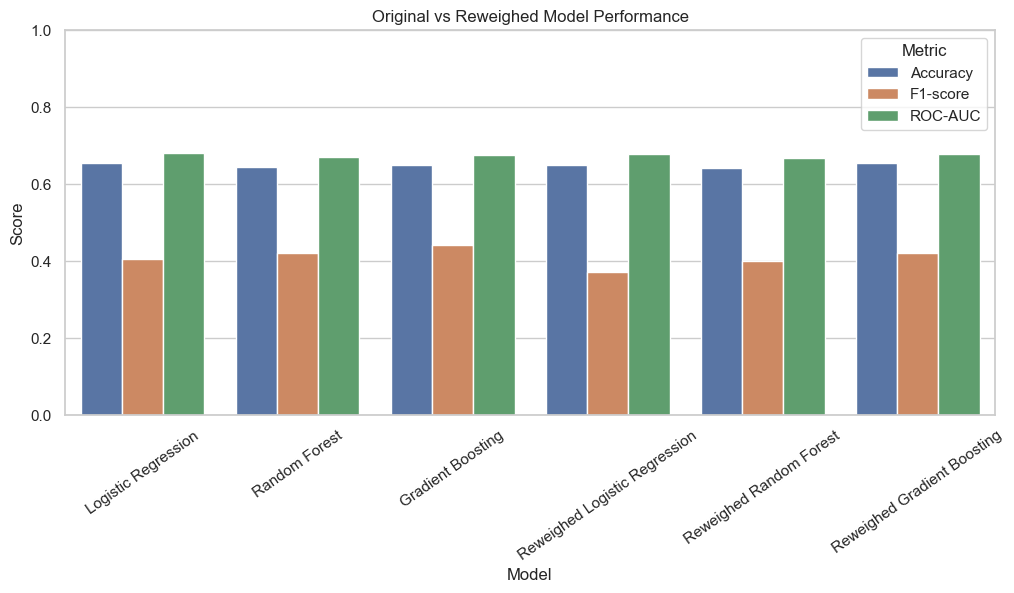

In [285]:
# Plot comparison of original and reweighed models

performance_long = original_vs_reweighed_performance.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'F1-score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=performance_long,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Original vs Reweighed Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=35)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

# 18.8 Bias Mitigation using Reweighing Summary

In this section, AIF360 Reweighing was applied as a bias mitigation method.

The following steps were completed:

1. The encoded dataset was loaded.
2. The target variable and protected attribute were defined.
3. The training data was converted into an AIF360 `BinaryLabelDataset`.
4. The privileged and unprivileged groups were defined.
5. AIF360 Reweighing was applied only on the training data.
6. Sample weights were extracted from the reweighed dataset.
7. Logistic Regression, Random Forest, and Gradient Boosting were trained using these sample weights.
8. Predictions were made on the unchanged test set.
9. Reweighed model performance was evaluated.
10. Original and reweighed model performance were compared.
11. Reweighed model results and predictions were saved for later fairness comparison.

Important conclusion:

Reweighing modifies the influence of training samples but does not change the test data. This is important because the model should still be evaluated on real unseen data.

The next section will train and compare models after reweighing in more detail, especially using fairness metrics.

# 19. Train Models Again after Reweighing

In Section 19, AIF360 Reweighing was applied to the training data.

Reweighing produced sample weights that give different importance to different training examples based on:

1. Protected group membership
2. Target outcome

In this section, we organize the reweighed model training process clearly and prepare the results for final comparison.

The models trained after reweighing are:

1. Reweighed Logistic Regression
2. Reweighed Random Forest
3. Reweighed Gradient Boosting

These models are selected because they support `sample_weight` during training.

The main goal is to check whether reweighing improves fairness while keeping acceptable classification performance.

In [286]:
# Import basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import train-test split and scaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Import evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Import AIF360 tools

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

# Set plot style

sns.set(style="whitegrid")

We import all required libraries again so that this section can run independently if needed.

This includes:

- Scikit-learn models
- Scikit-learn evaluation metrics
- AIF360 Reweighing
- AIF360 ClassificationMetric

In [287]:
# Load encoded machine learning dataset

df_model_encoded = pd.read_csv("compas_model_encoded.csv")

# Display first rows

df_model_encoded.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
0,34,0,0,0,0,1,0,1,2,True,False
1,24,0,0,1,4,1,0,0,2,True,False
2,23,0,1,0,1,0,0,0,2,True,False
3,41,0,0,0,14,1,1,1,2,True,True
4,39,0,0,0,0,0,1,1,1,False,True


In [288]:
# Check dataset shape

print("Rows:", df_model_encoded.shape[0])
print("Columns:", df_model_encoded.shape[1])

Rows: 7267
Columns: 11


The encoded dataset contains numerical features and is ready for machine learning.

It includes:

- Target variable: `is_recid`
- Protected attribute: `race_binary`
- Encoded categorical variables

In [289]:
# Define target variable

y = df_model_encoded['is_recid']

# Define protected attribute

protected_attribute = df_model_encoded['race_binary']

# Define feature matrix

X = df_model_encoded.drop(columns=['is_recid'])

# Check shapes

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Protected attribute shape:", protected_attribute.shape)

X shape: (7267, 10)
y shape: (7267,)
Protected attribute shape: (7267,)


The data is separated into:

- `X`: input features
- `y`: target variable
- `protected_attribute`: race group used for fairness analysis

In [290]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test, protected_train, protected_test = train_test_split(
    X,
    y,
    protected_attribute,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (5813, 10)
Testing feature shape : (1454, 10)
Training target shape : (5813,)
Testing target shape  : (1454,)


The same train-test split method is used again:

- 80% training data
- 20% testing data
- Stratified split based on the target variable

This keeps the class distribution similar in training and testing sets.

## 19.1 Create AIF360 Training Dataset

To apply Reweighing, the training data must be converted into AIF360 format.

AIF360 needs:

1. Feature columns
2. Target label
3. Protected attribute

The target label is:

`is_recid`

The protected attribute is:

`race_binary`

In [291]:
# Create a training dataframe for AIF360

train_df_aif = X_train.copy()
train_df_aif['is_recid'] = y_train

# Display first rows

train_df_aif.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian,is_recid
5414,21,0,0,0,0,1,0,2,True,True,1
4319,31,0,0,0,3,0,1,2,True,False,0
823,26,0,0,0,10,0,1,1,True,False,1
3659,23,0,0,0,1,1,0,1,False,True,0
1712,33,0,0,0,5,0,1,1,False,False,0


In [292]:
# Check required columns

print("race_binary column exists:", 'race_binary' in train_df_aif.columns)
print("is_recid column exists:", 'is_recid' in train_df_aif.columns)

race_binary column exists: True
is_recid column exists: True


In [293]:
# Define privileged and unprivileged groups

privileged_groups = [{'race_binary': 1}]
unprivileged_groups = [{'race_binary': 0}]

# Define favorable and unfavorable labels

favorable_label = 0
unfavorable_label = 1

For AIF360:

| Concept | Definition |
|---|---|
| Protected attribute | `race_binary` |
| Unprivileged group | African-American, coded as 0 |
| Privileged group | Caucasian, coded as 1 |
| Favorable label | No recidivism, coded as 0 |
| Unfavorable label | Recidivism, coded as 1 |

In [294]:
# Convert training dataframe into AIF360 BinaryLabelDataset

train_aif_dataset = BinaryLabelDataset(
    df=train_df_aif,
    label_names=['is_recid'],
    protected_attribute_names=['race_binary'],
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

print("AIF360 BinaryLabelDataset created.")

AIF360 BinaryLabelDataset created.


In [295]:
# Create Reweighing object

reweighing = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# Apply reweighing to training dataset

train_aif_reweighed = reweighing.fit_transform(train_aif_dataset)

# Extract sample weights

sample_weights = train_aif_reweighed.instance_weights

print("Reweighing completed.")
print("Number of sample weights:", len(sample_weights))

Reweighing completed.
Number of sample weights: 5813


The Reweighing algorithm assigns a sample weight to each training example.

These weights are used during model training through the `sample_weight` parameter.

In [296]:
# Summary statistics of sample weights

sample_weight_summary = pd.Series(sample_weights).describe()

sample_weight_summary

count    5813.000000
mean        1.000000
std         0.093164
min         0.914625
25%         0.914625
50%         0.917293
75%         1.062734
max         1.166279
dtype: float64

In [297]:
# Check average weight by race and outcome

weight_check = train_df_aif[['race_binary', 'is_recid']].copy()
weight_check['sample_weight'] = sample_weights

weight_check.groupby(['race_binary', 'is_recid'])['sample_weight'].mean()

race_binary  is_recid
0            0           1.062734
             1           0.914625
1            0           0.917293
             1           1.166279
Name: sample_weight, dtype: float64

This table shows how reweighing changes the importance of different race-outcome combinations.

If a group-outcome combination is underrepresented, it may receive a higher weight.

In [298]:
# Logistic Regression needs scaled features

scaler = StandardScaler()

# Fit scaler only on training features

X_train_scaled = scaler.fit_transform(X_train)

# Transform test features using the same scaler

X_test_scaled = scaler.transform(X_test)

# Convert back to dataframes

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,race_binary,age_cat_ordinal,c_charge_degree_ordinal,sex_Male,race_Caucasian
5414,-1.178191,-0.170011,-0.20434,-0.246973,-0.789329,1.235877,-1.574110,0.682556,0.528193,1.235877
4319,-0.337638,-0.170011,-0.20434,-0.246973,-0.206753,-0.809142,-0.028712,0.682556,0.528193,-0.809142
823,-0.757915,-0.170011,-0.20434,-0.246973,1.152592,-0.809142,-0.028712,-1.431295,0.528193,-0.809142
3659,-1.010081,-0.170011,-0.20434,-0.246973,-0.595137,1.235877,-1.574110,-1.431295,-1.893247,1.235877
1712,-0.169528,-0.170011,-0.20434,-0.246973,0.181631,-0.809142,-0.028712,-1.431295,-1.893247,-0.809142


Scaling is applied only for Logistic Regression because it is sensitive to feature scale.

Tree-based models such as Random Forest and Gradient Boosting do not require scaling.

In [299]:
# Define evaluation function

def evaluate_reweighed_model(model_name, y_true, y_pred, y_prob=None):
    """
    Evaluate model performance after reweighing.
    
    Parameters:
    model_name: name of model
    y_true: actual labels
    y_pred: predicted labels
    y_prob: predicted probabilities for class 1
    
    Returns:
    Dictionary containing performance metrics
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }

## 19.2 Train Reweighed Logistic Regression

Logistic Regression is trained using scaled features and sample weights.

The sample weights come from AIF360 Reweighing.

In [300]:
# Create Logistic Regression model

rw_log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model with sample weights

rw_log_reg_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)

# Make predictions

y_pred_rw_log_reg = rw_log_reg_model.predict(X_test_scaled)
y_prob_rw_log_reg = rw_log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate model

rw_log_reg_results = evaluate_reweighed_model(
    model_name='Reweighed Logistic Regression',
    y_true=y_test,
    y_pred=y_pred_rw_log_reg,
    y_prob=y_prob_rw_log_reg
)

rw_log_reg_results

{'Model': 'Reweighed Logistic Regression',
 'Accuracy': 0.6478679504814305,
 'Precision': 0.601593625498008,
 'Recall': 0.2682060390763766,
 'F1-score': 0.371007371007371,
 'ROC-AUC': 0.6785528464036458}

## 19.3 Train Reweighed Random Forest

Random Forest is trained using unscaled features and sample weights.

In [301]:
# Create Random Forest model

rw_random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train model with sample weights

rw_random_forest_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

# Make predictions

y_pred_rw_rf = rw_random_forest_model.predict(X_test)
y_prob_rw_rf = rw_random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate model

rw_rf_results = evaluate_reweighed_model(
    model_name='Reweighed Random Forest',
    y_true=y_test,
    y_pred=y_pred_rw_rf,
    y_prob=y_prob_rw_rf
)

rw_rf_results

{'Model': 'Reweighed Random Forest',
 'Accuracy': 0.6423658872077029,
 'Precision': 0.5704918032786885,
 'Recall': 0.30905861456483125,
 'F1-score': 0.4009216589861751,
 'ROC-AUC': 0.6678797048838493}

## 19.4 Train Reweighed Gradient Boosting

Gradient Boosting is also trained using unscaled features and sample weights.

In [302]:
# Create Gradient Boosting model

rw_gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train model with sample weights

rw_gradient_boosting_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

# Make predictions

y_pred_rw_gb = rw_gradient_boosting_model.predict(X_test)
y_prob_rw_gb = rw_gradient_boosting_model.predict_proba(X_test)[:, 1]

# Evaluate model

rw_gb_results = evaluate_reweighed_model(
    model_name='Reweighed Gradient Boosting',
    y_true=y_test,
    y_pred=y_pred_rw_gb,
    y_prob=y_prob_rw_gb
)

rw_gb_results

{'Model': 'Reweighed Gradient Boosting',
 'Accuracy': 0.6533700137551581,
 'Precision': 0.5960912052117264,
 'Recall': 0.325044404973357,
 'F1-score': 0.4206896551724138,
 'ROC-AUC': 0.6769251624195378}

In [303]:
# Combine reweighed model performance results

reweighed_model_results = pd.DataFrame([
    rw_log_reg_results,
    rw_rf_results,
    rw_gb_results
])

# Display results

reweighed_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Reweighed Logistic Regression,0.6479,0.6016,0.2682,0.3710,0.6786
1,Reweighed Random Forest,0.6424,0.5705,0.3091,0.4009,0.6679
2,Reweighed Gradient Boosting,0.6534,0.5961,0.3250,0.4207,0.6769


In [304]:
# Save reweighed model performance results

reweighed_model_results.to_csv("reweighed_model_results.csv", index=False)

print("Reweighed model results saved successfully.")

Reweighed model results saved successfully.


In [305]:
# Save predictions from reweighed models

reweighed_model_predictions = pd.DataFrame({
    'y_true': y_test,
    'race_binary': protected_test,
    'reweighed_logistic_regression_pred': y_pred_rw_log_reg,
    'reweighed_random_forest_pred': y_pred_rw_rf,
    'reweighed_gradient_boosting_pred': y_pred_rw_gb,
    'reweighed_logistic_regression_prob': y_prob_rw_log_reg,
    'reweighed_random_forest_prob': y_prob_rw_rf,
    'reweighed_gradient_boosting_prob': y_prob_rw_gb
})

# Display first rows

reweighed_model_predictions.head()

,y_true,race_binary,reweighed_logistic_regression_pred,reweighed_random_forest_pred,reweighed_gradient_boosting_pred,reweighed_logistic_regression_prob,reweighed_random_forest_prob,reweighed_gradient_boosting_prob
1320,0,1,0,0,0,0.136794,0.247615,0.182521
2655,0,0,1,1,1,0.511702,0.576624,0.558365
1498,0,0,0,0,0,0.216843,0.185554,0.214061
4896,0,1,1,0,1,0.520917,0.443685,0.516555
156,0,1,0,0,0,0.413418,0.337200,0.385182


In [306]:
# Save predictions

reweighed_model_predictions.to_csv("reweighed_model_predictions.csv", index=False)

print("Reweighed model predictions saved successfully.")

Reweighed model predictions saved successfully.


## 19.5 Confusion Matrices for Reweighed Models

Confusion matrices show how many predictions were correct and incorrect.

They are also useful for understanding false positives and false negatives.

In [307]:
# Function to plot confusion matrix

def plot_confusion_matrix_reweighed(y_true, y_pred, model_name):
    """
    Plot confusion matrix for reweighed model.
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted No Recidivism', 'Predicted Recidivism'],
        yticklabels=['Actual No Recidivism', 'Actual Recidivism']
    )
    
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

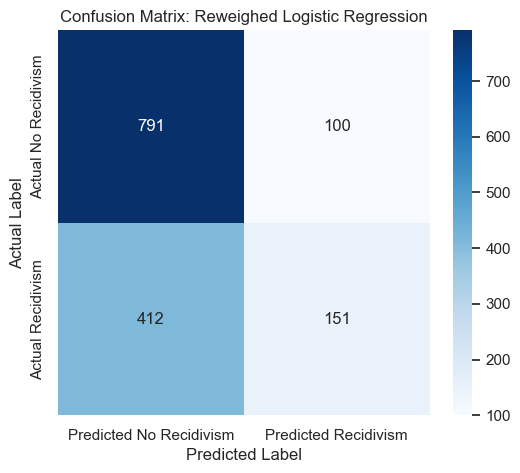

In [308]:
# Plot confusion matrix for Reweighed Logistic Regression

plot_confusion_matrix_reweighed(
    y_true=y_test,
    y_pred=y_pred_rw_log_reg,
    model_name='Reweighed Logistic Regression'
)

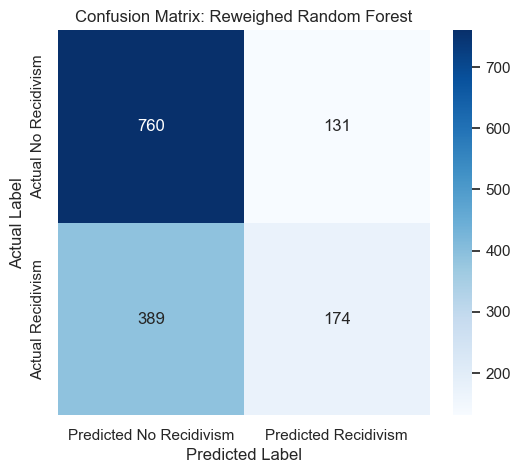

In [309]:
# Plot confusion matrix for Reweighed Random Forest

plot_confusion_matrix_reweighed(
    y_true=y_test,
    y_pred=y_pred_rw_rf,
    model_name='Reweighed Random Forest'
)

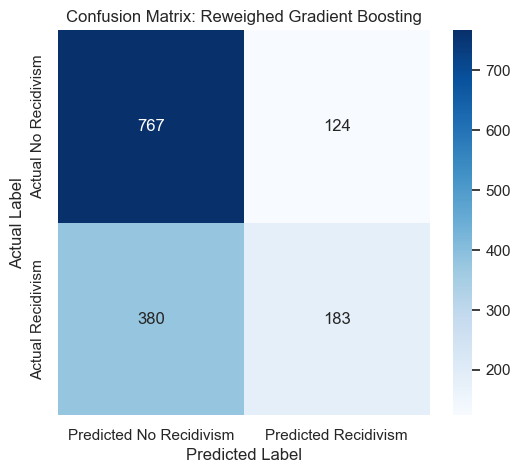

In [310]:
# Plot confusion matrix for Reweighed Gradient Boosting

plot_confusion_matrix_reweighed(
    y_true=y_test,
    y_pred=y_pred_rw_gb,
    model_name='Reweighed Gradient Boosting'
)

# 19.6 Summary of Training Models after Reweighing

In this section, models were trained again after applying AIF360 Reweighing.

The following steps were completed:

1. The encoded dataset was loaded.
2. Features, target, and protected attribute were prepared.
3. The dataset was split into training and testing sets.
4. The training data was converted into an AIF360 BinaryLabelDataset.
5. AIF360 Reweighing was applied to the training data.
6. Sample weights were extracted from the reweighed dataset.
7. Logistic Regression was trained using scaled features and sample weights.
8. Random Forest was trained using unscaled features and sample weights.
9. Gradient Boosting was trained using unscaled features and sample weights.
10. Model predictions and probabilities were generated.
11. Classification performance was evaluated.
12. Reweighed model results and predictions were saved.

The next section compares model performance and fairness before and after bias mitigation.

# 20. Compare Before and After Bias Mitigation

In this section, we compare models before and after applying AIF360 Reweighing.

The goal is to answer two important questions:

1. Did reweighing improve fairness?
2. Did reweighing reduce predictive performance?

This is important because fairness methods often create a trade-off between accuracy and fairness.

We compare the following original and reweighed models:

| Original Model | Reweighed Model |
|---|---|
| Logistic Regression | Reweighed Logistic Regression |
| Random Forest | Reweighed Random Forest |
| Gradient Boosting | Reweighed Gradient Boosting |

In [311]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import sklearn metrics

from sklearn.metrics import confusion_matrix

# Import AIF360

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# Set plot style

sns.set(style="whitegrid")

In [312]:
# Load original model performance results

original_results = pd.read_csv("model_results_all_5_models.csv")

# Load reweighed model performance results

reweighed_results = pd.read_csv("reweighed_model_results.csv")

# Display original results

original_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.655433,0.610714,0.303730,0.405694,0.680213
1,Decision Tree,0.651994,0.595960,0.314387,0.411628,0.669693
2,Random Forest,0.643054,0.566265,0.333925,0.420112,0.668932
3,Gradient Boosting,0.649931,0.577143,0.358792,0.442497,0.675938
4,Support Vector Machine,0.634113,0.555160,0.277087,0.369668,0.642383


In [313]:
# Display reweighed results

reweighed_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Reweighed Logistic Regression,0.647868,0.601594,0.268206,0.371007,0.678553
1,Reweighed Random Forest,0.642366,0.570492,0.309059,0.400922,0.667880
2,Reweighed Gradient Boosting,0.653370,0.596091,0.325044,0.420690,0.676925


The original results contain all five models.

The reweighed results contain only the models trained after reweighing:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

In [314]:
# Select only original models that have reweighed versions

original_selected = original_results[
    original_results['Model'].isin([
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ])
].copy()

# Rename models to match reweighed comparison names

original_selected['Model Type'] = original_selected['Model']
original_selected['Training Method'] = 'Original'

reweighed_selected = reweighed_results.copy()

# Create model type names without "Reweighed"

reweighed_selected['Model Type'] = reweighed_selected['Model'].replace({
    'Reweighed Logistic Regression': 'Logistic Regression',
    'Reweighed Random Forest': 'Random Forest',
    'Reweighed Gradient Boosting': 'Gradient Boosting'
})

reweighed_selected['Training Method'] = 'Reweighed'

# Combine original and reweighed results

before_after_performance = pd.concat(
    [original_selected, reweighed_selected],
    ignore_index=True
)

# Display comparison

before_after_performance.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Model Type,Training Method
0,Logistic Regression,0.6554,0.6107,0.3037,0.4057,0.6802,Logistic Regression,Original
1,Random Forest,0.6431,0.5663,0.3339,0.4201,0.6689,Random Forest,Original
2,Gradient Boosting,0.6499,0.5771,0.3588,0.4425,0.6759,Gradient Boosting,Original
3,Reweighed Logistic Regression,0.6479,0.6016,0.2682,0.3710,0.6786,Logistic Regression,Reweighed
4,Reweighed Random Forest,0.6424,0.5705,0.3091,0.4009,0.6679,Random Forest,Reweighed
5,Reweighed Gradient Boosting,0.6534,0.5961,0.3250,0.4207,0.6769,Gradient Boosting,Reweighed


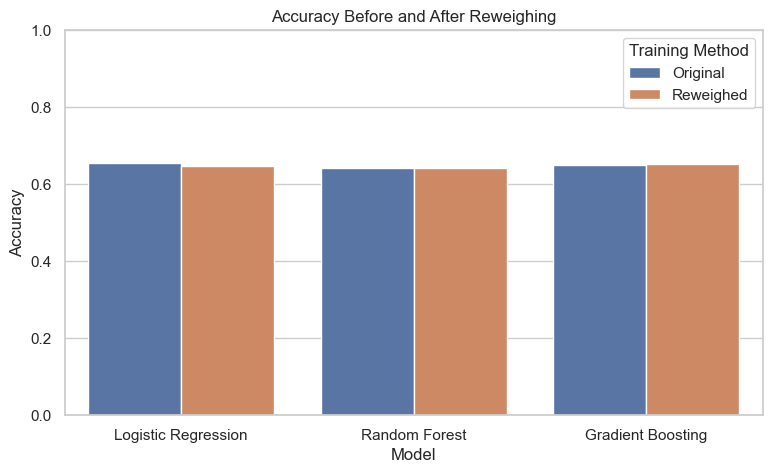

In [315]:
# Plot accuracy comparison

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_performance,
    x='Model Type',
    y='Accuracy',
    hue='Training Method'
)

plt.title("Accuracy Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

This plot shows whether reweighing changed model accuracy.

If accuracy decreases only slightly but fairness improves, then reweighing may still be useful.

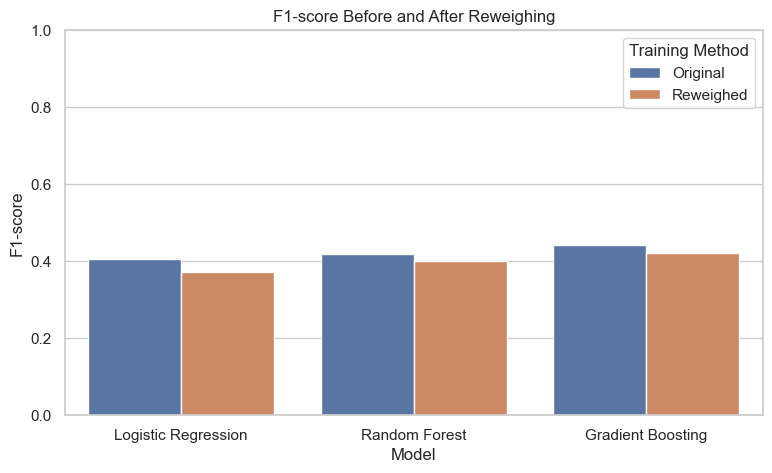

In [316]:
# Plot F1-score comparison

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_performance,
    x='Model Type',
    y='F1-score',
    hue='Training Method'
)

plt.title("F1-score Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.show()

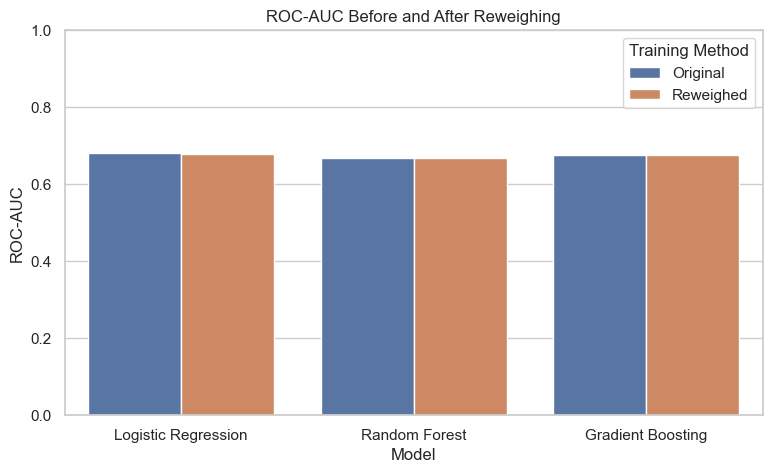

In [317]:
# Plot ROC-AUC comparison

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_performance,
    x='Model Type',
    y='ROC-AUC',
    hue='Training Method'
)

plt.title("ROC-AUC Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.show()

In [318]:
# Load original model predictions

original_predictions = pd.read_csv("model_predictions_all_5_models.csv")

# Load reweighed model predictions

reweighed_predictions = pd.read_csv("reweighed_model_predictions.csv")

# Display first rows

original_predictions.head()

,y_true,race_binary,logistic_regression_pred,decision_tree_pred,random_forest_pred,gradient_boosting_pred,svm_pred,logistic_regression_prob,decision_tree_prob,random_forest_prob,gradient_boosting_prob,svm_prob
0,0,1,0,0,0,0,0,0.108942,0.204918,0.224312,0.155470,0.313100
1,0,0,1,1,1,1,1,0.551651,0.701031,0.616269,0.587832,0.557180
2,0,0,0,0,0,0,0,0.242569,0.209337,0.214292,0.239700,0.314083
3,0,1,0,0,0,0,0,0.461917,0.457627,0.439547,0.484609,0.404352
4,0,1,0,0,0,0,0,0.356952,0.314010,0.308712,0.331699,0.321746


In [319]:
# Display reweighed predictions

reweighed_predictions.head()

,y_true,race_binary,reweighed_logistic_regression_pred,reweighed_random_forest_pred,reweighed_gradient_boosting_pred,reweighed_logistic_regression_prob,reweighed_random_forest_prob,reweighed_gradient_boosting_prob
0,0,1,0,0,0,0.136794,0.247615,0.182521
1,0,0,1,1,1,0.511702,0.576624,0.558365
2,0,0,0,0,0,0.216843,0.185554,0.214061
3,0,1,1,0,1,0.520917,0.443685,0.516555
4,0,1,0,0,0,0.413418,0.337200,0.385182


The prediction files contain:

- Actual labels
- Protected attribute
- Predicted labels
- Predicted probabilities

These are needed to compare fairness before and after reweighing.

## 20.2 Define Fairness Helper Functions

To compare fairness before and after reweighing, we calculate group-based error rates.

The most important metrics are:

1. False Positive Rate Difference
2. False Negative Rate Difference
3. Selection Rate Difference

Difference formula:

African-American rate - Caucasian rate

In [320]:
# Function to calculate group-based fairness rates

def calculate_group_rates(data, prediction_column, model_name):
    """
    Calculate group-based error rates for African-American and Caucasian groups.
    
    Positive class = 1 means predicted recidivism / high risk.
    """
    
    results = []
    
    for group_value, group_name in [(0, 'African-American'), (1, 'Caucasian')]:
        
        group_data = data[data['race_binary'] == group_value]
        
        y_true_group = group_data['y_true']
        y_pred_group = group_data[prediction_column]
        
        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        ).ravel()
        
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) != 0 else 0
        selection_rate = y_pred_group.mean()
        
        results.append({
            'Model': model_name,
            'Group': group_name,
            'False Positive Rate': fpr,
            'False Negative Rate': fnr,
            'True Positive Rate': tpr,
            'True Negative Rate': tnr,
            'Selection Rate': selection_rate
        })
    
    return pd.DataFrame(results)

In [321]:
# Function to calculate fairness differences

def calculate_group_differences(group_rates_df):
    """
    Calculate difference between African-American and Caucasian rates.
    
    Difference = African-American rate - Caucasian rate
    """
    
    aa = group_rates_df[group_rates_df['Group'] == 'African-American'].iloc[0]
    caucasian = group_rates_df[group_rates_df['Group'] == 'Caucasian'].iloc[0]
    
    return {
        'Model': aa['Model'],
        'FPR Difference': aa['False Positive Rate'] - caucasian['False Positive Rate'],
        'FNR Difference': aa['False Negative Rate'] - caucasian['False Negative Rate'],
        'TPR Difference': aa['True Positive Rate'] - caucasian['True Positive Rate'],
        'TNR Difference': aa['True Negative Rate'] - caucasian['True Negative Rate'],
        'Selection Rate Difference': aa['Selection Rate'] - caucasian['Selection Rate']
    }

In [322]:
# Original model prediction columns to compare

original_prediction_columns = {
    'Logistic Regression': 'logistic_regression_pred',
    'Random Forest': 'random_forest_pred',
    'Gradient Boosting': 'gradient_boosting_pred'
}

original_group_rates_list = []
original_difference_list = []

for model_name, pred_col in original_prediction_columns.items():
    
    group_rates = calculate_group_rates(
        data=original_predictions,
        prediction_column=pred_col,
        model_name=model_name
    )
    
    original_group_rates_list.append(group_rates)
    original_difference_list.append(calculate_group_differences(group_rates))

original_group_rates_df = pd.concat(original_group_rates_list, ignore_index=True)
original_fairness_differences = pd.DataFrame(original_difference_list)

original_fairness_differences.round(4)

,Model,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference
0,Logistic Regression,0.1112,-0.2486,0.2486,-0.1112,0.1731
1,Random Forest,0.1457,-0.2794,0.2794,-0.1457,0.2056
2,Gradient Boosting,0.1487,-0.2786,0.2786,-0.1487,0.2084


In [323]:
# Reweighed model prediction columns to compare

reweighed_prediction_columns = {
    'Logistic Regression': 'reweighed_logistic_regression_pred',
    'Random Forest': 'reweighed_random_forest_pred',
    'Gradient Boosting': 'reweighed_gradient_boosting_pred'
}

reweighed_group_rates_list = []
reweighed_difference_list = []

for model_name, pred_col in reweighed_prediction_columns.items():
    
    group_rates = calculate_group_rates(
        data=reweighed_predictions,
        prediction_column=pred_col,
        model_name=model_name
    )
    
    reweighed_group_rates_list.append(group_rates)
    reweighed_difference_list.append(calculate_group_differences(group_rates))

reweighed_group_rates_df = pd.concat(reweighed_group_rates_list, ignore_index=True)
reweighed_fairness_differences = pd.DataFrame(reweighed_difference_list)

reweighed_fairness_differences.round(4)

,Model,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference
0,Logistic Regression,0.0060,-0.0300,0.0300,-0.0060,0.0247
1,Random Forest,0.0422,-0.1162,0.1162,-0.0422,0.0797
2,Gradient Boosting,0.0241,-0.0705,0.0705,-0.0241,0.0530


In [324]:
# Add training method labels

original_fairness_differences['Training Method'] = 'Original'
reweighed_fairness_differences['Training Method'] = 'Reweighed'

# Combine fairness differences

before_after_fairness = pd.concat(
    [original_fairness_differences, reweighed_fairness_differences],
    ignore_index=True
)

before_after_fairness.round(4)

,Model,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference,Training Method
0,Logistic Regression,0.1112,-0.2486,0.2486,-0.1112,0.1731,Original
1,Random Forest,0.1457,-0.2794,0.2794,-0.1457,0.2056,Original
2,Gradient Boosting,0.1487,-0.2786,0.2786,-0.1487,0.2084,Original
3,Logistic Regression,0.0060,-0.0300,0.0300,-0.0060,0.0247,Reweighed
4,Random Forest,0.0422,-0.1162,0.1162,-0.0422,0.0797,Reweighed
5,Gradient Boosting,0.0241,-0.0705,0.0705,-0.0241,0.0530,Reweighed


This table compares fairness differences before and after reweighing.

Values closer to 0 mean more similar error rates between racial groups.

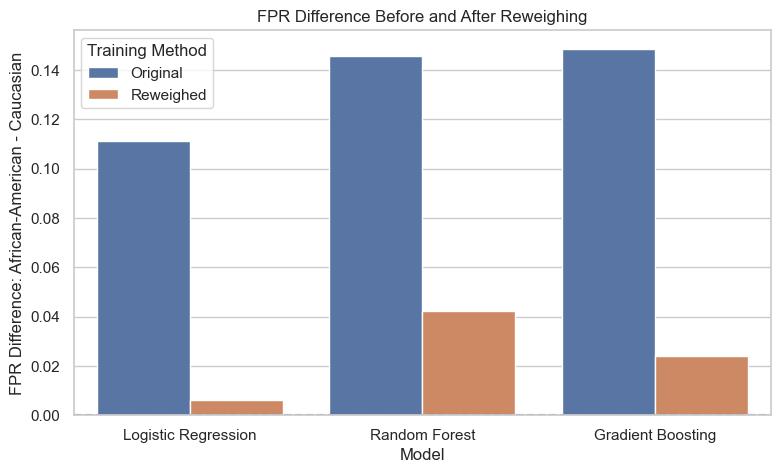

In [325]:
# Plot FPR Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_fairness,
    x='Model',
    y='FPR Difference',
    hue='Training Method'
)

plt.axhline(0, linestyle='--')
plt.title("FPR Difference Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("FPR Difference: African-American - Caucasian")
plt.show()

False Positive Rate Difference is especially important in the COMPAS case.

A positive value means African-American defendants are wrongly classified as high risk more often than Caucasian defendants.

A value closer to 0 after reweighing suggests fairness improvement.

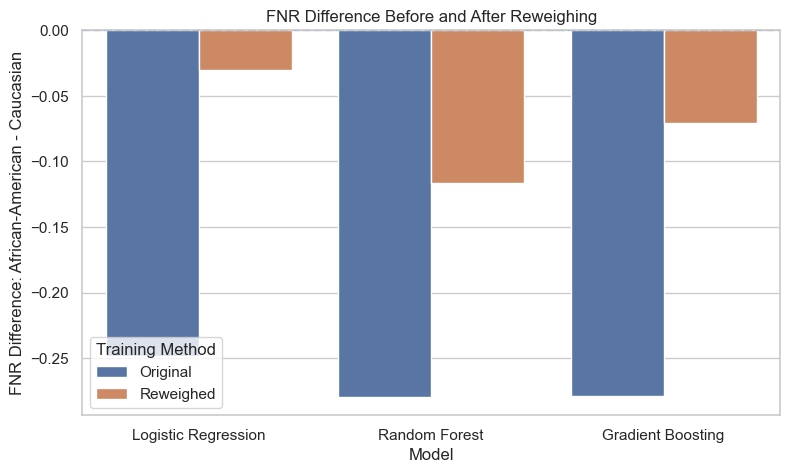

In [326]:
# Plot FNR Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_fairness,
    x='Model',
    y='FNR Difference',
    hue='Training Method'
)

plt.axhline(0, linestyle='--')
plt.title("FNR Difference Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("FNR Difference: African-American - Caucasian")
plt.show()

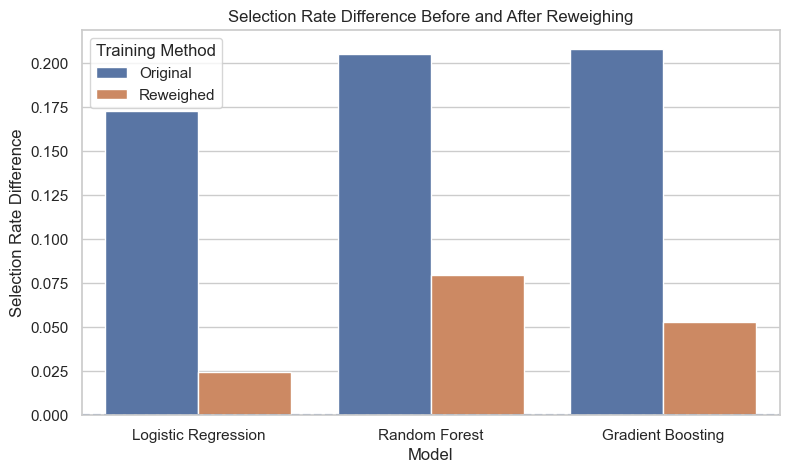

In [327]:
# Plot Selection Rate Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_fairness,
    x='Model',
    y='Selection Rate Difference',
    hue='Training Method'
)

plt.axhline(0, linestyle='--')
plt.title("Selection Rate Difference Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("Selection Rate Difference")
plt.show()

## 20.3 Calculate Absolute Fairness Differences

To measure fairness improvement clearly, we calculate absolute differences.

For example:

- FPR Difference = 0.20 means unfairness magnitude is 0.20
- FPR Difference = -0.20 also means unfairness magnitude is 0.20

So we use absolute values.

In [328]:
# Create copy

before_after_fairness_abs = before_after_fairness.copy()

# Calculate absolute values

before_after_fairness_abs['Abs FPR Difference'] = before_after_fairness_abs['FPR Difference'].abs()
before_after_fairness_abs['Abs FNR Difference'] = before_after_fairness_abs['FNR Difference'].abs()
before_after_fairness_abs['Abs Selection Rate Difference'] = before_after_fairness_abs['Selection Rate Difference'].abs()

before_after_fairness_abs.round(4)

,Model,FPR Difference,FNR Difference,TPR Difference,TNR Difference,Selection Rate Difference,Training Method,Abs FPR Difference,Abs FNR Difference,Abs Selection Rate Difference
0,Logistic Regression,0.1112,-0.2486,0.2486,-0.1112,0.1731,Original,0.1112,0.2486,0.1731
1,Random Forest,0.1457,-0.2794,0.2794,-0.1457,0.2056,Original,0.1457,0.2794,0.2056
2,Gradient Boosting,0.1487,-0.2786,0.2786,-0.1487,0.2084,Original,0.1487,0.2786,0.2084
3,Logistic Regression,0.0060,-0.0300,0.0300,-0.0060,0.0247,Reweighed,0.0060,0.0300,0.0247
4,Random Forest,0.0422,-0.1162,0.1162,-0.0422,0.0797,Reweighed,0.0422,0.1162,0.0797
5,Gradient Boosting,0.0241,-0.0705,0.0705,-0.0241,0.0530,Reweighed,0.0241,0.0705,0.0530


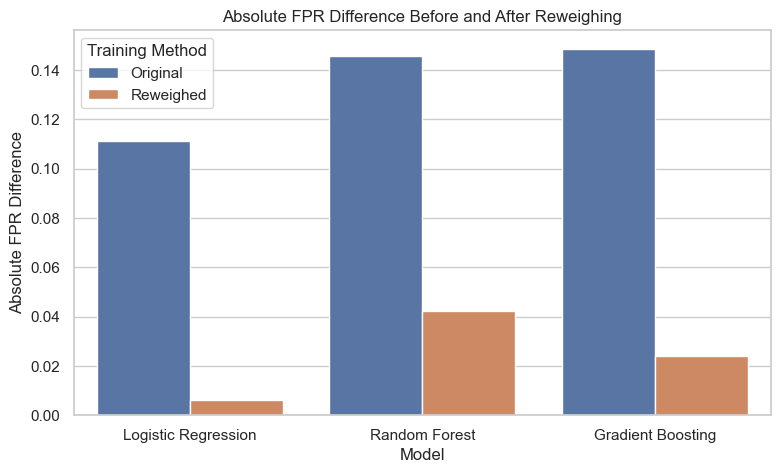

In [329]:
# Plot absolute FPR Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_fairness_abs,
    x='Model',
    y='Abs FPR Difference',
    hue='Training Method'
)

plt.title("Absolute FPR Difference Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("Absolute FPR Difference")
plt.show()

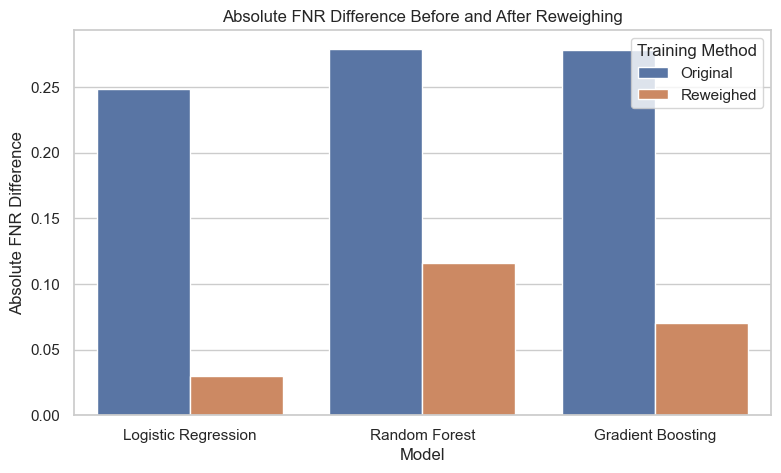

In [330]:
# Plot absolute FNR Difference

plt.figure(figsize=(9, 5))
sns.barplot(
    data=before_after_fairness_abs,
    x='Model',
    y='Abs FNR Difference',
    hue='Training Method'
)

plt.title("Absolute FNR Difference Before and After Reweighing")
plt.xlabel("Model")
plt.ylabel("Absolute FNR Difference")
plt.show()

## 20.3 Create Final Before-After Comparison Table

Now we merge performance and fairness into one table.

This table will help us decide whether reweighing improved the models.

In [331]:
# Merge performance and fairness results

before_after_final_comparison = before_after_performance.merge(
    before_after_fairness_abs,
    left_on=['Model Type', 'Training Method'],
    right_on=['Model', 'Training Method'],
    how='left'
)

# Select important columns

before_after_final_comparison = before_after_final_comparison[
    [
        'Model Type',
        'Training Method',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'FPR Difference',
        'FNR Difference',
        'Selection Rate Difference',
        'Abs FPR Difference',
        'Abs FNR Difference',
        'Abs Selection Rate Difference'
    ]
]

before_after_final_comparison.round(4)

,Model Type,Training Method,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,Selection Rate Difference,Abs FPR Difference,Abs FNR Difference,Abs Selection Rate Difference
0,Logistic Regression,Original,0.6554,0.6107,0.3037,0.4057,0.6802,0.1112,-0.2486,0.1731,0.1112,0.2486,0.1731
1,Random Forest,Original,0.6431,0.5663,0.3339,0.4201,0.6689,0.1457,-0.2794,0.2056,0.1457,0.2794,0.2056
2,Gradient Boosting,Original,0.6499,0.5771,0.3588,0.4425,0.6759,0.1487,-0.2786,0.2084,0.1487,0.2786,0.2084
3,Logistic Regression,Reweighed,0.6479,0.6016,0.2682,0.3710,0.6786,0.0060,-0.0300,0.0247,0.0060,0.0300,0.0247
4,Random Forest,Reweighed,0.6424,0.5705,0.3091,0.4009,0.6679,0.0422,-0.1162,0.0797,0.0422,0.1162,0.0797
5,Gradient Boosting,Reweighed,0.6534,0.5961,0.3250,0.4207,0.6769,0.0241,-0.0705,0.0530,0.0241,0.0705,0.0530


In [332]:
# Save comparison files

before_after_performance.to_csv("before_after_performance_comparison.csv", index=False)
before_after_fairness.to_csv("before_after_fairness_comparison.csv", index=False)
before_after_final_comparison.to_csv("before_after_final_comparison.csv", index=False)

print("Before-after comparison files saved successfully.")

Before-after comparison files saved successfully.


## 20.4 Interpretation Guide

When interpreting the before-after comparison, use the following logic:

### If reweighing improves fairness and accuracy stays similar

This is the best case. It means the model became fairer without losing much predictive performance.

### If reweighing improves fairness but accuracy decreases slightly

This is still acceptable if the fairness improvement is meaningful.

### If reweighing does not improve fairness

Then reweighing may not be effective for that model, and other fairness methods may be needed.

### If reweighing improves one fairness metric but worsens another

This is common in FairML. Different fairness metrics can conflict with each other.

The final model should be selected based on a balance between:

1. Accuracy
2. F1-score
3. ROC-AUC
4. False Positive Rate Difference
5. False Negative Rate Difference
6. Interpretability

# 20.5 Summary of Before and After Bias Mitigation Comparison

In this section, original models were compared with reweighed models.

The comparison focused on both performance and fairness.

The following models were compared:

1. Logistic Regression vs Reweighed Logistic Regression
2. Random Forest vs Reweighed Random Forest
3. Gradient Boosting vs Reweighed Gradient Boosting

The following performance metrics were compared:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The following fairness metrics were compared:

- False Positive Rate Difference
- False Negative Rate Difference
- Selection Rate Difference

The results were also converted into absolute differences because fairness differences close to 0 are preferred.

This section helps us understand whether AIF360 Reweighing improved fairness and whether this improvement came with a performance trade-off.

# 21. Accuracy vs Fairness Trade-off

In machine learning, the best model is often selected based on predictive performance.

Common performance metrics include:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

However, in fairness-aware machine learning, the model with the highest accuracy is not always the best model.

A model may have high accuracy overall but still be unfair if it produces very different error rates for different racial groups.

In this project, the protected attribute is:

`race_binary`

where:

- `race_binary = 0`: African-American defendants
- `race_binary = 1`: Caucasian defendants

The goal of this section is to analyze the trade-off between accuracy and fairness.

## 21.1 Why Accuracy Alone Is Not Enough

Accuracy measures the total percentage of correct predictions.

However, accuracy does not tell us whether errors are distributed equally across groups.

For example, two models may have the same accuracy:

| Model | Accuracy | FPR Difference |
|---|---:|---:|
| Model A | 0.68 | 0.02 |
| Model B | 0.68 | 0.20 |

Both models have the same accuracy, but Model B is less fair because its False Positive Rate Difference is much larger.

In the COMPAS context, False Positive Rate is very important because a false positive means:

- The person did not actually reoffend.
- The model wrongly predicted the person as high risk.

This type of error can be harmful in criminal justice settings.

In [333]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style

sns.set(style="whitegrid")

In [334]:
# Load before-after final comparison table created in Section 21

before_after_final_comparison = pd.read_csv("before_after_final_comparison.csv")

# Display table

before_after_final_comparison.round(4)

,Model Type,Training Method,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,Selection Rate Difference,Abs FPR Difference,Abs FNR Difference,Abs Selection Rate Difference
0,Logistic Regression,Original,0.6554,0.6107,0.3037,0.4057,0.6802,0.1112,-0.2486,0.1731,0.1112,0.2486,0.1731
1,Random Forest,Original,0.6431,0.5663,0.3339,0.4201,0.6689,0.1457,-0.2794,0.2056,0.1457,0.2794,0.2056
2,Gradient Boosting,Original,0.6499,0.5771,0.3588,0.4425,0.6759,0.1487,-0.2786,0.2084,0.1487,0.2786,0.2084
3,Logistic Regression,Reweighed,0.6479,0.6016,0.2682,0.3710,0.6786,0.0060,-0.0300,0.0247,0.0060,0.0300,0.0247
4,Random Forest,Reweighed,0.6424,0.5705,0.3091,0.4009,0.6679,0.0422,-0.1162,0.0797,0.0422,0.1162,0.0797
5,Gradient Boosting,Reweighed,0.6534,0.5961,0.3250,0.4207,0.6769,0.0241,-0.0705,0.0530,0.0241,0.0705,0.0530


The table contains both performance and fairness metrics before and after reweighing.

This table is the main input for analyzing the accuracy-fairness trade-off.

## 21.2 Add Fairness Score Columns

Fairness metrics such as FPR Difference and FNR Difference are better when they are close to 0.

To compare models more easily, we use absolute values:

- Absolute FPR Difference
- Absolute FNR Difference
- Absolute Selection Rate Difference

Lower absolute values mean better fairness.

We also create a combined fairness gap score:

Fairness Gap Score = average of absolute fairness differences

Lower Fairness Gap Score means better fairness overall.

In [335]:
# Create copy for trade-off analysis

tradeoff_df = before_after_final_comparison.copy()

# Make sure absolute fairness columns exist

tradeoff_df['Abs FPR Difference'] = tradeoff_df['FPR Difference'].abs()
tradeoff_df['Abs FNR Difference'] = tradeoff_df['FNR Difference'].abs()
tradeoff_df['Abs Selection Rate Difference'] = tradeoff_df['Selection Rate Difference'].abs()

# Create combined fairness gap score

tradeoff_df['Fairness Gap Score'] = tradeoff_df[
    [
        'Abs FPR Difference',
        'Abs FNR Difference',
        'Abs Selection Rate Difference'
    ]
].mean(axis=1)

# Display important columns

tradeoff_df[
    [
        'Model Type',
        'Training Method',
        'Accuracy',
        'F1-score',
        'ROC-AUC',
        'Abs FPR Difference',
        'Abs FNR Difference',
        'Abs Selection Rate Difference',
        'Fairness Gap Score'
    ]
].round(4)

,Model Type,Training Method,Accuracy,F1-score,ROC-AUC,Abs FPR Difference,Abs FNR Difference,Abs Selection Rate Difference,Fairness Gap Score
0,Logistic Regression,Original,0.6554,0.4057,0.6802,0.1112,0.2486,0.1731,0.1776
1,Random Forest,Original,0.6431,0.4201,0.6689,0.1457,0.2794,0.2056,0.2102
2,Gradient Boosting,Original,0.6499,0.4425,0.6759,0.1487,0.2786,0.2084,0.2119
3,Logistic Regression,Reweighed,0.6479,0.3710,0.6786,0.0060,0.0300,0.0247,0.0202
4,Random Forest,Reweighed,0.6424,0.4009,0.6679,0.0422,0.1162,0.0797,0.0793
5,Gradient Boosting,Reweighed,0.6534,0.4207,0.6769,0.0241,0.0705,0.0530,0.0492


The Fairness Gap Score is not a standard universal fairness metric.

It is a simple project-level summary score created to compare models more easily.

It combines the main fairness gaps used in this project.

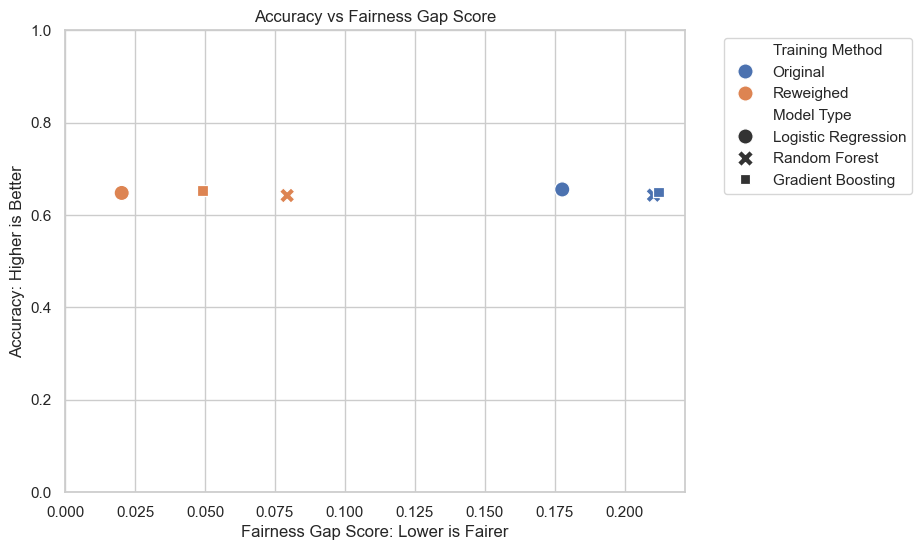

In [336]:
# Plot Accuracy vs Fairness Gap Score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tradeoff_df,
    x='Fairness Gap Score',
    y='Accuracy',
    hue='Training Method',
    style='Model Type',
    s=120
)

plt.title("Accuracy vs Fairness Gap Score")
plt.xlabel("Fairness Gap Score: Lower is Fairer")
plt.ylabel("Accuracy: Higher is Better")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This plot shows the trade-off between accuracy and fairness.

Ideal models are located:

- Higher on the y-axis because they have higher accuracy
- Further left on the x-axis because they have lower fairness gap

Therefore, the best region is the upper-left part of the plot.

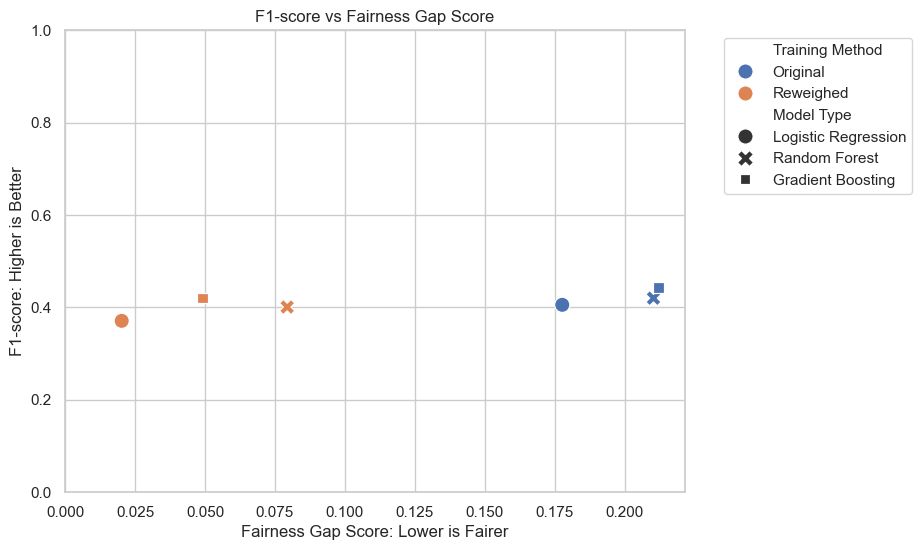

In [337]:
# Plot F1-score vs Fairness Gap Score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tradeoff_df,
    x='Fairness Gap Score',
    y='F1-score',
    hue='Training Method',
    style='Model Type',
    s=120
)

plt.title("F1-score vs Fairness Gap Score")
plt.xlabel("Fairness Gap Score: Lower is Fairer")
plt.ylabel("F1-score: Higher is Better")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

F1-score is useful because it balances precision and recall.

This plot helps us check whether a model has both good classification balance and lower fairness gap.

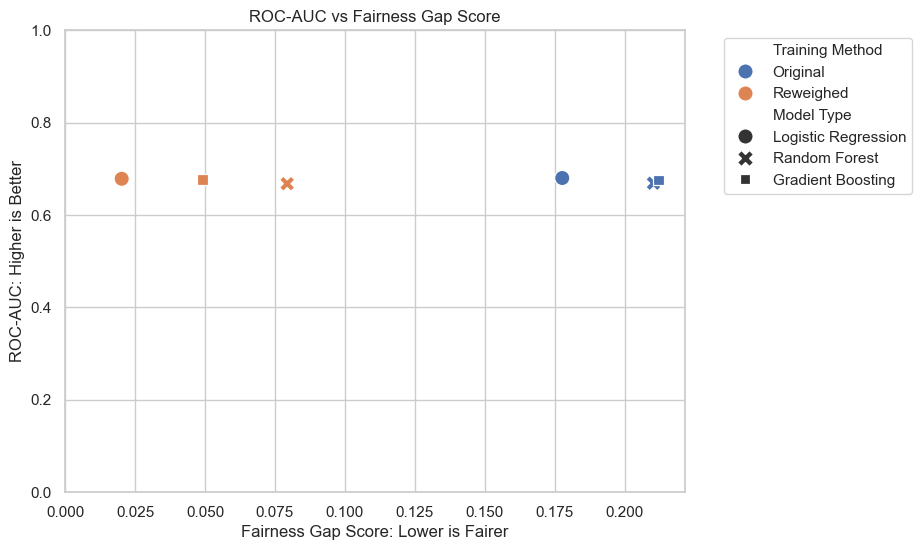

In [338]:
# Plot ROC-AUC vs Fairness Gap Score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tradeoff_df,
    x='Fairness Gap Score',
    y='ROC-AUC',
    hue='Training Method',
    style='Model Type',
    s=120
)

plt.title("ROC-AUC vs Fairness Gap Score")
plt.xlabel("Fairness Gap Score: Lower is Fairer")
plt.ylabel("ROC-AUC: Higher is Better")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ROC-AUC shows how well the model separates the two classes across thresholds.

A useful model should have both:

- High ROC-AUC
- Low fairness gap

## 21.3 Compare Accuracy and Fairness in One Table

Now we create a simplified table showing the most important performance and fairness values.

This table is useful for final model selection.

In [339]:
# Create simplified comparison table

tradeoff_summary = tradeoff_df[
    [
        'Model Type',
        'Training Method',
        'Accuracy',
        'F1-score',
        'ROC-AUC',
        'FPR Difference',
        'FNR Difference',
        'Selection Rate Difference',
        'Fairness Gap Score'
    ]
].copy()

# Sort by Fairness Gap Score, then by Accuracy

tradeoff_summary = tradeoff_summary.sort_values(
    by=['Fairness Gap Score', 'Accuracy'],
    ascending=[True, False]
)

tradeoff_summary.round(4)

,Model Type,Training Method,Accuracy,F1-score,ROC-AUC,FPR Difference,FNR Difference,Selection Rate Difference,Fairness Gap Score
3,Logistic Regression,Reweighed,0.6479,0.3710,0.6786,0.0060,-0.0300,0.0247,0.0202
5,Gradient Boosting,Reweighed,0.6534,0.4207,0.6769,0.0241,-0.0705,0.0530,0.0492
4,Random Forest,Reweighed,0.6424,0.4009,0.6679,0.0422,-0.1162,0.0797,0.0793
0,Logistic Regression,Original,0.6554,0.4057,0.6802,0.1112,-0.2486,0.1731,0.1776
1,Random Forest,Original,0.6431,0.4201,0.6689,0.1457,-0.2794,0.2056,0.2102
2,Gradient Boosting,Original,0.6499,0.4425,0.6759,0.1487,-0.2786,0.2084,0.2119


## 21.4 Rank Models by Performance and Fairness

To select a final model, we create a simple combined ranking.

The model should have:

1. High accuracy
2. High F1-score
3. High ROC-AUC
4. Low Fairness Gap Score

Ranking rules:

- Higher Accuracy is better.
- Higher F1-score is better.
- Higher ROC-AUC is better.
- Lower Fairness Gap Score is better.

Then we calculate the average rank.

In [340]:
# Create ranking dataframe

selection_df = tradeoff_df.copy()

# Rank performance metrics
# Higher values are better, so ascending=False

selection_df['Accuracy Rank'] = selection_df['Accuracy'].rank(ascending=False)
selection_df['F1 Rank'] = selection_df['F1-score'].rank(ascending=False)
selection_df['ROC-AUC Rank'] = selection_df['ROC-AUC'].rank(ascending=False)

# Rank fairness metric
# Lower fairness gap is better, so ascending=True

selection_df['Fairness Rank'] = selection_df['Fairness Gap Score'].rank(ascending=True)

# Calculate average rank

selection_df['Average Final Rank'] = selection_df[
    [
        'Accuracy Rank',
        'F1 Rank',
        'ROC-AUC Rank',
        'Fairness Rank'
    ]
].mean(axis=1)

# Sort by final rank

selection_df_sorted = selection_df.sort_values(by='Average Final Rank')

selection_df_sorted[
    [
        'Model Type',
        'Training Method',
        'Accuracy',
        'F1-score',
        'ROC-AUC',
        'Fairness Gap Score',
        'Accuracy Rank',
        'F1 Rank',
        'ROC-AUC Rank',
        'Fairness Rank',
        'Average Final Rank'
    ]
].round(4)

,Model Type,Training Method,Accuracy,F1-score,ROC-AUC,Fairness Gap Score,Accuracy Rank,F1 Rank,ROC-AUC Rank,Fairness Rank,Average Final Rank
5,Gradient Boosting,Reweighed,0.6534,0.4207,0.6769,0.0492,2.0,2.0,3.0,2.0,2.25
0,Logistic Regression,Original,0.6554,0.4057,0.6802,0.1776,1.0,4.0,1.0,4.0,2.50
3,Logistic Regression,Reweighed,0.6479,0.3710,0.6786,0.0202,4.0,6.0,2.0,1.0,3.25
2,Gradient Boosting,Original,0.6499,0.4425,0.6759,0.2119,3.0,1.0,4.0,6.0,3.50
1,Random Forest,Original,0.6431,0.4201,0.6689,0.2102,5.0,3.0,5.0,5.0,4.50
4,Random Forest,Reweighed,0.6424,0.4009,0.6679,0.0793,6.0,5.0,6.0,3.0,5.00


This ranking gives a balanced view of performance and fairness.

The model with the lowest Average Final Rank is the best according to this project-level ranking.

However, the final choice should also consider interpretability.

In [341]:
# Select model with best average final rank

best_tradeoff_model = selection_df_sorted.iloc[0]

print("Best trade-off model based on combined ranking:")
print("Model Type:", best_tradeoff_model['Model Type'])
print("Training Method:", best_tradeoff_model['Training Method'])
print("Accuracy:", round(best_tradeoff_model['Accuracy'], 4))
print("F1-score:", round(best_tradeoff_model['F1-score'], 4))
print("ROC-AUC:", round(best_tradeoff_model['ROC-AUC'], 4))
print("Fairness Gap Score:", round(best_tradeoff_model['Fairness Gap Score'], 4))

Best trade-off model based on combined ranking:
Model Type: Gradient Boosting
Training Method: Reweighed
Accuracy: 0.6534
F1-score: 0.4207
ROC-AUC: 0.6769
Fairness Gap Score: 0.0492


In [342]:
# Save trade-off analysis results

tradeoff_df.to_csv("accuracy_fairness_tradeoff_analysis.csv", index=False)
tradeoff_summary.to_csv("accuracy_fairness_tradeoff_summary.csv", index=False)
selection_df_sorted.to_csv("model_selection_ranking.csv", index=False)

print("Accuracy-fairness trade-off results saved successfully.")

Accuracy-fairness trade-off results saved successfully.


# 21.5 Accuracy vs Fairness Trade-off Summary

In this section, the relationship between accuracy and fairness was analyzed.

The following steps were completed:

1. The before-after comparison table was loaded.
2. Absolute fairness differences were calculated.
3. A combined Fairness Gap Score was created.
4. Accuracy, F1-score, and ROC-AUC were compared with fairness gap.
5. Scatter plots were created to visualize trade-offs.
6. Models were ranked using both performance and fairness.
7. The best trade-off model was identified.

The key conclusion is that the model with the highest accuracy is not necessarily the best fair model.

A final fair model should balance:

- Predictive performance
- Fairness across racial groups
- Interpretability

# 22. Final Fair Model Selection

In this section, we select the final model for the project.

The final model should satisfy three conditions:

1. It should have acceptable predictive performance.
2. It should reduce fairness gaps between African-American and Caucasian defendants.
3. It should be explainable enough for a semester project.

The model is selected based on:

- Accuracy
- F1-score
- ROC-AUC
- False Positive Rate Difference
- False Negative Rate Difference
- Selection Rate Difference
- Fairness Gap Score
- Interpretability

In [343]:
# Load model selection ranking

selection_df_sorted = pd.read_csv("model_selection_ranking.csv")

# Display ranking

selection_df_sorted[
    [
        'Model Type',
        'Training Method',
        'Accuracy',
        'F1-score',
        'ROC-AUC',
        'FPR Difference',
        'FNR Difference',
        'Selection Rate Difference',
        'Fairness Gap Score',
        'Average Final Rank'
    ]
].round(4)

,Model Type,Training Method,Accuracy,F1-score,ROC-AUC,FPR Difference,FNR Difference,Selection Rate Difference,Fairness Gap Score,Average Final Rank
0,Gradient Boosting,Reweighed,0.6534,0.4207,0.6769,0.0241,-0.0705,0.0530,0.0492,2.25
1,Logistic Regression,Original,0.6554,0.4057,0.6802,0.1112,-0.2486,0.1731,0.1776,2.50
2,Logistic Regression,Reweighed,0.6479,0.3710,0.6786,0.0060,-0.0300,0.0247,0.0202,3.25
3,Gradient Boosting,Original,0.6499,0.4425,0.6759,0.1487,-0.2786,0.2084,0.2119,3.50
4,Random Forest,Original,0.6431,0.4201,0.6689,0.1457,-0.2794,0.2056,0.2102,4.50
5,Random Forest,Reweighed,0.6424,0.4009,0.6679,0.0422,-0.1162,0.0797,0.0793,5.00


This table ranks models based on both performance and fairness.

The top model has the lowest average final rank.

In [344]:
# Select top-ranked model

final_model_row = selection_df_sorted.iloc[0]

final_model_name = final_model_row['Model Type']
final_training_method = final_model_row['Training Method']

print("Selected Final Model")
print("--------------------")
print("Model:", final_model_name)
print("Training Method:", final_training_method)
print("Accuracy:", round(final_model_row['Accuracy'], 4))
print("Precision:", round(final_model_row['Precision'], 4))
print("Recall:", round(final_model_row['Recall'], 4))
print("F1-score:", round(final_model_row['F1-score'], 4))
print("ROC-AUC:", round(final_model_row['ROC-AUC'], 4))
print("FPR Difference:", round(final_model_row['FPR Difference'], 4))
print("FNR Difference:", round(final_model_row['FNR Difference'], 4))
print("Selection Rate Difference:", round(final_model_row['Selection Rate Difference'], 4))
print("Fairness Gap Score:", round(final_model_row['Fairness Gap Score'], 4))

Selected Final Model
--------------------
Model: Gradient Boosting
Training Method: Reweighed
Accuracy: 0.6534
Precision: 0.5961
Recall: 0.325
F1-score: 0.4207
ROC-AUC: 0.6769
FPR Difference: 0.0241
FNR Difference: -0.0705
Selection Rate Difference: 0.053
Fairness Gap Score: 0.0492


The selected model is the model that provides the best balance between performance and fairness according to the ranking system.

However, in a real fairness-sensitive application, final model selection should also involve legal, ethical, and domain expert review.

## 22.1 Final Model Selection Logic

The final model was selected using the following logic:

1. First, all models were evaluated using traditional classification metrics.
2. Then, models were evaluated using fairness metrics.
3. False Positive Rate Difference was treated as especially important because false positives can be harmful in the COMPAS context.
4. A Fairness Gap Score was created by averaging absolute fairness differences.
5. Models were ranked using Accuracy, F1-score, ROC-AUC, and Fairness Gap Score.
6. The model with the best combined rank was selected as the final model.

This approach avoids selecting a model based only on accuracy.

In [345]:
# Create final model summary table

final_model_summary = pd.DataFrame({
    'Criterion': [
        'Selected Model',
        'Training Method',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'FPR Difference',
        'FNR Difference',
        'Selection Rate Difference',
        'Fairness Gap Score'
    ],
    'Value': [
        final_model_name,
        final_training_method,
        final_model_row['Accuracy'],
        final_model_row['Precision'],
        final_model_row['Recall'],
        final_model_row['F1-score'],
        final_model_row['ROC-AUC'],
        final_model_row['FPR Difference'],
        final_model_row['FNR Difference'],
        final_model_row['Selection Rate Difference'],
        final_model_row['Fairness Gap Score']
    ]
})

final_model_summary

,Criterion,Value
0,Selected Model,Gradient Boosting
1,Training Method,Reweighed
2,Accuracy,0.65337
3,Precision,0.596091
4,Recall,0.325044
5,F1-score,0.42069
6,ROC-AUC,0.676925
7,FPR Difference,0.02414
8,FNR Difference,-0.070539
9,Selection Rate Difference,0.05296


In [346]:
# Save final model summary

final_model_summary.to_csv("final_fair_model_summary.csv", index=False)

print("Final fair model summary saved successfully.")

Final fair model summary saved successfully.


## 22.2 Compare Final Model with Original COMPAS Baseline

A useful final step is to compare the selected fair model with the original COMPAS baseline.

This helps answer:

1. Is our model more accurate than COMPAS baseline?
2. Is our model fairer than COMPAS baseline?
3. Does our model reduce fairness gaps?

In [347]:
# Load COMPAS baseline summary

compas_baseline_summary = pd.read_csv("compas_baseline_summary.csv")

compas_baseline_summary.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,TPR Difference,Selection Rate Difference
0,COMPAS Baseline,0.5921,0.4805,0.6536,0.5539,0.6034,0.2199,-0.1946,0.1946,0.2268


In [348]:
# Create comparable final model row

final_model_for_comparison = pd.DataFrame({
    'Model': [final_model_name + " (" + final_training_method + ")"],
    'Accuracy': [final_model_row['Accuracy']],
    'Precision': [final_model_row['Precision']],
    'Recall': [final_model_row['Recall']],
    'F1-score': [final_model_row['F1-score']],
    'ROC-AUC': [final_model_row['ROC-AUC']],
    'FPR Difference': [final_model_row['FPR Difference']],
    'FNR Difference': [final_model_row['FNR Difference']],
    'Selection Rate Difference': [final_model_row['Selection Rate Difference']]
})

# Some older baseline tables may have TPR Difference instead of Selection Rate Difference
# So we align only common columns.

common_columns = [
    col for col in final_model_for_comparison.columns
    if col in compas_baseline_summary.columns
]

compas_vs_final_model = pd.concat(
    [
        compas_baseline_summary[common_columns],
        final_model_for_comparison[common_columns]
    ],
    ignore_index=True
)

compas_vs_final_model.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FPR Difference,FNR Difference,Selection Rate Difference
0,COMPAS Baseline,0.5921,0.4805,0.6536,0.5539,0.6034,0.2199,-0.1946,0.2268
1,Gradient Boosting (Reweighed),0.6534,0.5961,0.3250,0.4207,0.6769,0.0241,-0.0705,0.0530


This table compares the original COMPAS baseline with the selected final model.

The final model should ideally have:

- Similar or better accuracy
- Lower absolute FPR Difference
- Lower absolute FNR Difference
- Better fairness balance overall

In [349]:
# Save COMPAS vs final model comparison

compas_vs_final_model.to_csv("compas_vs_final_model_comparison.csv", index=False)

print("COMPAS vs final model comparison saved successfully.")

COMPAS vs final model comparison saved successfully.


## 22.3 Final Model Interpretation

The final selected model represents the best balance between predictive performance and fairness among the models tested in this project.

The model was not selected only because of accuracy.

Instead, the selection considered:

1. How well the model predicts recidivism.
2. Whether the model reduces unfair differences between racial groups.
3. Whether the model reduces false positive rate differences.
4. Whether the model keeps acceptable F1-score and ROC-AUC.
5. Whether the model is understandable for project explanation.

This is important because in fairness-sensitive applications, a technically accurate model can still be problematic if it creates unequal harms across groups.

## 22.4 Important Ethical Note

This project is an academic fairness analysis.

The final model should not be used for real criminal justice decisions.

There are several reasons:

1. The dataset may contain historical and structural bias.
2. Some important social and legal context is not captured in the dataset.
3. Fairness metrics can conflict with each other.
4. Model predictions can have serious consequences for individuals.
5. A fair machine learning model still requires human, legal, and ethical oversight.

Therefore, the purpose of this project is to study fairness-aware machine learning, not to deploy a decision system.

# 22.5 Final Fair Model Selection Summary

In this section, the final fair model was selected.

The following steps were completed:

1. The model selection ranking was loaded.
2. The top-ranked model was selected automatically.
3. Final model performance and fairness metrics were displayed.
4. A final model summary table was created.
5. The final model was compared with the original COMPAS baseline.
6. The comparison was saved for later use.
7. Ethical limitations were discussed.

The final selected model provides the best balance between accuracy and fairness among the tested models.

This completes the main machine learning and fairness analysis part of the project.

# 23. Conclusion

This project developed and evaluated fair machine learning models using the COMPAS dataset.

The main goal was not only to build a model with good classification performance, but also to evaluate and reduce unfairness across racial groups.

The protected attribute used in this project was:

`race`

The main comparison was between:

- African-American defendants
- Caucasian defendants

The target variable was:

`is_recid`

where:

- `0` means the defendant did not reoffend
- `1` means the defendant reoffended

## 23.1 Summary of Work Completed

The project followed a complete machine learning and fairness-aware machine learning workflow.

The major steps were:

1. The COMPAS dataset was loaded and inspected.
2. Invalid target values were removed.
3. The dataset was filtered to focus on African-American and Caucasian defendants.
4. Relevant features were selected.
5. Categorical variables were encoded.
6. Exploratory Data Analysis was performed.
7. The original COMPAS score was evaluated as a baseline classifier.
8. Fairness metrics were explained.
9. AIF360 was used for dataset-level fairness analysis.
10. Five machine learning models were trained.
11. The models were compared using performance metrics.
12. AIF360 and manual calculations were used for model fairness evaluation.
13. Hyperparameter tuning was performed.
14. AIF360 Reweighing was applied as a bias mitigation method.
15. Original and reweighed models were compared.
16. The accuracy-fairness trade-off was analyzed.
17. A final fair model was selected.

## 23.2 Models Used

The following five machine learning models were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. Support Vector Machine

These models were selected because they represent different types of classification approaches.

| Model | Reason for Use |
|---|---|
| Logistic Regression | Simple and interpretable baseline model |
| Decision Tree | Easy to understand and visualize |
| Random Forest | Strong ensemble model that reduces overfitting |
| Gradient Boosting | Powerful ensemble model for tabular data |
| Support Vector Machine | Non-linear classification model using scaled features |

## 23.3 Performance Metrics Used

The models were evaluated using standard classification metrics:

| Metric | Meaning |
|---|---|
| Accuracy | Overall percentage of correct predictions |
| Precision | Among predicted reoffenders, how many actually reoffended |
| Recall | Among actual reoffenders, how many were correctly identified |
| F1-score | Balance between precision and recall |
| ROC-AUC | Ability of the model to separate the two classes |

These metrics are useful for evaluating predictive performance.

However, they do not directly measure fairness.

## 23.4 Fairness Metrics Used

Because this project is about FairML, fairness metrics were also calculated.

The main fairness metrics used were:

| Metric | Ideal Value | Meaning |
|---|---:|---|
| Statistical Parity Difference | 0 | Similar favorable prediction rates across groups |
| Disparate Impact | 1 | Similar ratio of favorable prediction rates across groups |
| False Positive Rate Difference | 0 | Similar false positive rates across groups |
| False Negative Rate Difference | 0 | Similar false negative rates across groups |
| Equal Opportunity Difference | 0 | Similar true positive rates across groups |
| Average Odds Difference | 0 | Similar overall error behavior across groups |

False Positive Rate Difference was especially important in this project because a false positive means a person was predicted as high risk even though they did not reoffend.

## 23.5 Role of AIF360

AIF360 was used in two major parts of the project:

1. Fairness measurement
2. Bias mitigation

First, the cleaned dataset was converted into an AIF360 `BinaryLabelDataset`.

Then AIF360 was used to calculate dataset-level fairness metrics such as:

- Statistical Parity Difference
- Disparate Impact
- Mean Difference

Later, AIF360 was also used for model fairness evaluation using `ClassificationMetric`.

Finally, AIF360 Reweighing was applied as a pre-processing bias mitigation method.

Reweighing assigns different sample weights to training examples based on protected group and label combinations. These weights were then used during model training.

## 23.6 Main Findings

The main findings of this project are:

1. The COMPAS dataset contains group-level differences between African-American and Caucasian defendants.
2. The original COMPAS score can be evaluated as a baseline classifier.
3. Standard machine learning models can achieve reasonable predictive performance on the dataset.
4. The most accurate model is not necessarily the fairest model.
5. False Positive Rate Difference is an important fairness metric in the COMPAS context.
6. AIF360 Reweighing can change the fairness behavior of models.
7. Bias mitigation may improve fairness but can also affect accuracy, F1-score, or ROC-AUC.
8. Final model selection should consider both performance and fairness.

## 23.7 Accuracy-Fairness Trade-off

One of the most important conclusions from this project is that accuracy and fairness must be considered together.

A model with high accuracy may still have unequal error rates across racial groups.

For example:

- If African-American defendants have a higher false positive rate than Caucasian defendants, the model may create unequal harm.
- If Caucasian defendants have a higher false negative rate, the model may fail to identify risk equally across groups.

Therefore, model selection should not be based only on accuracy.

In this project, a Fairness Gap Score was created to summarize important fairness differences. The final model was selected based on a balance of:

- Accuracy
- F1-score
- ROC-AUC
- False Positive Rate Difference
- False Negative Rate Difference
- Selection Rate Difference

## 23.8 Limitations

This project has several limitations.

1. The analysis focuses mainly on African-American and Caucasian defendants because these are the two largest racial groups in the dataset.
2. Other racial groups were removed to make the fairness comparison clearer, but this means the final analysis is not representative of all groups.
3. The project mainly used race as the protected attribute. Gender fairness was not deeply analyzed.
4. The dataset itself may contain historical, social, and legal biases.
5. Removing race from the model does not automatically remove racial bias because other variables may be correlated with race.
6. The fairness mitigation method used was mainly Reweighing. Other methods, such as Disparate Impact Remover, Equalized Odds Postprocessing, or Adversarial Debiasing, were not fully explored.
7. The final model is only for academic analysis and should not be used for real criminal justice decisions.

## 23.9 Final Conclusion

This project showed how machine learning models can be developed and evaluated using both performance and fairness criteria.

The COMPAS dataset was used to predict recidivism, and multiple classification models were trained and compared.

The project demonstrated that fairness-aware evaluation is necessary because traditional performance metrics such as accuracy, precision, recall, and F1-score do not show whether a model treats different groups equally.

AIF360 was useful for measuring fairness and applying Reweighing as a bias mitigation method.

The final model was selected based on a balance between predictive performance and fairness. This approach is more suitable for fairness-sensitive applications than selecting a model only by accuracy.

Overall, the project shows that responsible machine learning requires both technical performance evaluation and ethical fairness analysis.

In [350]:
import os

In [351]:
print(os.getcwd())

C:\Users\HP\ML project\ml2
